## 1. Project Description

## 2. Data Description and Acquisition

We use three data sources:

**Source 1: Bureau of Transportation Statistics (BTS)** — Our primary dataset. Monthly CSV files downloaded from the [BTS On-Time Performance database](https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FGJ&QO_fu146_anzr=b0-gvzr). Each row is a single flight. Key attributes include carrier, origin/destination airports, scheduled and actual departure/arrival times, delay duration, delay cause, and distance. We pulled all 48 months of 2021-2024. No account required.

**Source 2: NOAA Climate Data Online** — Daily weather summaries pulled via the [NOAA CDO API](https://www.ncdc.noaa.gov/cdo-web/webservices/v2) for the 75 busiest airports. Attributes include max/min temperature, precipitation, snowfall, average wind speed, and max wind gust. Access requires a free API token.

**Source 3: FAA Airport Facilities Data** — Airport metadata from the [FAA ADIP portal](https://adip.faa.gov/agis/public/#/airportSearch/advanced) and [NASR subscription data](https://www.faa.gov/air_traffic/flight_info/aeronav/aero_data/NASR_Subscription/) including latitude/longitude, elevation, and hub classification. Publicly available, no account required.

### 2.1 Imports and Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import requests
import time
import numpy as np
import gc
from scipy import stats
import folium
from folium.plugins import HeatMap
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

### 2.2 Loading BTS Flight Data

The BTS data was downloaded as monthly CSV files for 2021-2024. We load and concatenate all files into a single dataframe, then convert date fields and derive new time-based features.

In [7]:
files = glob.glob("../../bts/**/*.csv", recursive=True)
## Alison: files = glob.glob("../../data/bts/*.csv")
## Matthew: 
print(f"Found {len(files)} CSV files")

df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)

df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], format='mixed')
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.day_name()
df['MONTH'] = df['FL_DATE'].dt.month
df['YEAR'] = df['FL_DATE'].dt.year

print(f"\nTotal flights: {len(df):,}")
print(f"Date range: {df['FL_DATE'].min()} to {df['FL_DATE'].max()}")
print(f"\nFlights per year:")
print(df['YEAR'].value_counts().sort_index())
print(f"\nColumns: {df.columns.tolist()}")

Found 48 CSV files

Total flights: 26,651,502
Date range: 2021-01-01 00:00:00 to 2024-12-31 00:00:00

Flights per year:
YEAR
2021    5995397
2022    6729125
2023    6847899
2024    7079081
Name: count, dtype: int64

Columns: ['FL_DATE', 'OP_UNIQUE_CARRIER', 'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN_CITY_MARKET_ID', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_NM', 'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID', 'DEST_CITY_MARKET_ID', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15', 'CRS_ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW', 'ARR_DEL15', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'DAY_OF_WEEK', 'MONTH', 'YEAR']


The BTS delay-cause columns (CARRIER_DELAY, WEATHER_DELAY, NAS_DELAY, SECURITY_DELAY, LATE_AIRCRAFT_DELAY) are only populated when a flight is delayed more than 15 minutes. All other rows are NaN for those fields — this is a structural feature of the dataset, not a data quality issue. We verify this and check cancellation/diversion rates below.

In [10]:
print("BTS Data Quality Check ")
print(f"\nNull counts in key delay columns:")
delay_cols = ['DEP_DELAY', 'ARR_DELAY', 'CARRIER_DELAY', 'WEATHER_DELAY', 
              'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
print(df[delay_cols].isnull().sum())

print(f"\nCancelled flights: {df['CANCELLED'].sum():,} ({df['CANCELLED'].mean()*100:.2f}%)")
print(f"Diverted flights: {df['DIVERTED'].sum():,} ({df['DIVERTED'].mean()*100:.2f}%)")

print(f"\nDEP_DELAY stats (non-null):")
print(df['DEP_DELAY'].describe())

print(f"\nUnique carriers: {df['OP_UNIQUE_CARRIER'].nunique()}")
print(df['OP_UNIQUE_CARRIER'].value_counts())

BTS Data Quality Check 

Null counts in key delay columns:
DEP_DELAY                455591
ARR_DELAY                532601
CARRIER_DELAY          21427704
WEATHER_DELAY          21427704
NAS_DELAY              21427704
SECURITY_DELAY         21427704
LATE_AIRCRAFT_DELAY    21427704
dtype: int64

Cancelled flights: 468,604.0 (1.76%)
Diverted flights: 63,994.0 (0.24%)

DEP_DELAY stats (non-null):
count    2.619591e+07
mean     1.182002e+01
std      5.318609e+01
min     -1.050000e+02
25%     -5.000000e+00
50%     -2.000000e+00
75%      9.000000e+00
max      4.413000e+03
Name: DEP_DELAY, dtype: float64

Unique carriers: 17
OP_UNIQUE_CARRIER
WN    5229673
DL    3635350
AA    3535381
OO    2906814
UA    2565973
YX    1246327
MQ    1011212
B6     990894
NK     948735
AS     908502
9E     900257
OH     859176
F9     678790
G4     465507
HA     293904
YV     274588
QX     200419
Name: count, dtype: int64


### 2.3 Identifying Top Airports

Rather than pulling weather for every airport in the country, we identify the 75 most common origin and destination airports. These handle the vast majority of domestic flights.

In [13]:
top_origins = df['ORIGIN'].value_counts().head(75).index.tolist()
top_dests = df['DEST'].value_counts().head(75).index.tolist()
top_airports = sorted(list(set(top_origins + top_dests)))
print(f"{len(top_airports)} unique airports to pull weather for")
print(top_airports)

75 unique airports to pull weather for
['ABQ', 'ANC', 'ATL', 'AUS', 'BDL', 'BNA', 'BOI', 'BOS', 'BUF', 'BUR', 'BWI', 'CHS', 'CLE', 'CLT', 'CMH', 'CVG', 'DAL', 'DCA', 'DEN', 'DFW', 'DTW', 'ELP', 'EWR', 'FLL', 'GEG', 'GRR', 'HNL', 'HOU', 'IAD', 'IAH', 'IND', 'JAX', 'JFK', 'KOA', 'LAS', 'LAX', 'LGA', 'MCI', 'MCO', 'MDW', 'MEM', 'MIA', 'MKE', 'MSP', 'MSY', 'OAK', 'OGG', 'OKC', 'OMA', 'ONT', 'ORD', 'ORF', 'PBI', 'PDX', 'PHL', 'PHX', 'PIT', 'RDU', 'RIC', 'RNO', 'RSW', 'SAN', 'SAT', 'SAV', 'SDF', 'SEA', 'SFO', 'SJC', 'SJU', 'SLC', 'SMF', 'SNA', 'STL', 'TPA', 'TUS']


The top 75 origin airports and top 75 destination airports are identical, confirming that the busiest airports dominate both departure and arrival traffic.

### 2.4 Acquiring NOAA Weather Data

We use the NOAA Climate Data Online API to pull daily weather summaries (GHCND dataset) for each of our 75 airports across all four years (2021-2024). The process involves three steps:
1. Define airport coordinates and target weather variables
2. Map each airport to its nearest active NOAA weather station
3. Pull daily observations for 2021-2024

Weather variables collected: max temperature (TMAX), min temperature (TMIN), precipitation (PRCP), snowfall (SNOW), average wind speed (AWND), and max wind gust (WSF2).

**Step 1: Airport coordinates and API setup.**

In [17]:
NOAA_TOKEN = "kuTHNnxyChZZUyUNKiDKqcSmbQpowBOW"
headers = {"token": NOAA_TOKEN}

DATATYPES = ["TMAX", "TMIN", "PRCP", "SNOW", "AWND", "WSF2"]

airport_coords = {
    'ABQ': (35.0402, -106.6090),
    'ANC': (61.1743, -149.9962),
    'ATL': (33.6407, -84.4277),
    'AUS': (30.1975, -97.6664),
    'BDL': (41.9389, -72.6832),
    'BNA': (36.1263, -86.6774),
    'BOI': (43.5644, -116.2228),
    'BOS': (42.3656, -71.0096),
    'BUF': (42.9405, -78.7322),
    'BUR': (34.2007, -118.3585),
    'BWI': (39.1774, -76.6684),
    'CHS': (32.8986, -80.0405),
    'CLE': (41.4058, -81.8539),
    'CLT': (35.2140, -80.9431),
    'CMH': (39.9980, -82.8919),
    'CVG': (39.0488, -84.6678),
    'DAL': (32.8471, -96.8518),
    'DCA': (38.8512, -77.0402),
    'DEN': (39.8561, -104.6737),
    'DFW': (32.8998, -97.0403),
    'DTW': (42.2162, -83.3554),
    'ELP': (31.8072, -106.3776),
    'EWR': (40.6895, -74.1745),
    'FLL': (26.0742, -80.1506),
    'GEG': (47.6199, -117.5338),
    'GRR': (42.8808, -85.5228),
    'HNL': (21.3187, -157.9225),
    'HOU': (29.6454, -95.2789),
    'IAD': (38.9531, -77.4565),
    'IAH': (29.9902, -95.3368),
    'IND': (39.7173, -86.2944),
    'JAX': (30.4941, -81.6879),
    'JFK': (40.6413, -73.7781),
    'KOA': (19.7388, -156.0456),
    'LAS': (36.0840, -115.1537),
    'LAX': (33.9425, -118.4081),
    'LGA': (40.7769, -73.8740),
    'MCO': (28.4312, -81.3081),
    'MCI': (39.2976, -94.7139),
    'MDW': (41.7868, -87.7522),
    'MEM': (35.0424, -89.9767),
    'MIA': (25.7959, -80.2870),
    'MKE': (42.9472, -87.8966),
    'MSP': (44.8848, -93.2223),
    'MSY': (29.9934, -90.2580),
    'OAK': (37.7213, -122.2208),
    'OGG': (20.8986, -156.4305),
    'OKC': (35.3931, -97.6007),
    'OMA': (41.3032, -95.8941),
    'ONT': (34.0560, -117.6012),
    'ORD': (41.9742, -87.9073),
    'ORF': (36.8946, -76.2012),
    'PBI': (26.6832, -80.0956),
    'PDX': (45.5898, -122.5951),
    'PHL': (39.8744, -75.2424),
    'PHX': (33.4373, -112.0078),
    'PIT': (40.4919, -80.2329),
    'RDU': (35.8776, -78.7875),
    'RIC': (37.5052, -77.3197),
    'RNO': (39.4991, -119.7681),
    'RSW': (26.5362, -81.7552),
    'SAN': (32.7338, -117.1933),
    'SAT': (29.5337, -98.4698),
    'SAV': (32.1276, -81.2021),
    'SDF': (38.1744, -85.7360),
    'SEA': (47.4502, -122.3088),
    'SFO': (37.6213, -122.3790),
    'SJC': (37.3626, -121.9290),
    'SJU': (18.4394, -66.0018),
    'SLC': (40.7899, -111.9791),
    'SMF': (38.6954, -121.5908),
    'SNA': (33.6757, -117.8678),
    'STL': (38.7487, -90.3700),
    'TPA': (27.9756, -82.5333),
    'TUS': (32.1161, -110.9410),
}

print(f"{len(airport_coords)} airports ready")

75 airports ready


**Step 2: Map each airport to its nearest NOAA weather station.** We search with an expanding radius, prefer official airport weather stations (USW prefix), and use fallback stations for same-city airports.

In [26]:
airport_to_station = {}
no_station = []

for code, (lat, lon) in airport_coords.items():
    url = "https://www.ncdc.noaa.gov/cdo-web/api/v2/stations"
    
    for radius in [0.01, 0.03, 0.05, 0.075, 0.1, 0.3, 0.5]:
        params = {
            "datasetid": "GHCND",
            "extent": f"{lat-radius},{lon-radius},{lat+radius},{lon+radius}",
            "startdate": "2021-01-01",
            "enddate": "2024-12-31",
            "limit": 25,
            "sortfield": "datacoverage",
            "sortorder": "desc"
        }
        
        resp = requests.get(url, headers=headers, params=params)
        time.sleep(0.3)
        
        if resp.status_code == 200 and resp.json().get("results"):
            results = resp.json()["results"]
            best = None
            for s in results:
                if s["id"].startswith("GHCND:USW"):
                    best = s
                    break
            if not best:
                best = results[0]
            
            airport_to_station[code] = best["id"]
            print(f"{code} -> {best['id']} ({best['name']}) radius={radius}")
            break
    else:
        no_station.append(code)
        print(f"{code} -> NO STATION FOUND")

fallbacks = {
    'HOU': 'IAH',
    'DAL': 'DFW',
    'BUR': 'LAX',
    'ONT': 'LAX',
}

for missing, donor in fallbacks.items():
    if missing in no_station and donor in airport_to_station:
        airport_to_station[missing] = airport_to_station[donor]
        no_station.remove(missing)
        print(f"{missing} -> using {donor}'s station: {airport_to_station[donor]}")

print(f"\nMapped: {len(airport_to_station)} | Failed: {len(no_station)}")
if no_station:
    print(f"Still missing: {no_station}")

ABQ -> GHCND:USW00023050 (ALBUQUERQUE INTERNATIONAL AIRPORT, NM US) radius=0.01
ANC -> GHCND:USC00500275 (ANCHORAGE FORECAST OFFICE, AK US) radius=0.03
ATL -> GHCND:USW00013874 (ATLANTA HARTSFIELD JACKSON INTERNATIONAL AIRPORT, GA US) radius=0.03
AUS -> GHCND:USW00013904 (AUSTIN BERGSTROM INTERNATIONAL AIRPORT, TX US) radius=0.03
BDL -> GHCND:USW00014740 (HARTFORD BRADLEY INTERNATIONAL AIRPORT, CT US) radius=0.01
BNA -> GHCND:USW00013897 (NASHVILLE INTERNATIONAL AIRPORT, TN US) radius=0.03
BOI -> GHCND:USW00024131 (BOISE AIR TERMINAL, ID US) radius=0.03
BOS -> GHCND:USW00014739 (BOSTON LOGAN INTERNATIONAL AIRPORT, MA US) radius=0.01
BUF -> GHCND:USW00014733 (BUFFALO NIAGARA INTERNATIONAL AIRPOR, NY US) radius=0.01
BUR -> GHCND:USW00023152 (BURBANK GLENDALE PASADENA AIRPORT, CA US) radius=0.01
BWI -> GHCND:USW00093721 (BALTIMORE WASHINGTON INTERNATIONAL AIRPORT, MD US) radius=0.03
CHS -> GHCND:USW00013880 (CHARLESTON INTL. AIRPORT, SC US) radius=0.01
CLE -> GHCND:USW00014820 (CLEVELAND 

**Step 3: Pull daily weather observations for all mapped stations across 2021-2024.** This pulls 4 years of data for 75 airports. The API returns a maximum of 1000 records per request, so we paginate through results and handle rate limits automatically.

In [36]:
all_weather = []

years = [
    ("2021-01-01", "2021-12-31"),
    ("2022-01-01", "2022-12-31"),
    ("2023-01-01", "2023-12-31"),
    ("2024-01-01", "2024-12-31"),
]

for start, end in years:
    print(f"\n{'='*50}")
    print(f"PULLING WEATHER FOR {start[:4]}")
    print(f"{'='*50}")
    
    for airport, station_id in airport_to_station.items():
        print(f"  {airport}...", end=" ")
        
        offset = 1
        retries = 0
        
        while True:
            url = "https://www.ncdc.noaa.gov/cdo-web/api/v2/data"
            params = {
                "datasetid": "GHCND",
                "stationid": station_id,
                "startdate": start,
                "enddate": end,
                "datatypeid": ",".join(DATATYPES),
                "units": "standard",
                "limit": 1000,
                "offset": offset
            }
            
            resp = requests.get(url, headers=headers, params=params)
            
            if resp.status_code == 503:
                retries += 1
                if retries > 3:
                    print(f"giving up at offset {offset}")
                    break
                time.sleep(5)
                continue
            
            if resp.status_code != 200:
                print(f"error {resp.status_code}")
                break
            
            data = resp.json()
            results = data.get("results", [])
            
            if not results:
                break
            
            for r in results:
                r["airport"] = airport
            all_weather.extend(results)
            
            total = data.get("metadata", {}).get("resultset", {}).get("count", 0)
            offset += 1000
            retries = 0
            
            if offset > total:
                break
            
            time.sleep(0.4)
        
        count = sum(1 for r in all_weather if r['airport'] == airport)
        print(f"{count} total")

weather_raw = pd.DataFrame(all_weather)
print(f"\nTotal weather records: {len(weather_raw)}")
print(f"Airports with data: {weather_raw['airport'].nunique()}")


PULLING WEATHER FOR 2021
  ABQ... 2190 total
  ANC... 1457 total
  ATL... 2190 total
  AUS... 2190 total
  BDL... 2190 total
  BNA... 2190 total
  BOI... 2190 total
  BOS... 2190 total
  BUF... 2190 total
  BUR... 1675 total
  BWI... 2190 total
  CHS... 2190 total
  CLE... 2190 total
  CLT... 2190 total
  CMH... 2190 total
  CVG... 2190 total
  DAL... 2190 total
  DCA... 2190 total
  DEN... 2190 total
  DFW... 2190 total
  DTW... 2190 total
  ELP... 2189 total
  EWR... 2190 total
  FLL... 1824 total
  GEG... 2190 total
  GRR... 2190 total
  HNL... 1824 total
  HOU... 1856 total
  IAD... 2190 total
  IAH... 2190 total
  IND... 2190 total
  JAX... 2190 total
  JFK... 2190 total
  KOA... 1820 total
  LAS... 2190 total
  LAX... 1825 total
  LGA... 2190 total
  MCO... 2190 total
  MCI... 2190 total
  MDW... 1822 total
  MEM... 2190 total
  MIA... 1825 total
  MKE... 2190 total
  MSP... 2190 total
  MSY... 1823 total
  OAK... 1824 total
  OGG... 1825 total
  OKC... 2190 total
  OMA... 2190 

In [16]:
weather_raw.to_csv("../../weather_raw.csv", index=False)
print(f"Saved {len(weather_raw)} raw weather records to weather_raw.csv")

Saved 629,166 raw weather records to weather_raw.csv


### 2.5 FAA Airport Facilities Data

We load the FAA's NASR subscription airport data and filter to our 75 airports.

In [20]:
faa_raw = pd.read_csv("../../faa/APT_BASE.csv", encoding='latin-1', low_memory=False)

our_airports = sorted(list(airport_coords.keys()))

faa = faa_raw[faa_raw['ARPT_ID'].isin(our_airports)].copy()
print(f"Matched {len(faa)} of {len(our_airports)} airports")

keep_cols = {
    'ARPT_ID': 'airport',
    'ARPT_NAME': 'airport_name',
    'CITY': 'city',
    'STATE_CODE': 'state',
    'LAT_DECIMAL': 'latitude',
    'LONG_DECIMAL': 'longitude',
    'ELEV': 'elevation_ft',
}
available = {k: v for k, v in keep_cols.items() if k in faa.columns}
faa = faa[list(available.keys())].rename(columns=available)

faa['elevation_ft'] = pd.to_numeric(faa['elevation_ft'], errors='coerce')
faa['latitude'] = pd.to_numeric(faa['latitude'], errors='coerce')
faa['longitude'] = pd.to_numeric(faa['longitude'], errors='coerce')

print(f"\nFAA columns: {faa.columns.tolist()}")
print(f"Shape: {faa.shape}")
faa.head(10)

Matched 75 of 75 airports

FAA columns: ['airport', 'airport_name', 'city', 'state', 'latitude', 'longitude', 'elevation_ft']
Shape: (75, 7)


,airport,airport_name,city,state,latitude,longitude,elevation_ft
518,PHX,PHOENIX SKY HARBOR INTL,PHOENIX,AZ,33.434278,-112.011583,1134.8
611,TUS,TUCSON INTL,TUCSON,AZ,32.117070,-110.941463,2643.0
1058,BUR,BOB HOPE,BURBANK,CA,34.200694,-118.358667,778.0
1419,LAX,LOS ANGELES INTL,LOS ANGELES,CA,33.942496,-118.408049,127.8
1500,OAK,OAKLAND SAN FRANCISCO BAY,OAKLAND,CA,37.721261,-122.221151,9.0
1511,ONT,ONTARIO INTL,ONTARIO,CA,34.056014,-117.601187,944.1
1616,SMF,SACRAMENTO INTL,SACRAMENTO,CA,38.695444,-121.590778,26.9
1648,SAN,SAN DIEGO INTL,SAN DIEGO,CA,32.733563,-117.189663,16.8
1662,SFO,SAN FRANCISCO INTL,SAN FRANCISCO,CA,37.618806,-122.375417,13.1
1670,SJC,NORMAN Y MINETA SAN JOSE INTL,SAN JOSE,CA,37.362995,-121.928621,62.2


## 3. Data Cleaning

### 3.1 Cleaning NOAA Weather Data

The raw NOAA data comes in long format, with one row per measurement per day. We first load the cached raw data, then reshape it into wide format so each row is one airport-day with columns for each weather variable.

In [23]:
if os.path.exists("../../weather_raw.csv"):
    weather_raw = pd.read_csv("../../weather_raw.csv")
    print(f"Loaded cached weather data: {len(weather_raw)} records")
else:
    print("No cached weather file found — run Step 2.4.3 to pull from NOAA API")

Loaded cached weather data: 629166 records


In [25]:
weather_raw['date'] = pd.to_datetime(weather_raw['date'])
weather_raw = weather_raw[['airport', 'date', 'datatype', 'value']]
weather_raw = weather_raw.drop_duplicates()

weather = weather_raw.pivot_table(
    index=['airport', 'date'],
    columns='datatype',
    values='value',
    aggfunc='first'
).reset_index()

weather.columns.name = None

rename_map = {
    'TMAX': 'temp_max', 'TMIN': 'temp_min',
    'PRCP': 'precipitation', 'SNOW': 'snowfall',
    'AWND': 'avg_wind', 'WSF2': 'max_wind_gust'
}
weather = weather.rename(columns={k: v for k, v in rename_map.items() if k in weather.columns})

print(f"Shape: {weather.shape}")
print(f"Date range: {weather['date'].min()} to {weather['date'].max()}")
print(f"\nMissing values before cleaning:")
print(weather.isnull().sum())

Shape: (109539, 8)
Date range: 2021-01-01 00:00:00 to 2024-12-31 00:00:00

Missing values before cleaning:
airport              0
date                 0
avg_wind          1805
precipitation       72
snowfall         24238
temp_max            69
temp_min            83
max_wind_gust     1801
dtype: int64


**Step 1: Base imputation.** We fill snowfall NaNs with 0 (no snowfall recorded), fill missing wind gusts with same-day average wind speed, and interpolate short temperature gaps within each airport.

In [28]:
# Snowfall: NaN means no snowfall recorded
if 'snowfall' in weather.columns:
    weather['snowfall'] = weather['snowfall'].fillna(0)

# Max wind gust: fill with same-day avg wind as first pass
if 'max_wind_gust' in weather.columns and 'avg_wind' in weather.columns:
    weather['max_wind_gust'] = weather['max_wind_gust'].fillna(weather['avg_wind'])

# Temperature: interpolate short gaps within each airport
for col in ['temp_max', 'temp_min']:
    if col in weather.columns:
        weather[col] = weather.groupby('airport')[col].transform(
            lambda x: x.interpolate(limit=3)
        )

print("Step 1 complete")
print(weather[['snowfall', 'max_wind_gust', 'temp_max', 'temp_min']].isnull().sum())

Step 1 complete
snowfall            0
max_wind_gust    1800
temp_max           50
temp_min           51
dtype: int64


**Step 2: Per-airport median fill.** For any remaining NaNs in wind, precipitation, and temperature columns, we fill with that airport's own median. This preserves geographic differences — wind in Anchorage should not be imputed with data from Phoenix. A global median fallback catches edge cases where an entire airport column is missing.

In [31]:
for col in ['avg_wind', 'max_wind_gust', 'precipitation', 'temp_max', 'temp_min']:
    if col in weather.columns:
        weather[col] = weather.groupby('airport')[col].transform(
            lambda x: x.fillna(x.median())
        )

# Global median fallback for any airport with entirely missing columns
weather['avg_wind'] = weather['avg_wind'].fillna(weather['avg_wind'].median())
weather['max_wind_gust'] = weather['max_wind_gust'].fillna(weather['max_wind_gust'].median())

print("Missing values after imputation:")
print(weather[['avg_wind', 'precipitation', 'temp_max', 'temp_min', 'max_wind_gust', 'snowfall']].isnull().sum())

Missing values after imputation:
avg_wind         0
precipitation    0
temp_max         0
temp_min         0
max_wind_gust    0
snowfall         0
dtype: int64


**Step 3: Derived features.** With all raw columns fully imputed, we compute temperature range, binary severity indicators for precipitation (>1 inch), snowfall (>2 inches), and wind speed (>15 mph), and a composite weather severity score averaging the three indicators. Computing these after imputation ensures no NaN values are silently treated as non-severe.

In [34]:
if 'temp_max' in weather.columns and 'temp_min' in weather.columns:
    weather['temp_range'] = weather['temp_max'] - weather['temp_min']

severity_cols = []
if 'precipitation' in weather.columns:
    weather['precip_severe'] = (weather['precipitation'] > 1.0).astype(int)
    severity_cols.append('precip_severe')
if 'snowfall' in weather.columns:
    weather['snow_severe'] = (weather['snowfall'] > 2.0).astype(int)
    severity_cols.append('snow_severe')
if 'avg_wind' in weather.columns:
    weather['wind_severe'] = (weather['avg_wind'] > 15).astype(int)
    severity_cols.append('wind_severe')
if severity_cols:
    weather['weather_severity'] = weather[severity_cols].sum(axis=1) / len(severity_cols)

print(f"\nShape: {weather.shape}")
print(f"\nMissing values after cleaning:")
print(weather.isnull().sum())
print(f"\nColumns: {weather.columns.tolist()}")


Shape: (109539, 13)

Missing values after cleaning:
airport             0
date                0
avg_wind            0
precipitation       0
snowfall            0
temp_max            0
temp_min            0
max_wind_gust       0
temp_range          0
precip_severe       0
snow_severe         0
wind_severe         0
weather_severity    0
dtype: int64

Columns: ['airport', 'date', 'avg_wind', 'precipitation', 'snowfall', 'temp_max', 'temp_min', 'max_wind_gust', 'temp_range', 'precip_severe', 'snow_severe', 'wind_severe', 'weather_severity']


### 3.2 Cleaning FAA Airport Data

We add hub size classifications from the FAA's ADIP portal and encode them as ordinal values for use in regression models.

In [37]:
hub_sizes = {
    'ATL':'L','AUS':'L','BNA':'L','BOS':'L','BWI':'L','CLT':'L','DCA':'L',
    'DEN':'L','DFW':'L','DTW':'L','EWR':'L','FLL':'L','HNL':'L','IAD':'L',
    'IAH':'L','JFK':'L','LAS':'L','LAX':'L','LGA':'L','MCO':'L','MDW':'L',
    'MIA':'L','MSP':'L','ORD':'L','PHL':'L','PHX':'L','SAN':'L','SEA':'L',
    'SFO':'L','SLC':'L','TPA':'L',
    'ABQ':'M','ANC':'M','BDL':'M','BOI':'M','BUF':'M','BUR':'M','CHS':'M',
    'CLE':'M','CMH':'M','CVG':'M','DAL':'M','HOU':'M','IND':'M','JAX':'M',
    'MCI':'M','MKE':'M','MSY':'M','OAK':'M','OGG':'M','OMA':'M','ONT':'M',
    'PBI':'M','PDX':'M','PIT':'M','RDU':'M','RSW':'M','SAT':'M','SJC':'M',
    'SJU':'M','SMF':'M','SNA':'M','STL':'M',
    'ELP':'S','GEG':'S','GRR':'S','KOA':'S','MEM':'S','OKC':'S',
    'ORF':'S','RIC':'S','RNO':'S','SAV':'S','SDF':'S','TUS':'S',
}

faa['hub_size'] = faa['airport'].map(hub_sizes)
hub_map = {'L': 4, 'M': 3, 'S': 2, 'N': 1}
faa['hub_ordinal'] = faa['hub_size'].map(hub_map)

print(f"Hub distribution:")
print(faa['hub_size'].value_counts())
print(f"\nMissing values:")
print(faa.isnull().sum())
faa.head(10)

Hub distribution:
hub_size
M    32
L    31
S    12
Name: count, dtype: int64

Missing values:
airport         0
airport_name    0
city            0
state           0
latitude        0
longitude       0
elevation_ft    0
hub_size        0
hub_ordinal     0
dtype: int64


,airport,airport_name,city,state,latitude,longitude,elevation_ft,hub_size,hub_ordinal
518,PHX,PHOENIX SKY HARBOR INTL,PHOENIX,AZ,33.434278,-112.011583,1134.8,L,4
611,TUS,TUCSON INTL,TUCSON,AZ,32.117070,-110.941463,2643.0,S,2
1058,BUR,BOB HOPE,BURBANK,CA,34.200694,-118.358667,778.0,M,3
1419,LAX,LOS ANGELES INTL,LOS ANGELES,CA,33.942496,-118.408049,127.8,L,4
1500,OAK,OAKLAND SAN FRANCISCO BAY,OAKLAND,CA,37.721261,-122.221151,9.0,M,3
1511,ONT,ONTARIO INTL,ONTARIO,CA,34.056014,-117.601187,944.1,M,3
1616,SMF,SACRAMENTO INTL,SACRAMENTO,CA,38.695444,-121.590778,26.9,M,3
1648,SAN,SAN DIEGO INTL,SAN DIEGO,CA,32.733563,-117.189663,16.8,L,4
1662,SFO,SAN FRANCISCO INTL,SAN FRANCISCO,CA,37.618806,-122.375417,13.1,L,4
1670,SJC,NORMAN Y MINETA SAN JOSE INTL,SAN JOSE,CA,37.362995,-121.928621,62.2,M,3


### 3.3 Merging Datasets

We merge the BTS flight data with NOAA weather data on airport code and date, then merge with FAA airport metadata on origin airport code. This allows us to analyze how weather conditions and airport characteristics relate to delay outcomes. We use left joins so that all 26.6 million flights are preserved — flights at airports outside our top 75 or on dates with missing weather data will have NaN in the weather columns.

In [40]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

# merge weather
df_merged = df.merge(
    weather,
    left_on=['ORIGIN', 'FL_DATE'],
    right_on=['airport', 'date'],
    how='left'
)
df_merged = df_merged.drop(columns=['airport', 'date'])

weather_matched = df_merged['temp_max'].notna().sum()
print(f"Flights with weather: {weather_matched:,}/{len(df_merged):,} ({weather_matched/len(df_merged)*100:.1f}%)")

Flights with weather: 23,035,422/26,651,502 (86.4%)


In [42]:
try:
    del df
except:
    pass
try:
    del weather
except:
    pass
try:
    del weather_raw
except:
    pass
try:
    del faa_raw
except:
    pass

gc.collect()
print(f"df_merged: {df_merged.shape}")

df_merged: (26651502, 47)


In [44]:
# merge FAA
df_merged = df_merged.merge(
    faa,
    left_on='ORIGIN',
    right_on='airport',
    how='left',
    suffixes=('', '_faa')
)
if 'airport' in df_merged.columns:
    df_merged = df_merged.drop(columns=['airport'])

faa_matched = df_merged['hub_size'].notna().sum()
print(f"Flights with FAA: {faa_matched:,}/{len(df_merged):,} ({faa_matched/len(df_merged)*100:.1f}%)")

print(f"\nFinal dataset: {df_merged.shape}")
print(f"Date range: {df_merged['FL_DATE'].min()} to {df_merged['FL_DATE'].max()}")
print(f"Columns: {df_merged.columns.tolist()}")

Flights with FAA: 23,038,610/26,651,502 (86.4%)

Final dataset: (26651502, 55)
Date range: 2021-01-01 00:00:00 to 2024-12-31 00:00:00
Columns: ['FL_DATE', 'OP_UNIQUE_CARRIER', 'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN_CITY_MARKET_ID', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_NM', 'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID', 'DEST_CITY_MARKET_ID', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15', 'CRS_ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW', 'ARR_DEL15', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'DAY_OF_WEEK', 'MONTH', 'YEAR', 'avg_wind', 'precipitation', 'snowfall', 'temp_max', 'temp_min', 'max_wind_gust', 'temp_range', 'precip_severe', 'snow_severe', 'wind_severe', 'weather_severity', 'airport_name', 'city', 'state', 'latitude', 'longitude', 'elevation_ft', 'hub_size', 'hub_ordinal']


In [46]:
df_merged.to_csv("../../merged_full.csv", index=False)
print(f"Saved to merged_full.csv")

Saved to merged_full.csv


In [48]:
print(f"Merged Dataset Summary")
print(f"Total flights: {len(df_merged):,}")
print(f"With weather data: {df_merged['temp_max'].notna().sum():,} ({df_merged['temp_max'].notna().mean()*100:.1f}%)")
print(f"With FAA data: {df_merged['hub_size'].notna().sum():,} ({df_merged['hub_size'].notna().mean()*100:.1f}%)")
print(f"Cancelled: {df_merged['CANCELLED'].sum():,}")
print(f"DEP_DELAY null: {df_merged['DEP_DELAY'].isnull().sum():,}")

Merged Dataset Summary
Total flights: 26,651,502
With weather data: 23,035,422 (86.4%)
With FAA data: 23,038,610 (86.4%)
Cancelled: 468,604.0
DEP_DELAY null: 455,591

For weather analysis, filter to rows with weather data:
  df_weather = df_merged[df_merged['temp_max'].notna()]

For delay analysis, exclude cancelled flights:
  df_delays = df_merged[df_merged['CANCELLED'] == 0]


## 4. Ethical Data Concerns

## 5. Methods Used

## 6. Preliminary Results

### Setup

We create filtered subsets for different analysis needs. Non-cancelled flights for delay analysis (cancelled flights have no delay duration). Flights with weather data for weather-specific questions.

In [4]:
use_cols = ['FL_DATE', 'OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'ORIGIN_CITY_NAME',
            'DEP_DELAY', 'DEP_DEL15', 'ARR_DELAY', 'ARR_DEL15', 'CANCELLED', 'DIVERTED',
            'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY',
            'LATE_AIRCRAFT_DELAY', 'MONTH', 'YEAR',
            'precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_min',
            'max_wind_gust', 'temp_range', 'weather_severity',
            'precip_severe', 'snow_severe', 'wind_severe',
            'hub_size', 'hub_ordinal', 'elevation_ft', 'latitude', 'longitude']

float32_cols = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY',
                'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
                'precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_min',
                'max_wind_gust', 'temp_range', 'weather_severity',
                'elevation_ft', 'latitude', 'longitude']

int8_cols = ['DEP_DEL15', 'ARR_DEL15', 'CANCELLED', 'DIVERTED', 'MONTH', 'YEAR',
             'precip_severe', 'snow_severe', 'wind_severe', 'hub_ordinal']

total_rows = 26_651_502
chunk_size = 500_000
chunks = []
loaded = 0

for chunk in pd.read_csv("../../merged_full.csv", usecols=use_cols, low_memory=False, chunksize=chunk_size):
    for col in float32_cols:
        if col in chunk.columns:
            chunk[col] = chunk[col].astype('float32')
    for col in int8_cols:
        if col in chunk.columns:
            chunk[col] = pd.to_numeric(chunk[col], errors='coerce').astype('float32')
    if 'hub_size' in chunk.columns:
        chunk['hub_size'] = chunk['hub_size'].astype('category')
    for col in ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST']:
        if col in chunk.columns:
            chunk[col] = chunk[col].astype('category')
    
    chunks.append(chunk)
    loaded += len(chunk)
    pct = min(loaded / total_rows * 100, 100)
    print(f"\r  Loading: {loaded:,} / {total_rows:,} rows ({pct:.1f}%)", end="")

print(f"\r  Loading complete. Concatenating...{' ' * 20}")

df_merged = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

df_merged['FL_DATE'] = pd.to_datetime(df_merged['FL_DATE'])

df_delays = df_merged[df_merged['CANCELLED'] == 0].copy()
df_weather = df_delays[df_delays['temp_max'].notna()].copy()

print(f"All flights: {len(df_merged):,}")
print(f"Non-cancelled (for delay analysis): {len(df_delays):,}")
print(f"With weather (for weather analysis): {len(df_weather):,}")
print(f"Memory: {df_merged.memory_usage(deep=True).sum() / 1e9:.2f} GB")

  Loading complete. Concatenating...                    
All flights: 26,651,502
Non-cancelled (for delay analysis): 26,182,898
With weather (for weather analysis): 22,635,774
Memory: 9.12 GB


In [6]:
carrier_names = {
    'WN': 'Southwest', 'DL': 'Delta', 'AA': 'American', 'OO': 'SkyWest',
    'UA': 'United', 'YX': 'Republic', 'MQ': 'Envoy', 'B6': 'JetBlue',
    'NK': 'Spirit', 'AS': 'Alaska', '9E': 'Endeavor', 'OH': 'PSA Airlines',
    'F9': 'Frontier', 'G4': 'Allegiant', 'HA': 'Hawaiian', 'YV': 'Mesa',
    'QX': 'Horizon'
}

df_delays['CARRIER_NAME'] = df_delays['OP_UNIQUE_CARRIER'].map(carrier_names)
df_weather['CARRIER_NAME'] = df_weather['OP_UNIQUE_CARRIER'].map(carrier_names)
print(f"Mapped {df_delays['CARRIER_NAME'].notna().sum():,} / {len(df_delays):,} flights to carrier names")

Mapped 26,182,898 / 26,182,898 flights to carrier names


### Q1: Which airlines have the best/worst on-time performance?

We measure on-time performance two ways: average departure delay in minutes, and the percentage of flights delayed more than 15 minutes (DEP_DEL15). Both matter — average delay captures severity, while delay rate captures frequency.

In [9]:
carrier_stats = df_delays.groupby('CARRIER_NAME').agg(
    flights=('DEP_DELAY', 'count'),
    avg_delay=('DEP_DELAY', 'mean'),
    median_delay=('DEP_DELAY', 'median'),
    std_delay=('DEP_DELAY', 'std'),
    delay_rate=('DEP_DEL15', 'mean'),
    avg_arr_delay=('ARR_DELAY', 'mean')
).round(2)

carrier_stats = carrier_stats.sort_values('avg_delay', ascending=False)
print("Carrier On-Time Performance (sorted by avg departure delay):")
print(carrier_stats.to_string())

Carrier On-Time Performance (sorted by avg departure delay):
              flights  avg_delay  median_delay  std_delay  delay_rate  avg_arr_delay
CARRIER_NAME                                                                        
JetBlue        967878  20.730000          -1.0  64.959999        0.29          14.88
Frontier       663797  18.780001          -2.0  66.419998        0.28          14.73
American      3467779  16.510000          -2.0  74.779999        0.22          10.68
Allegiant      454768  15.780000          -2.0  70.889999        0.25          14.63
Spirit         926617  15.350000          -1.0  50.939999        0.25          10.22
Mesa           265960  15.200000          -2.0  68.529999        0.19           9.11
Southwest     5137416  12.720000           1.0  32.070000        0.26           5.88
United        2525232  11.700000          -2.0  50.560001        0.19           5.41
SkyWest       2863292  10.170000          -4.0  60.860001        0.15           5.51
Delt

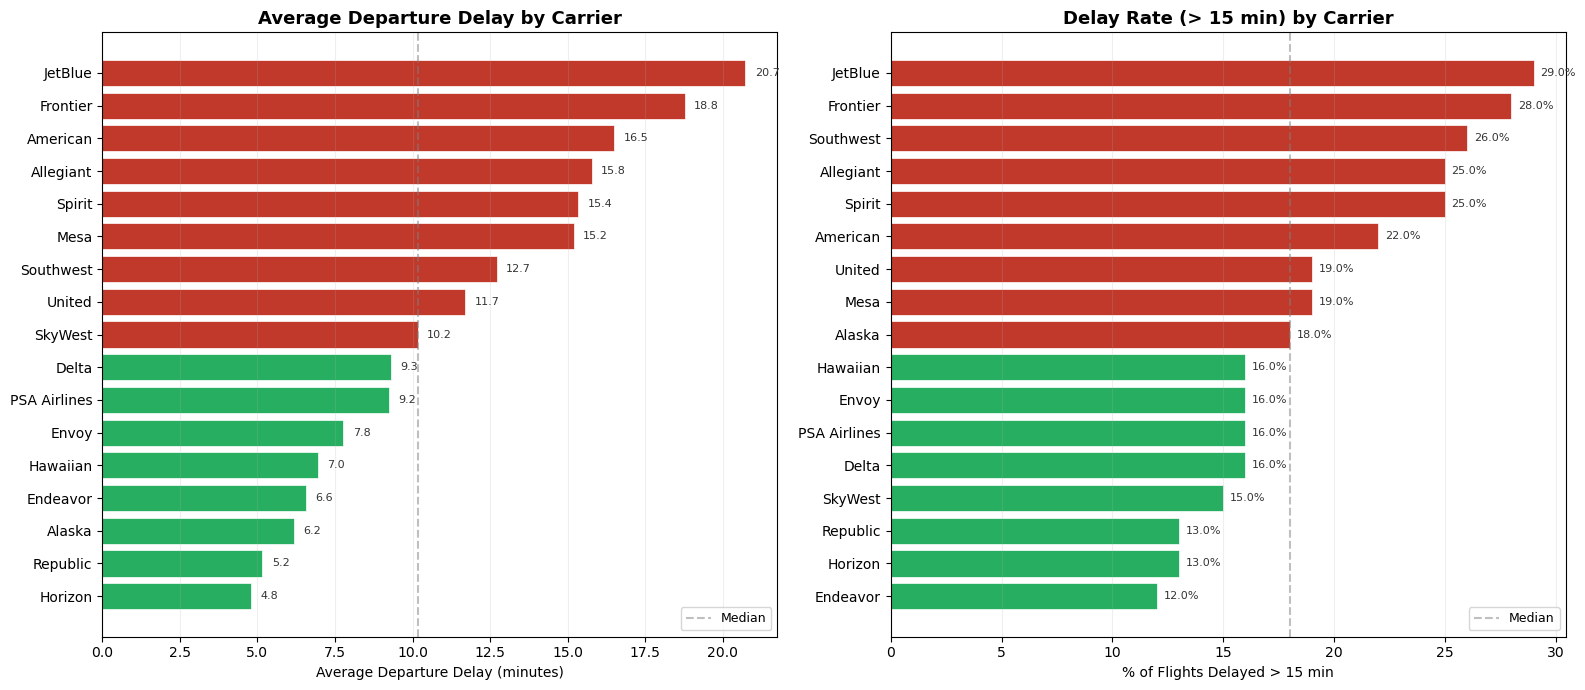

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left panel: Average delay ---
carrier_stats_sorted = carrier_stats.sort_values('avg_delay', ascending=True)
colors = ['#27ae60' if x < carrier_stats['avg_delay'].median() else '#c0392b'
          for x in carrier_stats_sorted['avg_delay']]
bars = axes[0].barh(carrier_stats_sorted.index, carrier_stats_sorted['avg_delay'],
                    color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Average Departure Delay (minutes)', fontsize=10)
axes[0].set_title('Average Departure Delay by Carrier', fontsize=13, fontweight='bold')
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].axvline(x=carrier_stats['avg_delay'].median(), color='gray',
                linestyle='--', alpha=0.5, label='Median')
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.2)
# Value labels
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{w:.1f}', va='center', fontsize=8, color='#333')

# --- Right panel: Delay rate ---
carrier_stats_sorted2 = carrier_stats.sort_values('delay_rate', ascending=True)
colors2 = ['#27ae60' if x < carrier_stats['delay_rate'].median() else '#c0392b'
           for x in carrier_stats_sorted2['delay_rate']]
bars2 = axes[1].barh(carrier_stats_sorted2.index, carrier_stats_sorted2['delay_rate'] * 100,
                     color=colors2, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('% of Flights Delayed > 15 min', fontsize=10)
axes[1].set_title('Delay Rate (> 15 min) by Carrier', fontsize=13, fontweight='bold')
axes[1].axvline(x=carrier_stats['delay_rate'].median() * 100, color='gray',
                linestyle='--', alpha=0.5, label='Median')
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.2)
for bar in bars2:
    w = bar.get_width()
    axes[1].text(w + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{w:.1f}%', va='center', fontsize=8, color='#333')

plt.tight_layout()
plt.show()

### Q2: Which airlines have the best cost-to-performance ratio?

The BTS on-time dataset does not include ticket prices, so we cannot compute a true cost-to-performance ratio. Instead, we approximate value by comparing each carrier's delay performance against its average flight distance — longer routes face more operational complexity, so a carrier flying mostly long-haul routes with low delay rates is arguably delivering more value per flight.

In [14]:
carrier_value = df_delays.groupby('CARRIER_NAME').agg(
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean'),
    avg_distance=('DISTANCE', 'mean'),
    total_flights=('DEP_DELAY', 'count')
).round(2)

carrier_value['miles_per_delay_min'] = (carrier_value['avg_distance'] / carrier_value['avg_delay'].clip(lower=0.1)).round(1)
carrier_value = carrier_value.sort_values('miles_per_delay_min', ascending=False)

print("Carrier Value (miles per minute of avg delay — higher = better):")
print(carrier_value.to_string())

Carrier Value (miles per minute of avg delay — higher = better):
              avg_delay  delay_rate  avg_distance  total_flights  miles_per_delay_min
CARRIER_NAME                                                                         
Alaska         6.170000        0.18   1381.829956         892279           224.000000
Hawaiian       6.960000        0.16    922.289978         291085           132.500000
Delta          9.300000        0.16    948.359985        3598239           102.000000
Republic       5.160000        0.13    516.549988        1211876           100.099998
United        11.700000        0.19   1145.369995        2525232            97.900002
Horizon        4.800000        0.13    444.019989         196811            92.500000
Envoy          7.770000        0.16    513.289978         993686            66.099998
Spirit        15.350000        0.25    995.049988         926617            64.800003
Endeavor       6.550000        0.12    418.489990         882219           

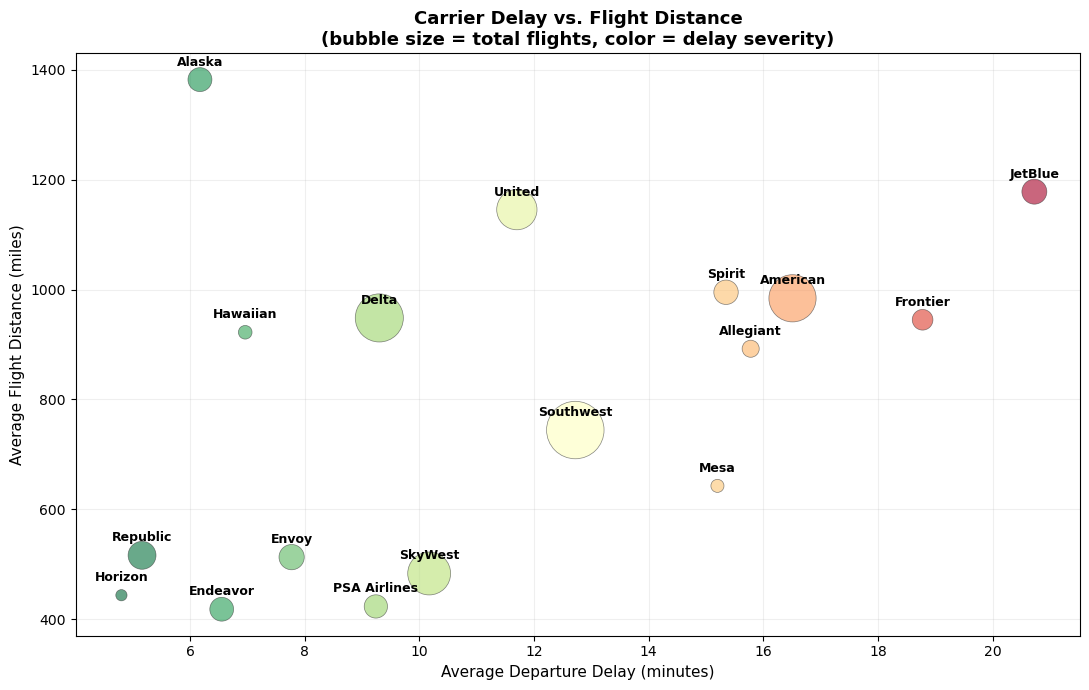

In [94]:
fig, ax = plt.subplots(figsize=(11, 7))

sizes = carrier_value['total_flights'] / 3000
scatter = ax.scatter(carrier_value['avg_delay'], carrier_value['avg_distance'],
                     s=sizes, alpha=0.6, c=carrier_value['avg_delay'],
                     cmap='RdYlGn_r', edgecolors='#333', linewidth=0.5, zorder=3)

for carrier in carrier_value.index:
    ax.annotate(carrier,
                (carrier_value.loc[carrier, 'avg_delay'],
                 carrier_value.loc[carrier, 'avg_distance']),
                fontsize=9, fontweight='bold', ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.set_xlabel('Average Departure Delay (minutes)', fontsize=11)
ax.set_ylabel('Average Flight Distance (miles)', fontsize=11)
ax.set_title('Carrier Delay vs. Flight Distance\n(bubble size = total flights, color = delay severity)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Q3: Which airports cause the biggest delays across the network?

We group by origin airport and calculate average departure delay and delay rate. Airports with high average delays may be bottlenecks that cascade delays through the network. We focus on our 75 airports with FAA metadata so we can also examine whether hub size correlates with delay severity.

In [19]:
top_75 = df_delays[df_delays['hub_size'].notna()]['ORIGIN'].unique()
airport_stats = df_delays[df_delays['ORIGIN'].isin(top_75)].groupby('ORIGIN').agg(
    flights=('DEP_DELAY', 'count'),
    avg_delay=('DEP_DELAY', 'mean'),
    median_delay=('DEP_DELAY', 'median'),
    delay_rate=('DEP_DEL15', 'mean')
).round(2)

airport_stats = airport_stats.sort_values('avg_delay', ascending=False)

print(f"Airports analyzed: {len(airport_stats)}")
print(f"\nTop 15 worst airports by average departure delay:")
print(airport_stats.head(15).to_string())
print(f"\nBottom 5 (best):")
print(airport_stats.tail(5).to_string())

Airports analyzed: 75

Top 15 worst airports by average departure delay:
        flights  avg_delay  median_delay  delay_rate
ORIGIN                                              
FLL      346252  17.690001           0.0        0.27
SJU      125336  17.670000          -2.0        0.24
MIA      404130  17.070000          -1.0        0.25
MCO      590904  17.020000           0.0        0.26
PBI      101048  16.180000          -2.0        0.23
BWI      349636  15.910000           3.0        0.30
DFW     1128779  15.680000          -2.0        0.24
EWR      471727  15.490000          -2.0        0.24
MDW      299610  15.250000           3.0        0.30
DAL      266280  15.020000           2.0        0.29
DEN     1110226  14.880000           0.0        0.26
JFK      464348  14.670000          -2.0        0.22
LAS      687268  14.040000           0.0        0.26
IAH      474051  14.010000          -1.0        0.21
HOU      207727  13.270000           1.0        0.26

Bottom 5 (best):
        

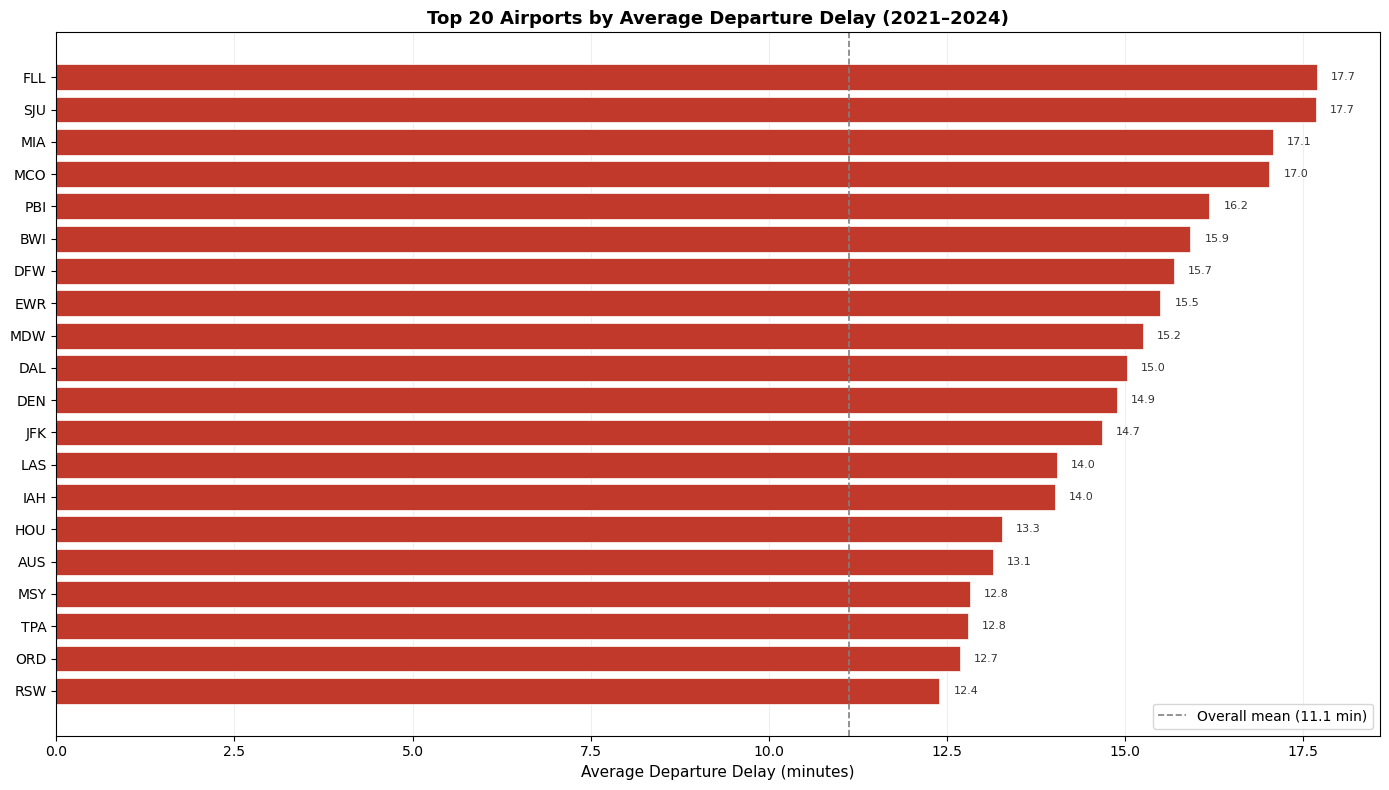

In [96]:
top_airports_delay = airport_stats.head(20)
overall_mean = airport_stats['avg_delay'].mean()

fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#c0392b' if x > overall_mean else '#2c7bb6'
          for x in top_airports_delay['avg_delay'][::-1]]
bars = ax.barh(top_airports_delay.index[::-1], top_airports_delay['avg_delay'][::-1],
               color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(x=overall_mean, color='gray', linestyle='--', linewidth=1.2,
           label=f'Overall mean ({overall_mean:.1f} min)')

# Value labels
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.2, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}', va='center', fontsize=8, color='#333')

ax.set_xlabel('Average Departure Delay (minutes)', fontsize=11)
ax.set_title('Top 20 Airports by Average Departure Delay (2021–2024)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [23]:
hub_delay = df_delays[df_delays['hub_size'].notna()].groupby('hub_size', observed=True).agg(
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean'),
    flights=('DEP_DELAY', 'count')
).round(3)

print("Delay by hub size:")
print(hub_delay)

groups = [group['DEP_DELAY'].dropna() for name, group in df_delays[df_delays['hub_size'].notna()].groupby('hub_size', observed=True)]
f_stat, p_val = stats.f_oneway(*groups)
print(f"\nOne-way ANOVA: F = {f_stat:.2f}, p = {p_val:.2e}")
print("Reject null (delays differ by hub size)" if p_val < 0.05 else "Fail to reject null")

Delay by hub size:
          avg_delay  delay_rate   flights
hub_size                                 
L            12.491       0.211  17108443
M            10.525       0.191   4643986
S             9.728       0.166    886462

One-way ANOVA: F = 3590.90, p = 0.00e+00
Reject null (delays differ by hub size)


### Q4: What are the most common causes of delays?

The BTS data breaks delays into five categories: carrier, weather, NAS (National Aviation System — air traffic control, airport operations), security, and late aircraft. These columns are only populated for flights delayed more than 15 minutes, so we filter to delayed flights only. We examine both the total minutes attributed to each cause and the frequency with which each cause appears.

In [26]:
delay_causes = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']

delayed_flights = df_delays[df_delays['CARRIER_DELAY'].notna()].copy()
print(f"Flights with delay cause data: {len(delayed_flights):,}")

cause_totals = delayed_flights[delay_causes].sum().sort_values(ascending=False)
cause_pct = (cause_totals / cause_totals.sum() * 100).round(1)

print(f"\nTotal delay minutes by cause:")
for cause, mins in cause_totals.items():
    label = cause.replace('_DELAY', '').title()
    pct = round(float(cause_pct[cause]), 1)
    print(f"  {label:20s}: {mins:>15,.0f} min ({pct}%)")

Flights with delay cause data: 5,223,798

Total delay minutes by cause:
  Late_Aircraft       :     138,639,584 min (38.6%)
  Carrier             :     134,736,256 min (37.6%)
  Nas                 :      63,628,328 min (17.7%)
  Weather             :      20,928,666 min (5.8%)
  Security            :         808,827 min (0.2%)


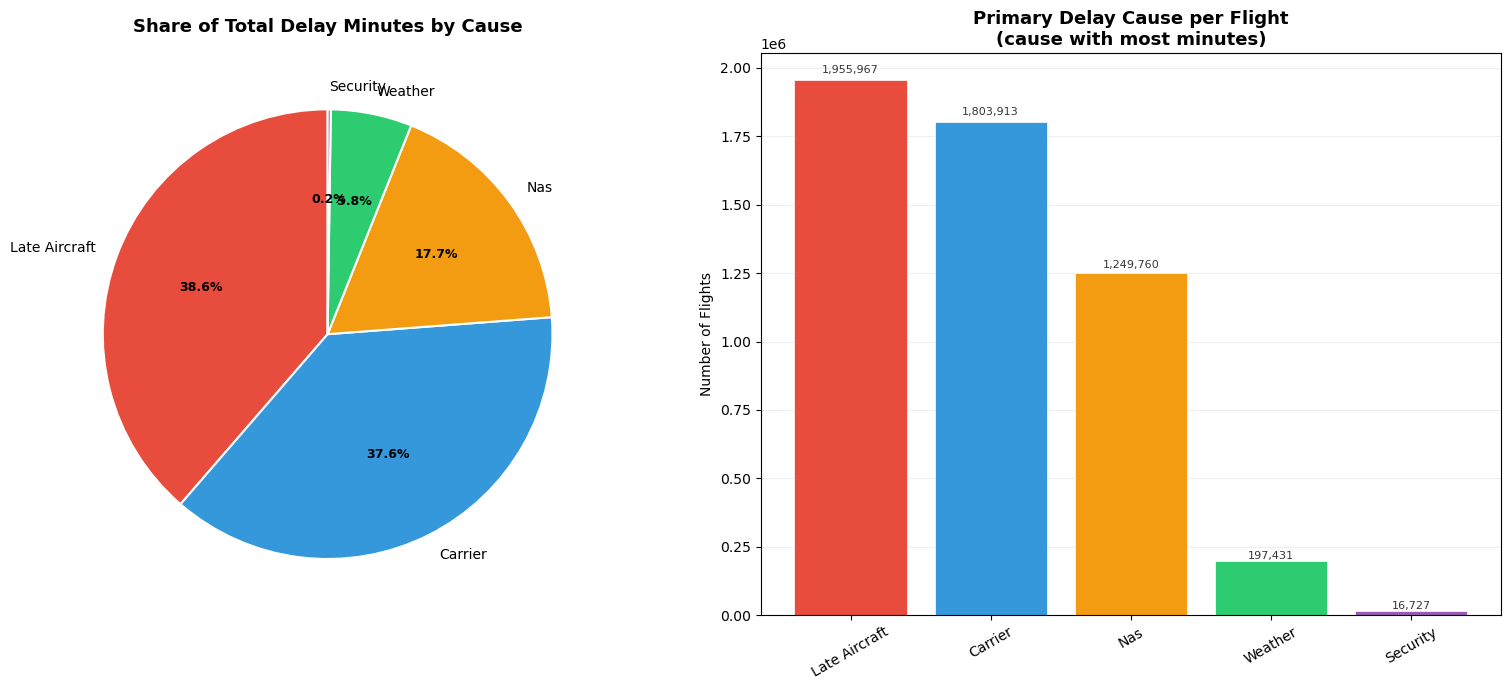

In [98]:
delayed_flights['primary_cause'] = delayed_flights[delay_causes].idxmax(axis=1)
primary_counts = delayed_flights['primary_cause'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: Pie chart ---
labels = [c.replace('_DELAY', '').replace('_', ' ').title() for c in cause_totals.index]
pie_colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71', '#9b59b6']
wedges, texts, autotexts = axes[0].pie(cause_totals, labels=labels, autopct='%1.1f%%',
                                        startangle=90, colors=pie_colors,
                                        textprops={'fontsize': 10},
                                        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
axes[0].set_title('Share of Total Delay Minutes by Cause',
                  fontsize=13, fontweight='bold', pad=15)

# --- Right: Bar chart ---
primary_labels = [c.replace('_DELAY', '').replace('_', ' ').title() for c in primary_counts.index]
bar_colors = [pie_colors[list(cause_totals.index).index(c)] if c in cause_totals.index
              else '#95a5a6' for c in primary_counts.index]
bars = axes[1].bar(primary_labels, primary_counts.values, color=bar_colors,
                   edgecolor='white', linewidth=0.5)
axes[1].set_ylabel('Number of Flights', fontsize=10)
axes[1].set_title('Primary Delay Cause per Flight\n(cause with most minutes)',
                  fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.2)
axes[1].set_axisbelow(True)

# Value labels
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + h*0.01,
                 f'{h:,.0f}', ha='center', va='bottom', fontsize=8, color='#333')

plt.tight_layout()
plt.show()

### Q5: Are certain routes worse than others?

We create an origin-destination route column and identify the routes with the highest average delays and highest delay rates. We filter to routes with at least 1,000 flights over the 4-year period to avoid small-sample noise.

In [31]:
top_75 = df_delays[df_delays['hub_size'].notna()]['ORIGIN'].unique()

df_top = df_delays[(df_delays['ORIGIN'].isin(top_75)) & (df_delays['DEST'].isin(top_75))].copy()
df_top['ROUTE'] = df_top['ORIGIN'] + ' → ' + df_top['DEST']

route_stats = df_top.groupby('ROUTE').agg(
    flights=('DEP_DELAY', 'count'),
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean'),
    avg_distance=('DISTANCE', 'mean')
).round(2)

route_stats = route_stats[route_stats['flights'] >= 1000]
print(f"Routes with 1,000+ flights (top 75 airports only): {len(route_stats):,}")

print(f"\nTop 15 worst routes by average delay:")
print(route_stats.sort_values('avg_delay', ascending=False).head(15).to_string())

print(f"\nTop 10 best routes (lowest avg delay):")
print(route_stats.sort_values('avg_delay', ascending=True).head(10).to_string())

Routes with 1,000+ flights (top 75 airports only): 2,633

Top 15 worst routes by average delay:
           flights  avg_delay  delay_rate  avg_distance
ROUTE                                                  
ONT → JFK     1131  38.130001        0.38        2429.0
BUR → JFK     1400  37.950001        0.44        2465.0
ANC → DFW     1214  35.650002        0.34        3043.0
SJU → DCA     1374  34.840000        0.41        1554.0
SAN → FLL     1462  34.680000        0.38        2269.0
BDL → SJU     3178  34.049999        0.45        1666.0
SMF → JFK     1135  33.230000        0.37        2521.0
DFW → GEG     2253  33.130001        0.38        1477.0
JFK → SMF     1141  33.060001        0.45        2521.0
IAH → JFK     1579  32.380001        0.38        1417.0
SJU → BDL     3185  30.700001        0.41        1666.0
SAT → JFK     1714  30.090000        0.29        1587.0
JFK → ONT     1136  27.969999        0.40        2429.0
MIA → SAN     1573  26.260000        0.32        2267.0
SAT → BO

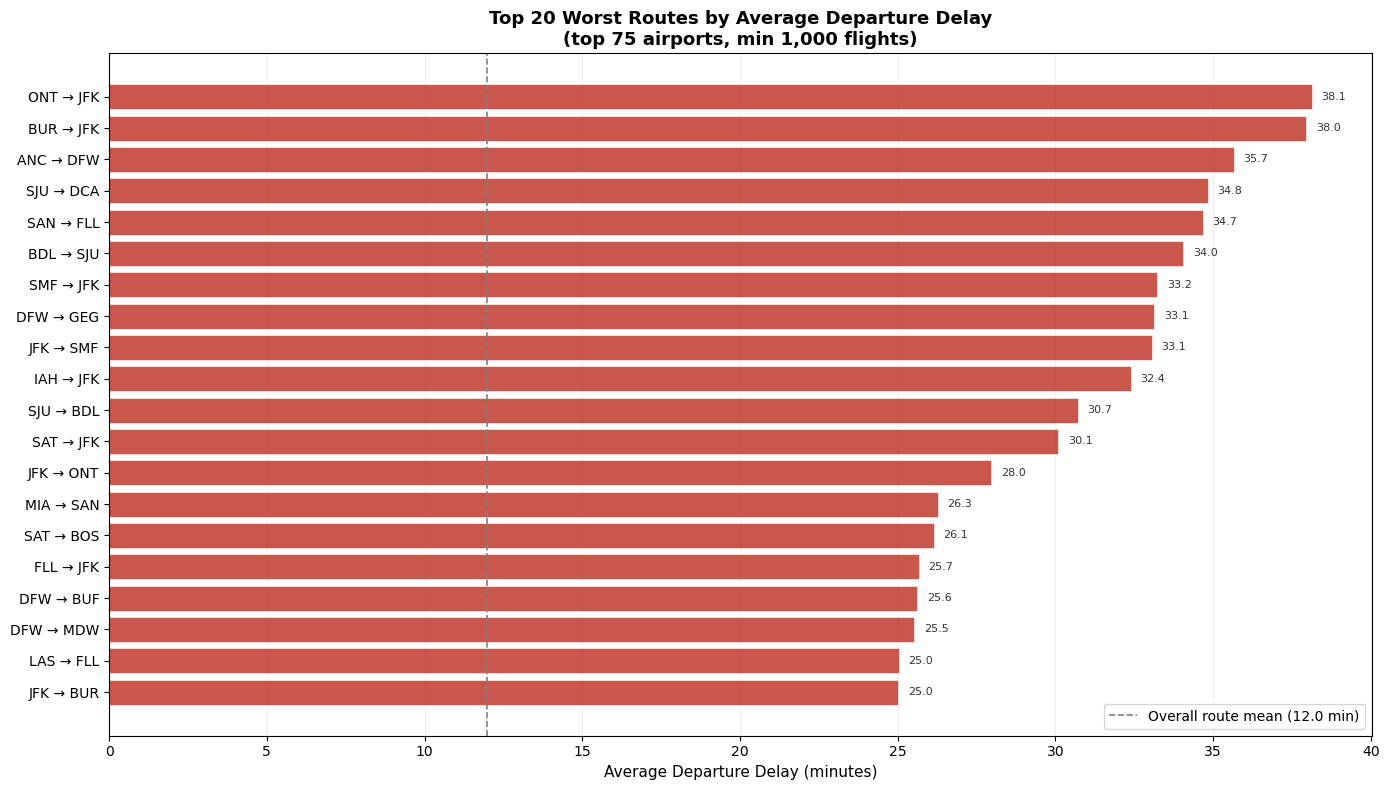

In [100]:
fig, ax = plt.subplots(figsize=(14, 8))

worst_routes = route_stats.sort_values('avg_delay', ascending=False).head(20)
route_mean = route_stats['avg_delay'].mean()

bars = ax.barh(worst_routes.index[::-1], worst_routes['avg_delay'][::-1],
               color='#c0392b', edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(x=route_mean, color='gray', linestyle='--', linewidth=1.2,
           label=f'Overall route mean ({route_mean:.1f} min)')

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}', va='center', fontsize=8, color='#333')

ax.set_xlabel('Average Departure Delay (minutes)', fontsize=11)
ax.set_title('Top 20 Worst Routes by Average Departure Delay\n(top 75 airports, min 1,000 flights)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [134]:
# Build coordinate lookup from the merged data
coord_lookup = df_delays[df_delays['latitude'].notna()].groupby('ORIGIN').agg(
    lat=('latitude', 'first'),
    lon=('longitude', 'first')
).to_dict('index')

worst_25 = route_stats.sort_values('avg_delay', ascending=False).head(25)
best_25 = route_stats.sort_values('avg_delay', ascending=True).head(25)

# Get city names for airports
city_lookup = df_delays[df_delays['ORIGIN_CITY_NAME'].notna()].groupby('ORIGIN')['ORIGIN_CITY_NAME'].first().to_dict()

def great_circle_points(lat1, lon1, lat2, lon2, n_points=30):
    """Interpolate points along a great circle arc between two coordinates."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    d = np.arccos(np.sin(lat1)*np.sin(lat2) + np.cos(lat1)*np.cos(lat2)*np.cos(lon2-lon1))
    if d < 1e-10:
        return [[np.degrees(lat1), np.degrees(lon1)]]
    points = []
    for f in np.linspace(0, 1, n_points):
        A = np.sin((1-f)*d) / np.sin(d)
        B = np.sin(f*d) / np.sin(d)
        x = A*np.cos(lat1)*np.cos(lon1) + B*np.cos(lat2)*np.cos(lon2)
        y = A*np.cos(lat1)*np.sin(lon1) + B*np.cos(lat2)*np.sin(lon2)
        z = A*np.sin(lat1) + B*np.sin(lat2)
        lat = np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2)))
        lon = np.degrees(np.arctan2(y, x))
        points.append([lat, lon])
    return points

def build_route_map(route_df, color, title, label):
    m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles='CartoDB positron')
    
    # Track which routes connect to each airport
    airport_route_info = {}
    route_airports = set()
    
    for idx, (route, row) in enumerate(route_df.iterrows()):
        rank = idx + 1
        origin, dest = route.split(' → ')
        if origin not in coord_lookup or dest not in coord_lookup:
            continue
        route_airports.update([origin, dest])
        
        route_detail = {
            'rank': rank,
            'origin': origin, 'dest': dest,
            'origin_city': city_lookup.get(origin, origin),
            'dest_city': city_lookup.get(dest, dest),
            'avg_delay': float(row['avg_delay']),
            'delay_rate': float(row['delay_rate']),
            'flights': int(row['flights']),
            'distance': int(row['avg_distance']),
        }
        for code in [origin, dest]:
            if code not in airport_route_info:
                airport_route_info[code] = []
            airport_route_info[code].append(route_detail)
        
        o = coord_lookup[origin]
        d = coord_lookup[dest]
        arc = great_circle_points(o['lat'], o['lon'], d['lat'], d['lon'])
        weight = max(2, min(6, row['avg_delay'] / 8))
        
        # Ordinal suffix
        def ordinal(n):
            if 11 <= n % 100 <= 13:
                return f"{n}th"
            return f"{n}" + {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
        
        # Route line popup
        route_popup = (
            f"<div style='font-family: Arial; min-width: 220px;'>"
            f"<div style='font-size: 11px; color: white; background: {color}; "
            f"display: inline-block; padding: 2px 8px; border-radius: 3px; "
            f"margin-bottom: 6px; font-weight: bold;'>"
            f"#{rank} {label} route</div>"
            f"<div style='font-size: 14px; font-weight: bold; color: {color}; "
            f"margin-bottom: 4px;'>✈ {origin} → {dest}</div>"
            f"<div style='color: #666; font-size: 11px; margin-bottom: 8px;'>"
            f"{city_lookup.get(origin, origin)} → {city_lookup.get(dest, dest)}</div>"
            f"<table style='font-size: 12px; width: 100%; border-collapse: collapse;'>"
            f"<tr><td style='padding: 3px 8px 3px 0; color: #888;'>Distance</td>"
            f"<td style='padding: 3px 0; font-weight: bold;'>{int(row['avg_distance']):,} mi</td></tr>"
            f"<tr><td style='padding: 3px 8px 3px 0; color: #888;'>Flights (4yr)</td>"
            f"<td style='padding: 3px 0; font-weight: bold;'>{int(row['flights']):,}</td></tr>"
            f"<tr><td style='padding: 3px 8px 3px 0; color: #888;'>Avg Delay</td>"
            f"<td style='padding: 3px 0; font-weight: bold;'>{row['avg_delay']:.1f} min</td></tr>"
            f"<tr><td style='padding: 3px 8px 3px 0; color: #888;'>Delay Rate</td>"
            f"<td style='padding: 3px 0; font-weight: bold;'>{row['delay_rate']*100:.1f}%</td></tr>"
            f"</table></div>"
        )
        
        folium.PolyLine(
            locations=arc,
            color=color,
            weight=weight,
            opacity=0.6,
            tooltip=f"<b>#{rank} — {origin} → {dest}</b> | {row['avg_delay']:.1f} min avg delay",
            popup=folium.Popup(route_popup, max_width=280)
        ).add_to(m)
    
    # Add airport markers with popup showing all connected routes
    for code in route_airports:
        info = coord_lookup[code]
        routes = airport_route_info.get(code, [])
        city = city_lookup.get(code, '')
        
        # Sort by rank
        routes_sorted = sorted(routes, key=lambda r: r['rank'])
        
        def ordinal(n):
            if 11 <= n % 100 <= 13:
                return f"{n}th"
            return f"{n}" + {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
        
        popup_html = (
            f"<div style='font-family: Arial; min-width: 270px; max-height: 400px; overflow-y: auto;'>"
            f"<div style='font-size: 16px; font-weight: bold; color: {color}; "
            f"margin-bottom: 2px;'>✈ {code}</div>"
            f"<div style='color: #666; font-size: 12px; margin-bottom: 10px;'>"
            f"{city}</div>"
            f"<div style='color: #888; font-size: 11px; margin-bottom: 8px;'>"
            f"{len(routes_sorted)} connected route{'s' if len(routes_sorted) != 1 else ''} "
            f"in the {label} 25</div>"
        )
        
        for r in routes_sorted:
            other = r['dest'] if r['origin'] == code else r['origin']
            other_city = r['dest_city'] if r['origin'] == code else r['origin_city']
            direction = '→' if r['origin'] == code else '←'
            rank = r['rank']
            
            popup_html += (
                f"<div style='background: #f8f8f8; border-radius: 5px; padding: 8px 10px; "
                f"margin-bottom: 6px; border-left: 3px solid {color};'>"
                f"<div style='display: flex; justify-content: space-between; align-items: center;'>"
                f"<span style='font-weight: bold; font-size: 13px;'>"
                f"{code} {direction} {other}</span>"
                f"<span style='font-size: 10px; color: white; background: {color}; "
                f"padding: 1px 6px; border-radius: 3px; font-weight: bold;'>"
                f"#{rank}</span></div>"
                f"<div style='color: #666; font-size: 11px; margin-bottom: 4px;'>"
                f"{other_city} — {ordinal(rank)} {label} route overall</div>"
                f"<table style='font-size: 11px; width: 100%;'>"
                f"<tr><td style='color: #888;'>Distance: <b>{r['distance']:,} mi</b></td>"
                f"<td style='color: #888;'>Flights: <b>{r['flights']:,}</b></td></tr>"
                f"<tr><td style='color: #888;'>Avg Delay: <b>{r['avg_delay']:.1f} min</b></td>"
                f"<td style='color: #888;'>Delay Rate: <b>{r['delay_rate']*100:.1f}%</b></td></tr>"
                f"</table></div>"
            )
        
        popup_html += "</div>"
        
        folium.Marker(
            location=[info['lat'], info['lon']],
            tooltip=f"<b>{code}</b> — {city}<br><i>Click for {len(routes_sorted)} route{'s' if len(routes_sorted) != 1 else ''}</i>",
            popup=folium.Popup(popup_html, max_width=310),
            icon=folium.DivIcon(
                html=(f'<div style="font-size: 16px; color: #333; cursor: pointer; '
                      f'text-shadow: 1px 1px 2px white, -1px -1px 2px white;">✈</div>'),
                icon_size=(20, 20),
                icon_anchor=(10, 10)
            )
        ).add_to(m)
    
    # Title + legend
    title_html = f"""
    <div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
         z-index: 1000; background: white; padding: 8px 18px; border: 2px solid {color};
         border-radius: 5px; font-size: 15px; font-weight: bold; color: {color};">
        {title}
    </div>
    <div style="position: fixed; bottom: 15px; left: 15px; z-index: 1000;
         background: white; padding: 6px 10px; border: 1px solid #ccc;
         border-radius: 4px; font-size: 11px; color: #666;">
        Click any ✈ for airport route details &bull; Click any route arc for flight info
    </div>
    """
    m.get_root().html.add_child(folium.Element(title_html))
    return m

# --- Map 1: 25 Worst routes ---
print("25 Worst Routes by Average Departure Delay:")
m_worst = build_route_map(worst_25, '#c0392b', '25 Worst Routes by Avg Departure Delay', 'worst')
display(m_worst)

# --- Map 2: 25 Best routes ---
print("\n25 Best Routes by Average Departure Delay:")
m_best = build_route_map(best_25, '#27ae60', '25 Best Routes by Avg Departure Delay', 'best')
display(m_best)

25 Worst Routes by Average Departure Delay:



25 Best Routes by Average Departure Delay:


### Q6: Do delays vary by season?

We categorize months into four seasons and compare average delay and delay rates. We also use one-way ANOVA to test whether the mean delay is statistically significantly different across seasons, and follow up with pairwise t-tests if so.

In [36]:
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall', 10: 'Fall', 11: 'Fall'}

df_delays['SEASON'] = df_delays['MONTH'].map(season_map)

season_stats = df_delays.groupby('SEASON').agg(
    flights=('DEP_DELAY', 'count'),
    avg_delay=('DEP_DELAY', 'mean'),
    median_delay=('DEP_DELAY', 'median'),
    delay_rate=('DEP_DEL15', 'mean')
).round(3)

season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_stats = season_stats.loc[season_order]
print("Seasonal delay statistics:")
print(season_stats.to_string())

season_groups = [group['DEP_DELAY'].dropna() for name, group in df_delays.groupby('SEASON')]
f_stat, p_val = stats.f_oneway(*season_groups)
print(f"\nOne-way ANOVA: F = {f_stat:.2f}, p = {p_val:.2e}")

Seasonal delay statistics:
        flights  avg_delay  median_delay  delay_rate
SEASON                                              
Winter  5935398  11.223000          -2.0       0.194
Spring  6514852  11.236000          -2.0       0.195
Summer  6964530  16.724001          -1.0       0.250
Fall    6768118   7.742000          -3.0       0.160

One-way ANOVA: F = 33752.31, p = 0.00e+00


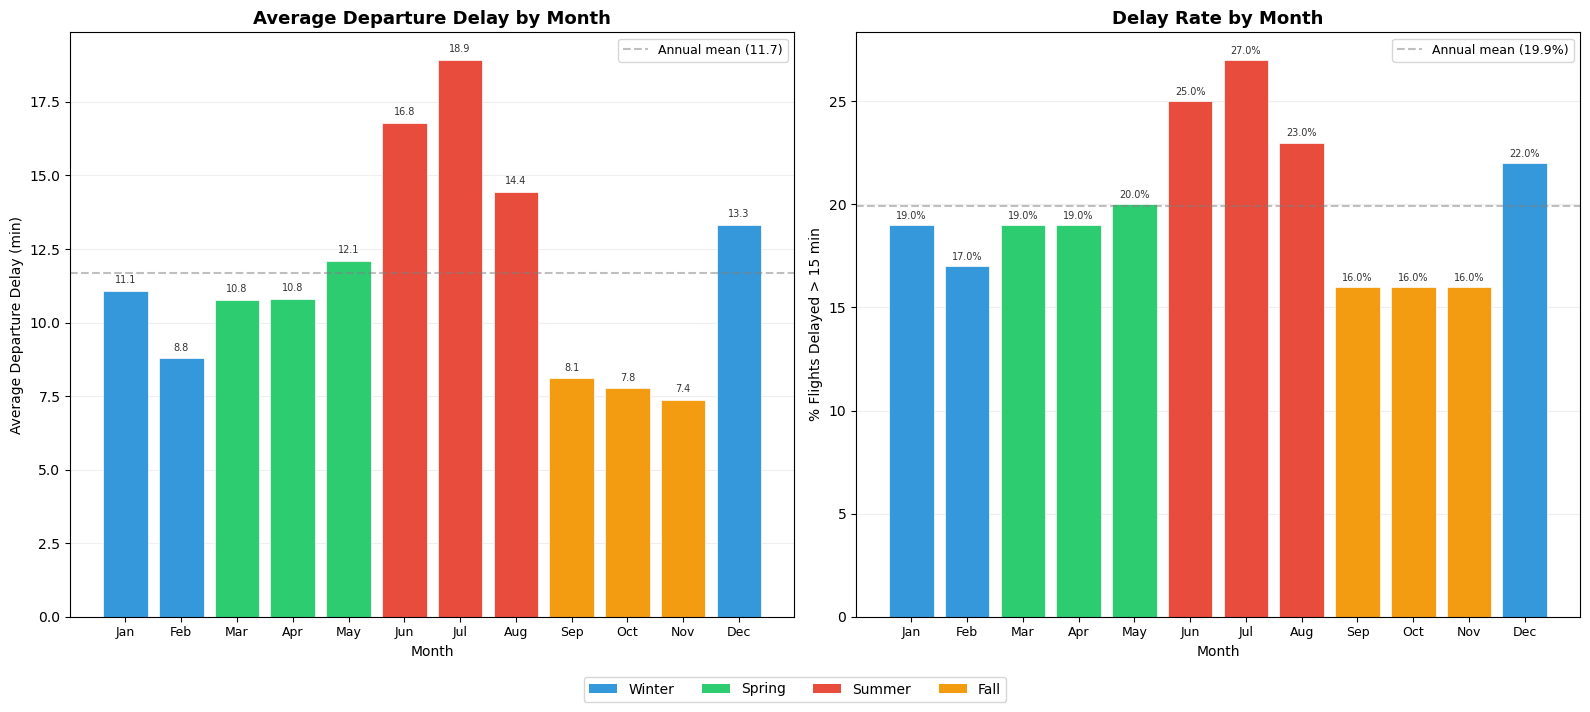

In [102]:
monthly = df_delays.groupby('MONTH').agg(
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean')
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = {'Winter': '#3498db', 'Spring': '#2ecc71', 'Summer': '#e74c3c', 'Fall': '#f39c12'}
month_colors = [colors[season_map[m]] for m in monthly.index]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# --- Left: Average delay ---
bars = axes[0].bar(monthly.index, monthly['avg_delay'], color=month_colors,
                   edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Month', fontsize=10)
axes[0].set_ylabel('Average Departure Delay (min)', fontsize=10)
axes[0].set_title('Average Departure Delay by Month', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels, fontsize=9)
axes[0].axhline(y=monthly['avg_delay'].mean(), color='gray', linestyle='--',
                alpha=0.5, label=f'Annual mean ({monthly["avg_delay"].mean():.1f})')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.2)
axes[0].set_axisbelow(True)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.2,
                 f'{h:.1f}', ha='center', va='bottom', fontsize=7, color='#333')

# --- Right: Delay rate ---
bars2 = axes[1].bar(monthly.index, monthly['delay_rate'] * 100, color=month_colors,
                    edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Month', fontsize=10)
axes[1].set_ylabel('% Flights Delayed > 15 min', fontsize=10)
axes[1].set_title('Delay Rate by Month', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels, fontsize=9)
axes[1].axhline(y=monthly['delay_rate'].mean() * 100, color='gray', linestyle='--',
                alpha=0.5, label=f'Annual mean ({monthly["delay_rate"].mean()*100:.1f}%)')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.2)
axes[1].set_axisbelow(True)
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.2,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=7, color='#333')

# Season legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in colors.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

### Q7: Does weather significantly predict delay length, or is it less impactful than people assume?

We first quantify how much of the total delay burden is weather-attributed (using the BTS WEATHER_DELAY column). Then we test whether our continuous weather variables (precipitation, snowfall, wind speed, temperature) correlate with departure delay using Pearson correlation and a multivariate OLS regression. This lets us estimate how many minutes of delay each weather variable contributes while controlling for the others.

In [41]:
delayed_wx = df_delays[df_delays['WEATHER_DELAY'].notna()]
cause_cols = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
cause_shares = delayed_wx[cause_cols].sum()
cause_shares_pct = (cause_shares / cause_shares.sum() * 100).round(1)

print("Share of total delay minutes by cause:")
for col in cause_cols:
    label = col.replace('_DELAY', '').title()
    pct = round(float(cause_shares_pct[col]), 1)
    print(f"  {label:20s}: {pct}%")

print(f"\nWeather accounts for only {round(float(cause_shares_pct['WEATHER_DELAY']), 1)}% of total delay minutes.")

Share of total delay minutes by cause:
  Carrier             : 37.6%
  Weather             : 5.8%
  Nas                 : 17.7%
  Security            : 0.2%
  Late_Aircraft       : 38.6%

Weather accounts for only 5.8% of total delay minutes.


In [43]:
weather_cols = ['precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_min', 
                'max_wind_gust', 'temp_range', 'weather_severity']

corr_with_delay = df_weather[weather_cols + ['DEP_DELAY']].corr()['DEP_DELAY'].drop('DEP_DELAY').sort_values(ascending=False)

print("Pearson correlation with DEP_DELAY:")
for var, r in corr_with_delay.items():
    print(f"  {var:20s}: r = {r:.4f}")

Pearson correlation with DEP_DELAY:
  precipitation       : r = 0.0726
  max_wind_gust       : r = 0.0531
  weather_severity    : r = 0.0442
  temp_min            : r = 0.0389
  snowfall            : r = 0.0316
  temp_max            : r = 0.0280
  avg_wind            : r = 0.0215
  temp_range          : r = -0.0209


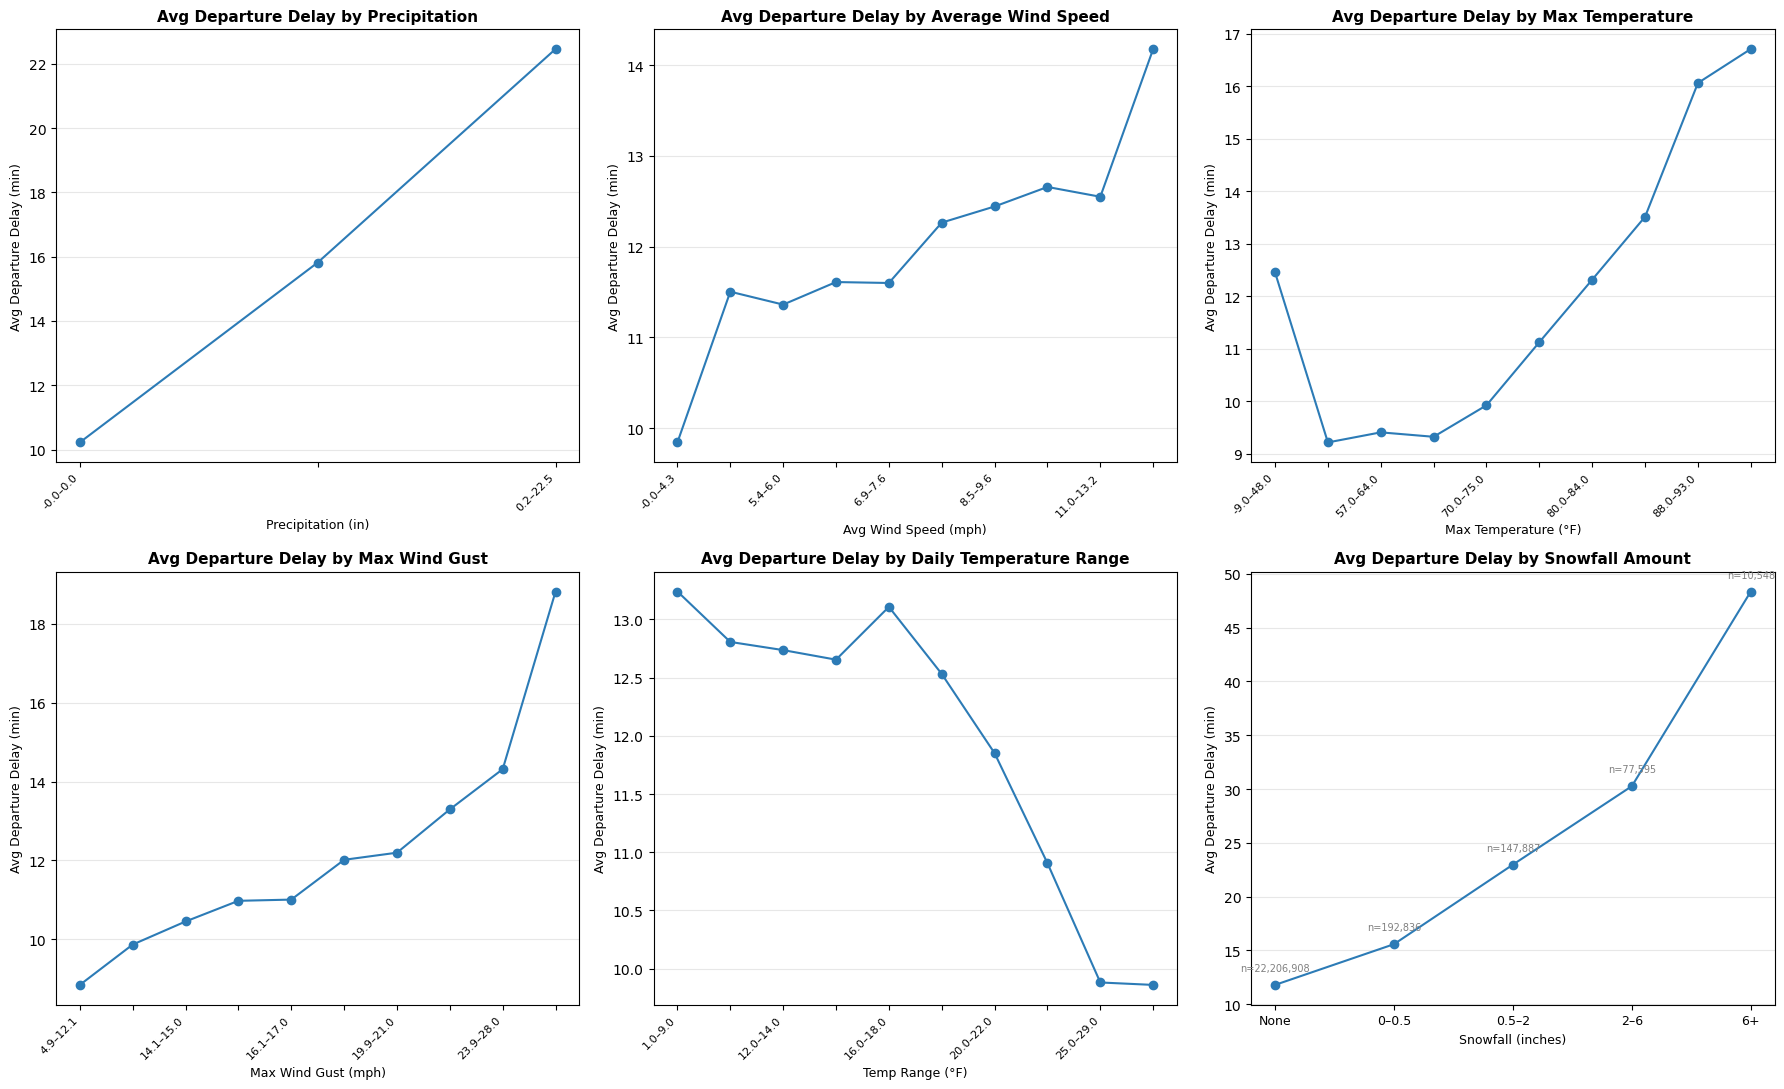

In [90]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# --- Config for the 5 decile variables ---
decile_vars = [
    ('precipitation', 'Precipitation (in)',    'Precipitation'),
    ('avg_wind',      'Avg Wind Speed (mph)',  'Average Wind Speed'),
    ('temp_max',      'Max Temperature (°F)',  'Max Temperature'),
    ('max_wind_gust', 'Max Wind Gust (mph)',   'Max Wind Gust'),
    ('temp_range',    'Temp Range (°F)',       'Daily Temperature Range'),
]

for ax, (var, xlabel, title) in zip(axes.flatten(), decile_vars):
    df_weather['_bin'] = pd.qcut(df_weather[var], q=10, duplicates='drop')
    binned = df_weather.groupby('_bin', observed=True)['DEP_DELAY'].mean()

    # Build clean tick labels: show the range for each bin
    labels = [f"{iv.left:.1f}–{iv.right:.1f}" for iv in binned.index]

    ax.plot(range(len(binned)), binned.values, marker='o', linewidth=1.5,
            markersize=6, color='#2c7bb6')
    ax.set_xticks(range(len(binned)))
    # Show every other label to prevent overlap
    display_labels = [labels[i] if i % 2 == 0 else '' for i in range(len(labels))]
    ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'Avg Departure Delay by {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Avg Departure Delay (min)', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# --- Snowfall: manual bins (zero-inflated, qcut fails) ---
ax = axes.flatten()[5]
snow_bins = pd.cut(df_weather['snowfall'],
                   bins=[-0.01, 0, 0.5, 2.0, 6.0, 100],
                   labels=['None', '0–0.5', '0.5–2', '2–6', '6+'])
snow_delay = df_weather.groupby(snow_bins, observed=True)['DEP_DELAY'].mean()
snow_counts = df_weather.groupby(snow_bins, observed=True)['DEP_DELAY'].count()

ax.plot(range(len(snow_delay)), snow_delay.values, marker='o', linewidth=1.5,
        markersize=6, color='#2c7bb6')
ax.set_xticks(range(len(snow_delay)))
ax.set_xticklabels(snow_delay.index, fontsize=9)
ax.set_title('Avg Departure Delay by Snowfall Amount', fontsize=11, fontweight='bold')
ax.set_xlabel('Snowfall (inches)', fontsize=9)
ax.set_ylabel('Avg Departure Delay (min)', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Annotate flight counts so the reader sees sample sizes
for i, (cat, n) in enumerate(snow_counts.items()):
    ax.annotate(f'n={n:,}', (i, snow_delay[cat]),
                textcoords='offset points', xytext=(0, 10),
                fontsize=7, ha='center', color='gray')

df_weather.drop(columns=['_bin'], inplace=True, errors='ignore')
plt.tight_layout()
plt.show()

In [47]:
features = ['precipitation', 'snowfall', 'avg_wind', 'temp_max']
X = df_weather[features].dropna()
y = df_weather.loc[X.index, 'DEP_DELAY']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

print(f"OLS Regression: DEP_DELAY ~ weather variables")
print(f"R² = {model.score(X_scaled, y):.4f}")
print(f"\nStandardized coefficients (effect size per 1 SD change):")
for feat, coef in sorted(zip(features, model.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:22s}: {coef:+.4f} min per SD")

print(f"\nIntercept: {model.intercept_:.2f} min")
print(f"\nInterpretation: R² of {model.score(X_scaled, y):.4f} means weather explains "
      f"~{model.score(X_scaled, y)*100:.1f}% of the variance in departure delays."
      f"\nThis is low but expected — most delay variance comes from operational factors "
      f"(crew scheduling, mechanical issues, cascading delays) not captured in daily weather.")

OLS Regression: DEP_DELAY ~ weather variables
R² = 0.0076

Standardized coefficients (effect size per 1 SD change):
  precipitation         : +3.7983 min per SD
  temp_max              : +2.0917 min per SD
  snowfall              : +1.7733 min per SD
  avg_wind              : +1.0818 min per SD

Intercept: 11.98 min

Interpretation: R² of 0.0076 means weather explains ~0.8% of the variance in departure delays.
This is low but expected — most delay variance comes from operational factors (crew scheduling, mechanical issues, cascading delays) not captured in daily weather.


### Q8: Are delays getting better or worse over time?

We track average departure delay and delay rate by year and by month across the full 2021–2024 window. 2021 is notable as a post-COVID recovery year with reduced flight volumes, which may distort comparisons.

In [50]:
yearly = df_delays.groupby('YEAR').agg(
    flights=('DEP_DELAY', 'count'),
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean')
).round(3)

print("Yearly delay statistics:")
print(yearly.to_string())

for col in ['avg_delay', 'delay_rate']:
    yearly[f'{col}_pct_change'] = yearly[col].pct_change() * 100
    
print(f"\nYear-over-year % change:")
print(yearly[['avg_delay_pct_change', 'delay_rate_pct_change']].round(1).to_string())

Yearly delay statistics:
        flights  avg_delay  delay_rate
YEAR                                  
2021.0  5892337      9.378       0.174
2022.0  6547839     12.570       0.213
2023.0  6759956     12.252       0.205
2024.0  6982766     12.645       0.206

Year-over-year % change:
        avg_delay_pct_change  delay_rate_pct_change
YEAR                                               
2021.0                   NaN                    NaN
2022.0                  34.0                   22.4
2023.0                  -2.5                   -3.8
2024.0                   3.2                    0.5


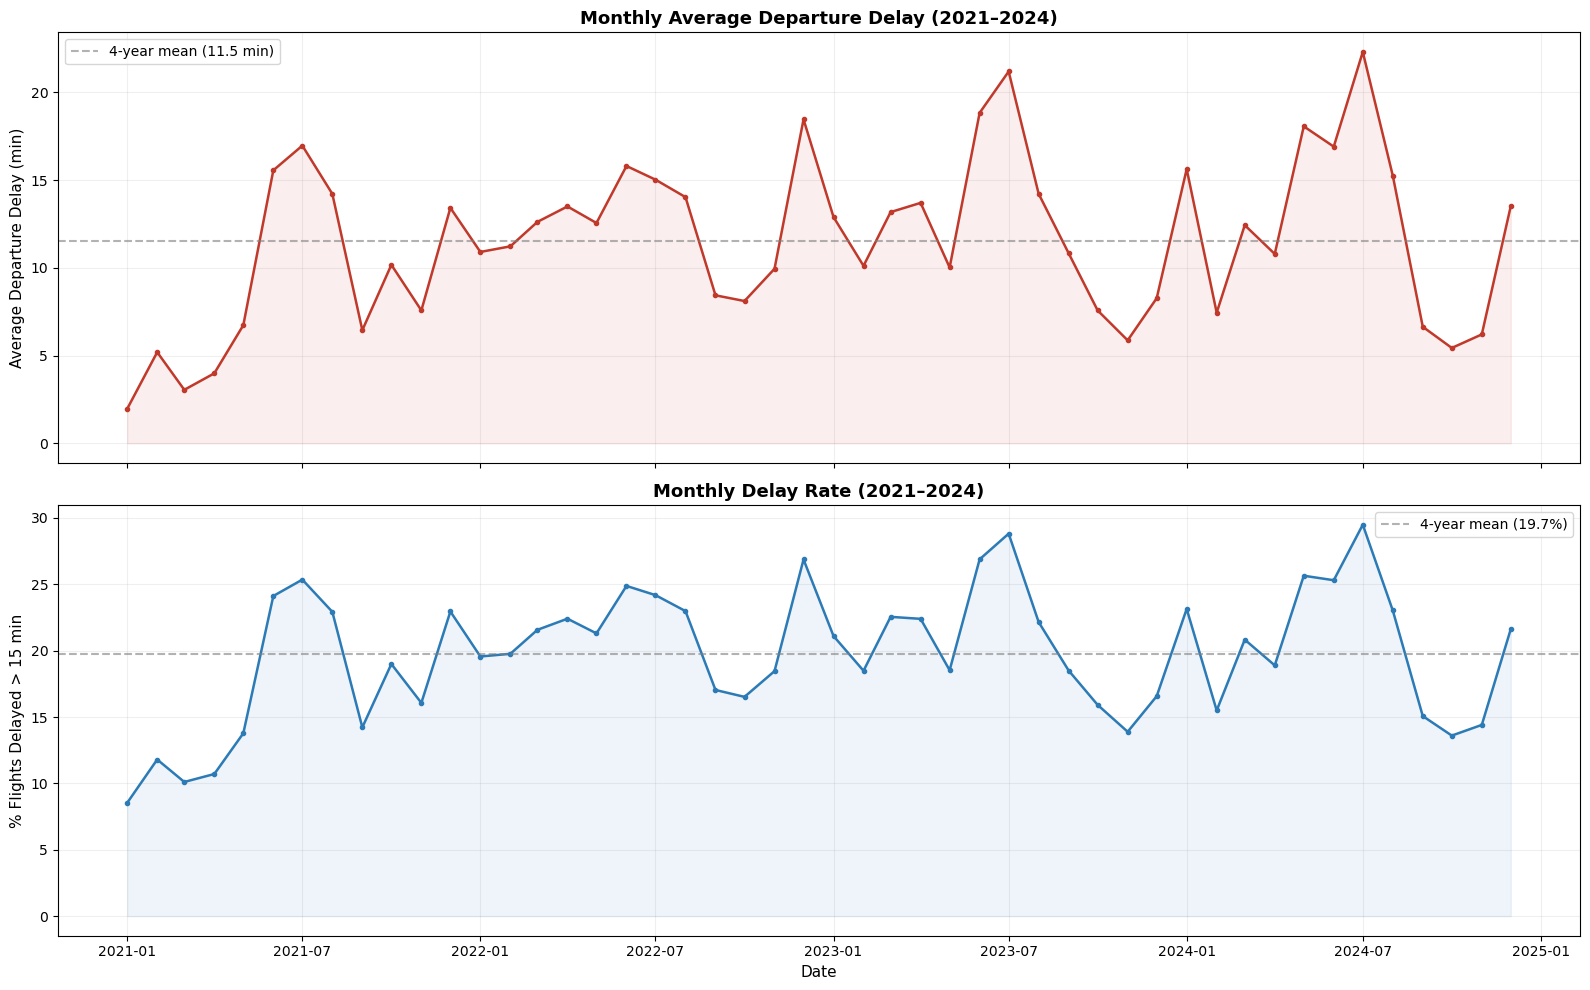

In [104]:
monthly_trend = df_delays.groupby([df_delays['FL_DATE'].dt.to_period('M')]).agg(
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean'),
    flights=('DEP_DELAY', 'count')
)
monthly_trend.index = monthly_trend.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# --- Top: Average delay ---
axes[0].plot(monthly_trend.index, monthly_trend['avg_delay'],
             color='#c0392b', linewidth=1.8, marker='o', markersize=3)
axes[0].fill_between(monthly_trend.index, monthly_trend['avg_delay'],
                     alpha=0.08, color='#c0392b')
mean_delay = monthly_trend['avg_delay'].mean()
axes[0].axhline(y=mean_delay, color='gray', linestyle='--', alpha=0.6,
                label=f'4-year mean ({mean_delay:.1f} min)')
axes[0].set_ylabel('Average Departure Delay (min)', fontsize=11)
axes[0].set_title('Monthly Average Departure Delay (2021–2024)',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.2)
axes[0].set_axisbelow(True)

# --- Bottom: Delay rate ---
axes[1].plot(monthly_trend.index, monthly_trend['delay_rate'] * 100,
             color='#2c7bb6', linewidth=1.8, marker='o', markersize=3)
axes[1].fill_between(monthly_trend.index, monthly_trend['delay_rate'] * 100,
                     alpha=0.08, color='#2c7bb6')
mean_rate = monthly_trend['delay_rate'].mean() * 100
axes[1].axhline(y=mean_rate, color='gray', linestyle='--', alpha=0.6,
                label=f'4-year mean ({mean_rate:.1f}%)')
axes[1].set_ylabel('% Flights Delayed > 15 min', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_title('Monthly Delay Rate (2021–2024)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.2)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

### Q9: Is there a relationship between flight distance and delay likelihood?

We test this with simple linear regression (DEP_DELAY ~ DISTANCE) and examine the correlation. We also bin flights by distance to see if the relationship is nonlinear — for example, very short flights may have higher delays due to ground congestion while very long flights may face different delay profiles.

In [55]:
temp = df_delays[['DISTANCE', 'DEP_DELAY']].dropna()
r, p = stats.pearsonr(temp['DISTANCE'], temp['DEP_DELAY'])
print(f"Pearson correlation (DISTANCE vs DEP_DELAY): r = {r:.4f}, p = {p:.2e}")

mask = df_delays[['DISTANCE', 'DEP_DELAY']].dropna().index
X_dist = df_delays.loc[mask, 'DISTANCE'].values.reshape(-1, 1)
y_delay = df_delays.loc[mask, 'DEP_DELAY'].values

reg = LinearRegression().fit(X_dist, y_delay)
print(f"\nSimple OLS: DEP_DELAY = {reg.coef_[0]:.6f} * DISTANCE + {reg.intercept_:.2f}")
print(f"R² = {reg.score(X_dist, y_delay):.6f}")
print(f"\nFor every additional 100 miles, delay changes by {reg.coef_[0]*100:.3f} minutes")

Pearson correlation (DISTANCE vs DEP_DELAY): r = 0.0223, p = 0.00e+00

Simple OLS: DEP_DELAY = 0.002130 * DISTANCE + 10.03
R² = 0.000493

For every additional 100 miles, delay changes by 0.213 minutes


In [57]:
df_delays['dist_bin'] = pd.cut(df_delays['DISTANCE'], 
                                bins=[0, 250, 500, 750, 1000, 1500, 2000, 3000, 6000],
                                labels=['0-250', '250-500', '500-750', '750-1000', 
                                        '1000-1500', '1500-2000', '2000-3000', '3000+'])

dist_analysis = df_delays.groupby('dist_bin', observed=True).agg(
    flights=('DEP_DELAY', 'count'),
    avg_delay=('DEP_DELAY', 'mean'),
    delay_rate=('DEP_DEL15', 'mean')
).round(3)

print("Delay by distance bin:")
print(dist_analysis.to_string())

Delay by distance bin:
           flights  avg_delay  delay_rate
dist_bin                                 
0-250      3150007      9.426       0.169
250-500    6029611     10.062       0.184
500-750    5167592     11.519       0.195
750-1000   4311005     12.979       0.218
1000-1500  4234211     14.037       0.225
1500-2000  1703539     13.716       0.223
2000-3000  1528500     12.566       0.204
3000+        58433     14.287       0.206


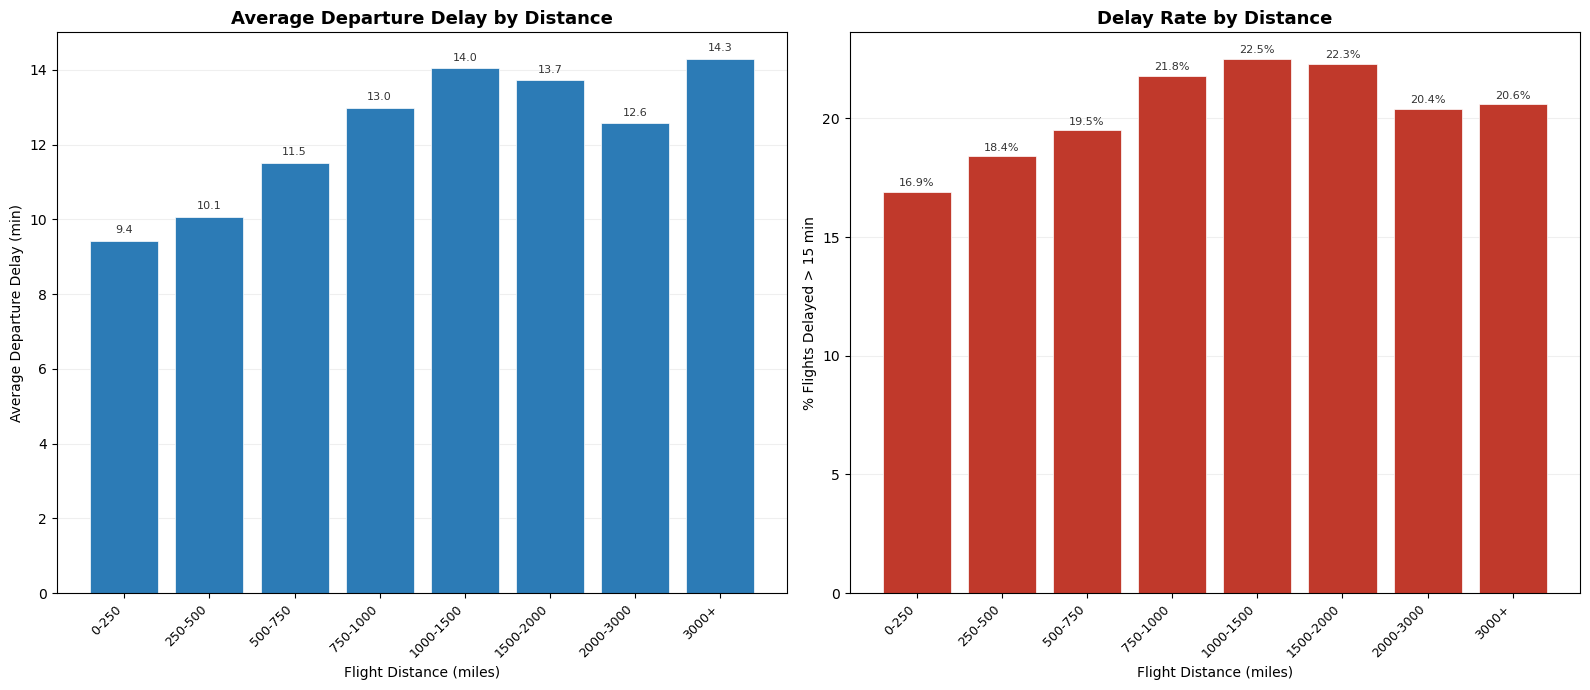

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: Average delay ---
bars = axes[0].bar(range(len(dist_analysis)), dist_analysis['avg_delay'],
                   color='#2c7bb6', edgecolor='white', linewidth=0.5)
axes[0].set_xticks(range(len(dist_analysis)))
axes[0].set_xticklabels(dist_analysis.index, rotation=45, ha='right', fontsize=9)
axes[0].set_xlabel('Flight Distance (miles)', fontsize=10)
axes[0].set_ylabel('Average Departure Delay (min)', fontsize=10)
axes[0].set_title('Average Departure Delay by Distance',
                  fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.2)
axes[0].set_axisbelow(True)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.15,
                 f'{h:.1f}', ha='center', va='bottom', fontsize=8, color='#333')

# --- Right: Delay rate ---
bars2 = axes[1].bar(range(len(dist_analysis)), dist_analysis['delay_rate'] * 100,
                    color='#c0392b', edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(len(dist_analysis)))
axes[1].set_xticklabels(dist_analysis.index, rotation=45, ha='right', fontsize=9)
axes[1].set_xlabel('Flight Distance (miles)', fontsize=10)
axes[1].set_ylabel('% Flights Delayed > 15 min', fontsize=10)
axes[1].set_title('Delay Rate by Distance',
                  fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.2)
axes[1].set_axisbelow(True)
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.15,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=8, color='#333')

plt.tight_layout()
plt.show()

### Correlation Heatmap

We visualize pairwise correlations among all numeric weather, airport, and delay variables to identify multicollinearity and unexpected relationships before building more complex models.

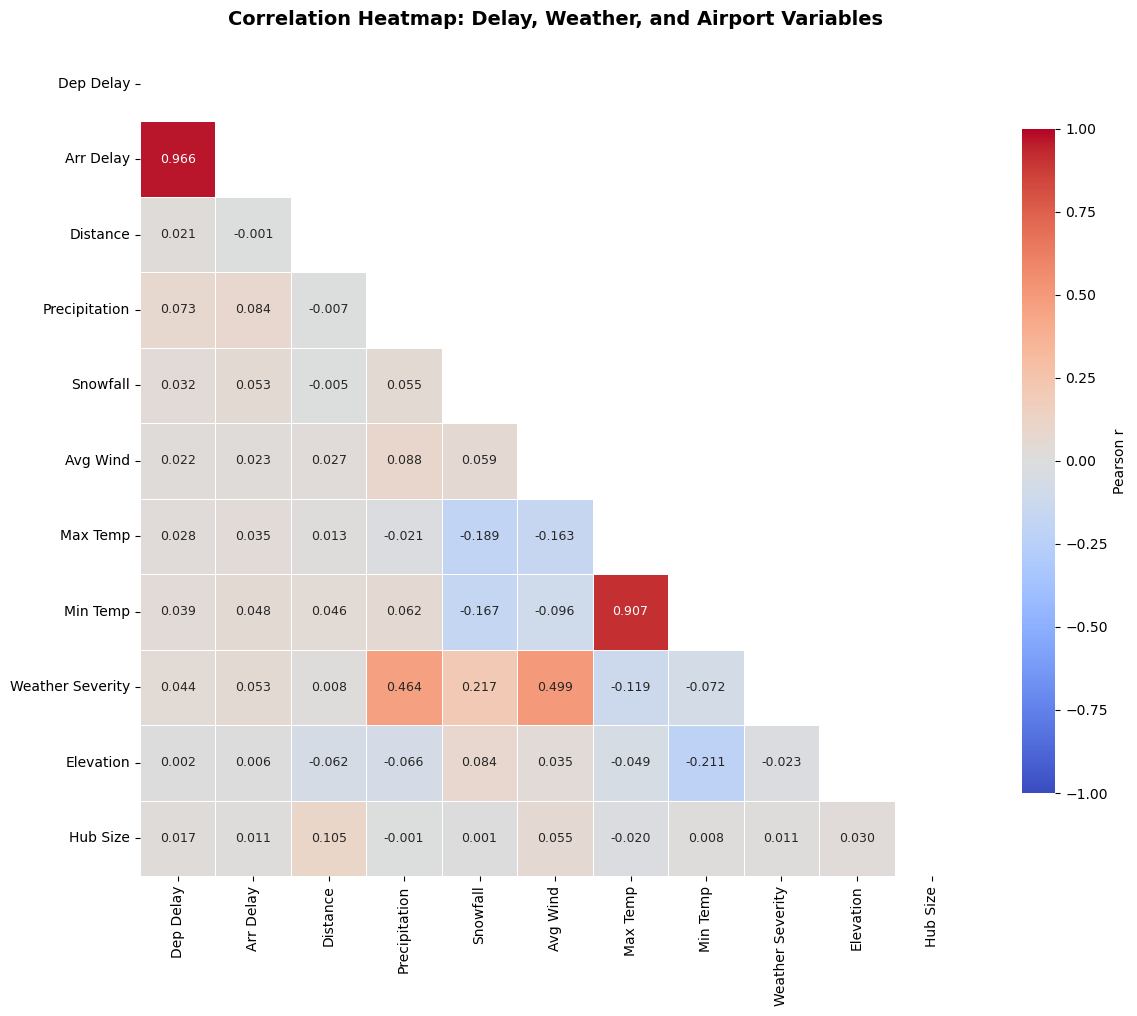

In [108]:
heatmap_cols = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'precipitation', 'snowfall',
                'avg_wind', 'temp_max', 'temp_min', 'weather_severity',
                'elevation_ft', 'hub_ordinal']

# Readable labels
label_map = {
    'DEP_DELAY': 'Dep Delay', 'ARR_DELAY': 'Arr Delay', 'DISTANCE': 'Distance',
    'precipitation': 'Precipitation', 'snowfall': 'Snowfall', 'avg_wind': 'Avg Wind',
    'temp_max': 'Max Temp', 'temp_min': 'Min Temp', 'weather_severity': 'Weather Severity',
    'elevation_ft': 'Elevation', 'hub_ordinal': 'Hub Size'
}

corr_matrix = df_weather[heatmap_cols].corr()
corr_matrix.index = [label_map.get(c, c) for c in corr_matrix.index]
corr_matrix.columns = [label_map.get(c, c) for c in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
            annot_kws={'fontsize': 9}, linewidths=0.5, linecolor='white')
ax.set_title('Correlation Heatmap: Delay, Weather, and Airport Variables',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

### Interactive Airport Delay Map

We plot each of our 75 airports on an interactive U.S. map, color-coded by average departure delay severity. Larger circles indicate higher flight volume. Hovering over an airport shows its name, delay statistics, and hub classification. This is inspired by tools like FlightRadar24 and built using Folium.

In [65]:
# Build airport-level summary
airport_map_data = df_delays[df_delays['hub_size'].notna()].groupby('ORIGIN').agg(
    avg_delay=('DEP_DELAY', 'mean'),
    median_delay=('DEP_DELAY', 'median'),
    delay_rate=('DEP_DEL15', 'mean'),
    flights=('DEP_DELAY', 'count'),
    avg_weather_severity=('weather_severity', 'mean'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first'),
    hub_size=('hub_size', 'first'),
    city=('ORIGIN_CITY_NAME', 'first')
).round(2)

airport_map_data = airport_map_data[airport_map_data['latitude'].notna()]
print(f"Airports to map: {len(airport_map_data)}")
print(f"Delay range: {airport_map_data['avg_delay'].min():.1f} to {airport_map_data['avg_delay'].max():.1f} min")

Airports to map: 75
Delay range: 5.2 to 17.7 min


In [67]:
# Create the map
m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles='CartoDB positron')

# Color scale: green (low delay) -> yellow -> red (high delay)
delay_min = airport_map_data['avg_delay'].min()
delay_max = airport_map_data['avg_delay'].max()

def get_color(delay):
    ratio = (delay - delay_min) / (delay_max - delay_min)
    if ratio < 0.33:
        return '#2ecc71'  # green
    elif ratio < 0.66:
        return '#f39c12'  # orange
    else:
        return '#e74c3c'  # red

for airport, row in airport_map_data.iterrows():
    # Scale radius by flight volume
    radius = max(4, min(20, row['flights'] / 50000))
    
    popup_text = (
        f"<b>{airport}</b> — {row['city']}<br>"
        f"Hub: {row['hub_size']}<br>"
        f"Flights: {row['flights']:,.0f}<br>"
        f"Avg Delay: {row['avg_delay']:.1f} min<br>"
        f"Median Delay: {row['median_delay']:.1f} min<br>"
        f"Delay Rate: {row['delay_rate']*100:.1f}%<br>"
        f"Avg Weather Severity: {row['avg_weather_severity']:.3f}"
    )
    
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=radius,
        color=get_color(row['avg_delay']),
        fill=True,
        fill_color=get_color(row['avg_delay']),
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=250),
        tooltip=f"{airport}: {row['avg_delay']:.1f} min avg delay"
    ).add_to(m)

# Add a simple legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000; 
     background: white; padding: 10px; border: 2px solid gray; border-radius: 5px;">
    <b>Avg Departure Delay</b><br>
    <span style="color: #2ecc71;">&#9679;</span> Low<br>
    <span style="color: #f39c12;">&#9679;</span> Medium<br>
    <span style="color: #e74c3c;">&#9679;</span> High<br>
    <small>Circle size = flight volume</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m

In [69]:
# Also create a heat layer version showing delay density
heat_data = []
for airport, row in airport_map_data.iterrows():
    # Weight by average delay * flight volume (captures both severity and impact)
    weight = row['avg_delay'] * (row['flights'] / airport_map_data['flights'].max())
    heat_data.append([row['latitude'], row['longitude'], weight])

m2 = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles='CartoDB dark_matter')
HeatMap(heat_data, radius=30, blur=20, max_zoom=6).add_to(m2)
m2

### Linear Effects Model

We build a full multivariate OLS regression to estimate how weather, airport characteristics, temporal patterns, and carrier identity each contribute to departure delay. We use statsmodels to get a complete regression table with coefficients, standard errors, t-statistics, p-values, and confidence intervals — the standard output expected in a statistics-focused analysis. We standardize continuous predictors so coefficients are directly comparable as effect sizes.

In [110]:
model_features = ['precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_range',
                  'DISTANCE', 'hub_ordinal', 'elevation_ft']

df_model = df_weather[model_features + ['DEP_DELAY', 'MONTH', 'OP_UNIQUE_CARRIER']].dropna()

# Sample to avoid memory crash — 500K is more than enough for stable estimates
df_model = df_model.sample(n=500_000, random_state=42).copy()
print(f"Modeling sample: {len(df_model):,} flights (sampled from {len(df_weather):,})")

Modeling sample: 500,000 flights (sampled from 22,635,774)


In [112]:
# Encode categorical variables
# Month as dummies (baseline = January)
df_model['MONTH'] = df_model['MONTH'].astype(int)
month_dummies = pd.get_dummies(df_model['MONTH'], prefix='month', drop_first=True, dtype=int)

# Carrier as dummies (baseline = most common carrier)
top_carrier = df_model['OP_UNIQUE_CARRIER'].value_counts().index[0]
carrier_dummies = pd.get_dummies(df_model['OP_UNIQUE_CARRIER'], prefix='carrier', dtype=int)
carrier_dummies = carrier_dummies.drop(columns=[f'carrier_{top_carrier}'])

print(f"Baseline month: January")
print(f"Baseline carrier: {top_carrier}")
print(f"Month dummies: {month_dummies.shape[1]} columns")
print(f"Carrier dummies: {carrier_dummies.shape[1]} columns")

Baseline month: January
Baseline carrier: WN
Month dummies: 11 columns
Carrier dummies: 16 columns


In [114]:
# Standardize continuous features so coefficients are comparable
continuous = model_features.copy()
scaler = StandardScaler()
df_model[continuous] = scaler.fit_transform(df_model[continuous])

# Combine into design matrix
X = pd.concat([df_model[continuous], month_dummies, carrier_dummies], axis=1)
X = sm.add_constant(X)
y = df_model['DEP_DELAY']

print(f"Design matrix: {X.shape}")
print(f"Features: {X.columns.tolist()}")

Design matrix: (500000, 36)
Features: ['const', 'precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_range', 'DISTANCE', 'hub_ordinal', 'elevation_ft', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'carrier_9E', 'carrier_AA', 'carrier_AS', 'carrier_B6', 'carrier_DL', 'carrier_F9', 'carrier_G4', 'carrier_HA', 'carrier_MQ', 'carrier_NK', 'carrier_OH', 'carrier_OO', 'carrier_QX', 'carrier_UA', 'carrier_YV', 'carrier_YX']


In [116]:
# Fit OLS
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              DEP_DELAY   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     265.2
Date:                Thu, 26 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:21:08   Log-Likelihood:            -2.6756e+06
No. Observations:              500000   AIC:                         5.351e+06
Df Residuals:                  499964   BIC:                         5.352e+06
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            12.0921      0.322     37.532

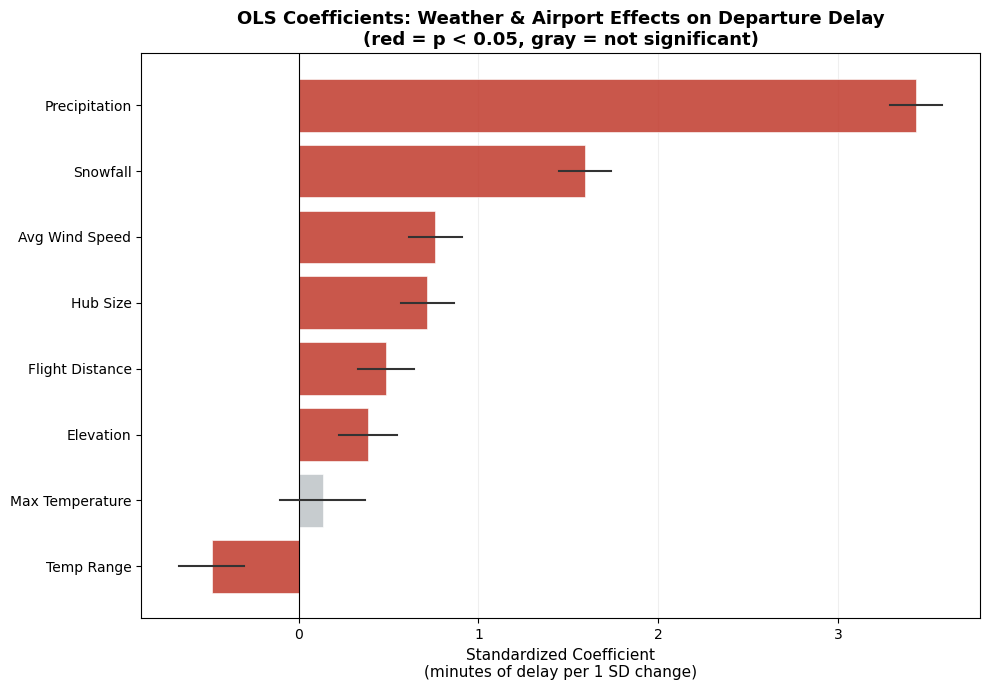

In [118]:
weather_airport_vars = ['precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_range',
                        'DISTANCE', 'hub_ordinal', 'elevation_ft']

# Readable labels
label_map = {
    'precipitation': 'Precipitation', 'snowfall': 'Snowfall', 'avg_wind': 'Avg Wind Speed',
    'temp_max': 'Max Temperature', 'temp_range': 'Temp Range',
    'DISTANCE': 'Flight Distance', 'hub_ordinal': 'Hub Size', 'elevation_ft': 'Elevation'
}

coefs = ols_model.params[weather_airport_vars].sort_values()
ci = ols_model.conf_int().loc[weather_airport_vars]
pvals = ols_model.pvalues[weather_airport_vars]

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#c0392b' if p < 0.05 else '#bdc3c7' for p in pvals[coefs.index]]
y_pos = range(len(coefs))
readable_labels = [label_map.get(v, v) for v in coefs.index]

ax.barh(y_pos, coefs.values, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)

for i, var in enumerate(coefs.index):
    ax.plot([ci.loc[var, 0], ci.loc[var, 1]], [i, i], color='#333', linewidth=1.5, zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(readable_labels, fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized Coefficient\n(minutes of delay per 1 SD change)', fontsize=11)
ax.set_title('OLS Coefficients: Weather & Airport Effects on Departure Delay\n'
             '(red = p < 0.05, gray = not significant)',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [120]:
# Decompose R² — how much variance does each group of variables explain?
# Compare nested models

# Model 1: Weather only
X_weather = sm.add_constant(df_model[['precipitation', 'snowfall', 'avg_wind', 'temp_max', 
                                       'temp_range']])
r2_weather = sm.OLS(y, X_weather).fit().rsquared

# Model 2: Weather + airport
X_wx_airport = sm.add_constant(df_model[['precipitation', 'snowfall', 'avg_wind', 'temp_max', 
                                          'temp_range', 'hub_ordinal', 
                                          'elevation_ft', 'DISTANCE']])
r2_wx_airport = sm.OLS(y, X_wx_airport).fit().rsquared

# Model 3: Weather + airport + time
X_wx_ap_time = pd.concat([df_model[['precipitation', 'snowfall', 'avg_wind', 'temp_max', 
                                     'temp_range', 'hub_ordinal', 
                                     'elevation_ft', 'DISTANCE']], month_dummies], axis=1)
X_wx_ap_time = sm.add_constant(X_wx_ap_time)
r2_wx_ap_time = sm.OLS(y, X_wx_ap_time).fit().rsquared

# Model 4: Full model (weather + airport + time + carrier)
r2_full = ols_model.rsquared

print("=== Variance Decomposition (R²) ===")
print(f"Weather only:                    R² = {r2_weather:.4f} ({r2_weather*100:.2f}%)")
print(f"+ Airport characteristics:       R² = {r2_wx_airport:.4f} (+{(r2_wx_airport - r2_weather)*100:.2f}%)")
print(f"+ Month (seasonality):           R² = {r2_wx_ap_time:.4f} (+{(r2_wx_ap_time - r2_wx_airport)*100:.2f}%)")
print(f"+ Carrier identity:              R² = {r2_full:.4f} (+{(r2_full - r2_wx_ap_time)*100:.2f}%)")
print(f"\nTotal explained variance: {r2_full*100:.2f}%")
print(f"Unexplained (residual): {(1-r2_full)*100:.2f}%")

=== Variance Decomposition (R²) ===
Weather only:                    R² = 0.0080 (0.80%)
+ Airport characteristics:       R² = 0.0088 (+0.08%)
+ Month (seasonality):           R² = 0.0129 (+0.40%)
+ Carrier identity:              R² = 0.0182 (+0.54%)

Total explained variance: 1.82%
Unexplained (residual): 98.18%


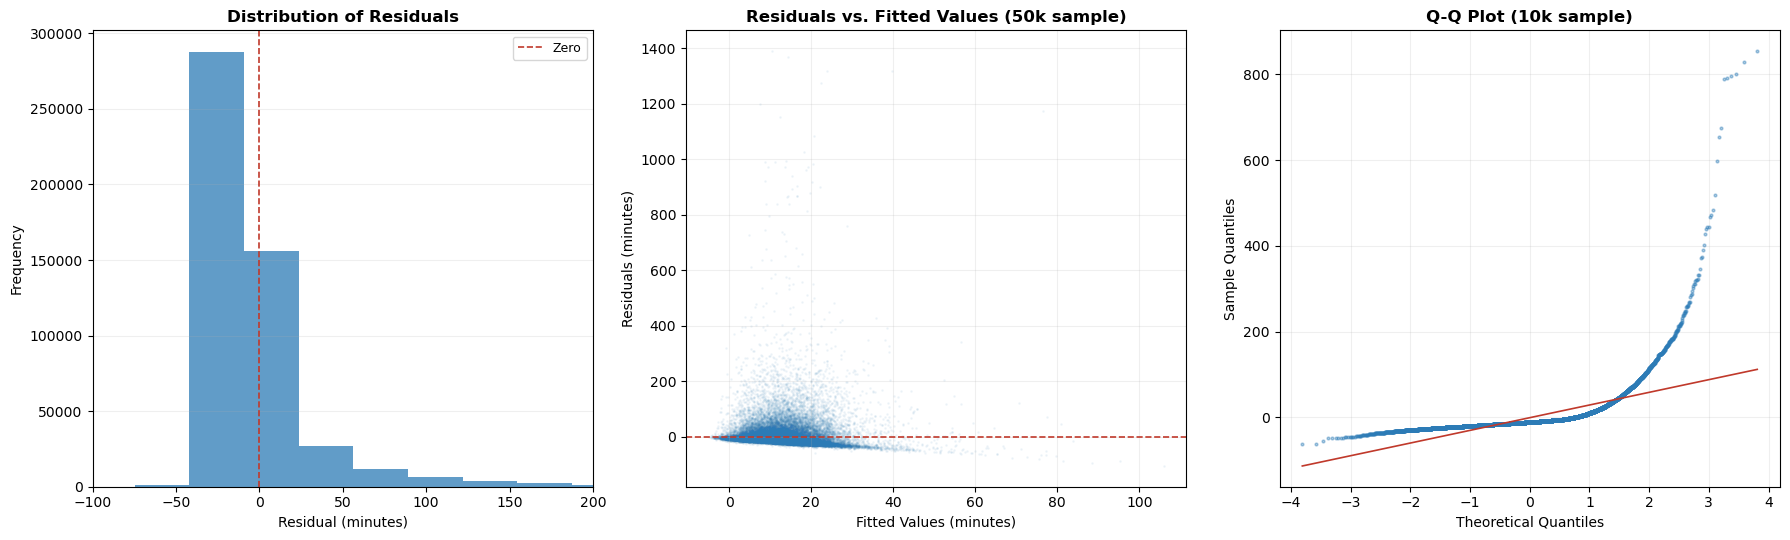

Residual mean: -0.0000
Residual std:  51.03
Skewness:      11.35
Kurtosis:      241.49


In [122]:
residuals = ols_model.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Residual distribution ---
axes[0].hist(residuals, bins=100, edgecolor='none', alpha=0.75, color='#2c7bb6')
axes[0].set_xlabel('Residual (minutes)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='#c0392b', linestyle='--', linewidth=1.2, label='Zero')
axes[0].set_xlim(-100, 200)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.2)

# --- Residuals vs fitted ---
fitted = ols_model.fittedvalues
sample_idx = np.random.choice(len(fitted), size=min(50000, len(fitted)), replace=False)
axes[1].scatter(fitted.iloc[sample_idx], residuals.iloc[sample_idx],
                alpha=0.05, s=1, color='#2c7bb6')
axes[1].axhline(y=0, color='#c0392b', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Fitted Values (minutes)', fontsize=10)
axes[1].set_ylabel('Residuals (minutes)', fontsize=10)
axes[1].set_title('Residuals vs. Fitted Values (50k sample)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.2)

# --- QQ plot ---
stats.probplot(residuals.sample(10000, random_state=42), plot=axes[2])
axes[2].set_title('Q-Q Plot (10k sample)', fontsize=12, fontweight='bold')
axes[2].get_lines()[0].set(markersize=2, alpha=0.4, color='#2c7bb6')
axes[2].get_lines()[1].set(color='#c0392b', linewidth=1.2)
axes[2].set_xlabel('Theoretical Quantiles', fontsize=10)
axes[2].set_ylabel('Sample Quantiles', fontsize=10)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}")
print(f"Residual std:  {residuals.std():.2f}")
print(f"Skewness:      {residuals.skew():.2f}")
print(f"Kurtosis:      {residuals.kurtosis():.2f}")

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import gc
from IPython.display import display, HTML

In [4]:
use_cols = ['FL_DATE', 'OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'ORIGIN_CITY_NAME',
            'DEP_DELAY', 'DEP_DEL15', 'ARR_DELAY', 'CANCELLED', 'DISTANCE',
            'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY',
            'LATE_AIRCRAFT_DELAY', 'MONTH', 'YEAR', 'CRS_DEP_TIME',
            'precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_min',
            'max_wind_gust', 'temp_range', 'weather_severity',
            'hub_size', 'hub_ordinal', 'elevation_ft', 'latitude', 'longitude']

float32_cols = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY',
                'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
                'precipitation', 'snowfall', 'avg_wind', 'temp_max', 'temp_min',
                'max_wind_gust', 'temp_range', 'weather_severity',
                'elevation_ft', 'latitude', 'longitude', 'CRS_DEP_TIME']

total_rows = 26_651_502
chunks = []
loaded = 0

for chunk in pd.read_csv("../../merged_full.csv", usecols=use_cols, low_memory=False, chunksize=500_000):
    for col in float32_cols:
        if col in chunk.columns:
            chunk[col] = pd.to_numeric(chunk[col], errors='coerce').astype('float32')
    for col in ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST']:
        if col in chunk.columns:
            chunk[col] = chunk[col].astype('category')
    
    chunks.append(chunk)
    loaded += len(chunk)
    print(f"\r  Loading: {loaded:,} / {total_rows:,} rows ({min(loaded/total_rows*100, 100):.1f}%)", end="")

print(f"\r  Loading complete. Concatenating...{' ' * 20}")
df_merged = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

df_merged['FL_DATE'] = pd.to_datetime(df_merged['FL_DATE'])
df_delays = df_merged[df_merged['CANCELLED'] == 0].copy()

print(f"Non-cancelled flights: {len(df_delays):,}")
print(f"Memory: {df_delays.memory_usage(deep=True).sum() / 1e9:.2f} GB")

  Loading complete. Concatenating...                    
Non-cancelled flights: 26,182,898
Memory: 10.49 GB


In [6]:
carrier_names = {
    'WN': 'Southwest', 'DL': 'Delta', 'AA': 'American', 'OO': 'SkyWest',
    'UA': 'United', 'YX': 'Republic', 'MQ': 'Envoy', 'B6': 'JetBlue',
    'NK': 'Spirit', 'AS': 'Alaska', '9E': 'Endeavor', 'OH': 'PSA Airlines',
    'F9': 'Frontier', 'G4': 'Allegiant', 'HA': 'Hawaiian', 'YV': 'Mesa',
    'QX': 'Horizon'
}

coord_lookup = df_delays[df_delays['latitude'].notna()].groupby('ORIGIN').agg(
    lat=('latitude', 'first'),
    lon=('longitude', 'first')
).to_dict('index')

city_lookup = df_delays[df_delays['ORIGIN_CITY_NAME'].notna()].groupby('ORIGIN')['ORIGIN_CITY_NAME'].first().to_dict()

print(f"Airports with coordinates: {len(coord_lookup)}")
print(f"Airports with city names: {len(city_lookup)}")

Airports with coordinates: 75
Airports with city names: 376


In [64]:
# Airline brand colors (primary = header bg, accent = secondary highlight)
airline_colors = {
    'DL': ('#003A70', '#C8102E'),    # Delta: Regal Blue, Crimson
    'AA': ('#36495A', '#0078D2'),    # American: Dark Gray-Blue, Sky Blue
    'UA': ('#0033A0', '#005DAA'),    # United: Blue, Lebanese Blue
    'WN': ('#304CB2', '#FFBF27'),    # Southwest: Bold Blue, Gold
    'B6': ('#00205B', '#003876'),    # JetBlue: Dark Navy, Ateneo Blue
    'AS': ('#01426A', '#00AFD7'),    # Alaska: Midnight Blue, Breeze Blue
    'NK': ('#000000', '#FFEC00'),    # Spirit: Black, Yellow
    'F9': ('#0F6744', '#9A9B9C'),    # Frontier: Green, Gray
    'G4': ('#01579B', '#F48120'),    # Allegiant: Blue, Orange
    'HA': ('#4B2D89', '#CE0C88'),    # Hawaiian: Purple, Magenta
}

# Regional carriers → parent airline
regional_to_parent = {
    '9E': 'DL',   # Endeavor → Delta
    'MQ': 'AA',   # Envoy → American
    'OH': 'AA',   # PSA → American
    'YX': 'AA',   # Republic → American
    'OO': 'DL',   # SkyWest → Delta
    'QX': 'AS',   # Horizon → Alaska
}

def great_circle_points(lat1, lon1, lat2, lon2, n_points=40):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    d = np.arccos(np.clip(np.sin(lat1)*np.sin(lat2) +
                          np.cos(lat1)*np.cos(lat2)*np.cos(lon2-lon1), -1, 1))
    if d < 1e-10:
        return [[np.degrees(lat1), np.degrees(lon1)]]
    points = []
    for f in np.linspace(0, 1, n_points):
        A = np.sin((1-f)*d) / np.sin(d)
        B = np.sin(f*d) / np.sin(d)
        x = A*np.cos(lat1)*np.cos(lon1) + B*np.cos(lat2)*np.cos(lon2)
        y = A*np.cos(lat1)*np.sin(lon1) + B*np.cos(lat2)*np.sin(lon2)
        z = A*np.sin(lat1) + B*np.sin(lat2)
        lat = np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2)))
        lon = np.degrees(np.arctan2(y, x))
        points.append([lat, lon])
    return points

def get_time_bin(dep_time):
    try:
        t = int(float(dep_time))
    except:
        return 'Unknown'
    if t < 600: return 'Red-eye'
    elif t < 1200: return 'Morning'
    elif t < 1700: return 'Afternoon'
    elif t < 2100: return 'Evening'
    else: return 'Night'

month_names = {1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',
               7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'}


def flight_lookup(origin='JFK', dest='LAX', carrier='DL', month='All', time_of_day='Any'):
    """
    Usage:  flight_lookup('JFK', 'LAX', 'DL', 6, 'Morning')
            flight_lookup('ORD', 'MIA', 'AA', 'All')
            flight_lookup('BOS', 'SFO', 'UA', 1, 'Evening')

    month: 1-12 or 'All'
    time_of_day: 'Any', 'Red-eye', 'Morning', 'Afternoon', 'Evening', 'Night'
    """

    origin = origin.upper()
    dest = dest.upper()
    carrier = carrier.upper()

    # Map regional carriers to parent airline for branding
    display_carrier = regional_to_parent.get(carrier, carrier)
    primary, accent = airline_colors.get(display_carrier, ('#1a1a2e', '#e74c3c'))
    carrier_name = carrier_names.get(carrier, carrier)
    parent_name = carrier_names.get(display_carrier, display_carrier)
    if carrier != display_carrier:
        carrier_name = f"{carrier_name} ({parent_name})"

    origin_city = city_lookup.get(origin, origin)
    dest_city = city_lookup.get(dest, dest)

    if month == 'All' or month is None:
        m_name = 'All Months'
        month_val = None
    else:
        month_val = int(month)
        m_name = month_names.get(month_val, str(month_val))

    # Filter
    mask = ((df_delays['ORIGIN'] == origin) &
            (df_delays['DEST'] == dest) &
            (df_delays['OP_UNIQUE_CARRIER'] == carrier))

    if month_val is not None:
        mask = mask & (df_delays['MONTH'] == month_val)

    subset = df_delays[mask].copy()

    if time_of_day != 'Any' and 'CRS_DEP_TIME' in subset.columns:
        subset['_time_bin'] = subset['CRS_DEP_TIME'].apply(get_time_bin)
        subset = subset[subset['_time_bin'] == time_of_day]

    if len(subset) == 0:
        available = ', '.join(sorted(df_delays[(df_delays['ORIGIN']==origin) &
                                                (df_delays['DEST']==dest)]['OP_UNIQUE_CARRIER'].unique().tolist()))
        display(HTML(
            f"<div style='padding: 20px; background: {primary}; border-radius: 10px; "
            f"font-family: Arial; color: white; max-width: 750px;'>"
            f"<div style='font-size: 20px; font-weight: bold; margin-bottom: 10px;'>"
            f"✈ {origin} → {dest}</div>"
            f"<div style='font-size: 14px;'>{carrier_name} does not operate this route "
            f"in our 2021–2024 dataset.</div>"
            f"<div style='margin-top: 10px; font-size: 13px; color: rgba(255,255,255,0.7);'>"
            f"Available carriers: {available if available else 'None — route may not exist'}</div>"
            f"</div>"))
        return

    # Stats
    n_flights = len(subset)
    avg_delay = float(subset['DEP_DELAY'].mean())
    median_delay = float(subset['DEP_DELAY'].median())
    std_delay = float(subset['DEP_DELAY'].std())
    pct_ontime = float((subset['DEP_DELAY'] <= 0).mean() * 100)
    pct_minor = float(((subset['DEP_DELAY'] > 0) & (subset['DEP_DELAY'] <= 15)).mean() * 100)
    pct_delayed = float((subset['DEP_DEL15'] == 1).mean() * 100)
    pct_major = float((subset['DEP_DELAY'] > 60).mean() * 100)
    avg_distance = float(subset['DISTANCE'].mean())
    p25 = float(subset['DEP_DELAY'].quantile(0.25))
    p75 = float(subset['DEP_DELAY'].quantile(0.75))
    p90 = float(subset['DEP_DELAY'].quantile(0.90))
    p95 = float(subset['DEP_DELAY'].quantile(0.95))

    has_weather = subset['precipitation'].notna().any()
    if has_weather:
        wx = subset[subset['precipitation'].notna()]
        avg_precip = float(wx['precipitation'].mean())
        avg_snow = float(wx['snowfall'].mean())
        avg_wind_val = float(wx['avg_wind'].mean())

    if pct_delayed < 15:
        risk_color = '#27ae60'; risk_label = 'LOW RISK'
    elif pct_delayed < 25:
        risk_color = '#f39c12'; risk_label = 'MODERATE RISK'
    else:
        risk_color = '#c0392b'; risk_label = 'HIGH RISK'

    stats_html = f"""
    <div style="font-family: Arial; max-width: 750px; margin: 10px 0;">
        <div style="background: linear-gradient(135deg, {primary} 0%, {primary}dd 100%);
             color: white; padding: 20px 25px; border-radius: 10px 10px 0 0; position: relative;">
            <div style="position: absolute; top: 12px; right: 20px; font-size: 34px;
                 font-weight: bold; color: {accent}; opacity: 0.5;">{display_carrier}</div>
            <div style="font-size: 11px; color: rgba(255,255,255,0.5); text-transform: uppercase;
                 letter-spacing: 1.5px;">{carrier_name} — Flight Delay Analysis</div>
            <div style="font-size: 26px; font-weight: bold; margin: 8px 0;
                 text-shadow: 0 1px 3px rgba(0,0,0,0.3);">
                ✈ {origin} → {dest}</div>
            <div style="font-size: 14px; color: rgba(255,255,255,0.8);">
                {origin_city} → {dest_city}</div>
            <div style="font-size: 12px; color: rgba(255,255,255,0.5); margin-top: 6px;">
                {m_name} &bull; {time_of_day} &bull; {avg_distance:,.0f} miles</div>
        </div>

        <div style="background: {risk_color}; color: white; padding: 12px 25px;
             font-weight: bold; font-size: 14px; letter-spacing: 0.5px;
             display: flex; justify-content: space-between; align-items: center;">
            <span>{risk_label} — {pct_delayed:.1f}% of flights delayed &gt; 15 min</span>
            <span style="font-weight: normal; font-size: 12px;">
                Based on {n_flights:,} flights (2021–2024)</span>
        </div>

        <div style="background: white; padding: 20px 25px; border: 1px solid #e0e0e0;">
            <div style="display: grid; grid-template-columns: 1fr 1fr 1fr 1fr; gap: 12px;
                 text-align: center; margin-bottom: 20px;">
                <div style="background: #f0faf0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #27ae60;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;
                         letter-spacing: 0.5px;">On Time / Early</div>
                    <div style="font-size: 26px; font-weight: bold; color: #27ae60;
                         margin-top: 4px;">{pct_ontime:.0f}%</div>
                </div>
                <div style="background: #fffaf0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #f39c12;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;
                         letter-spacing: 0.5px;">Minor (1–15m)</div>
                    <div style="font-size: 26px; font-weight: bold; color: #f39c12;
                         margin-top: 4px;">{pct_minor:.0f}%</div>
                </div>
                <div style="background: #fff5f0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #e67e22;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;
                         letter-spacing: 0.5px;">Significant (15m+)</div>
                    <div style="font-size: 26px; font-weight: bold; color: #e67e22;
                         margin-top: 4px;">{pct_delayed:.0f}%</div>
                </div>
                <div style="background: #fff0f0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #c0392b;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;
                         letter-spacing: 0.5px;">Major (60m+)</div>
                    <div style="font-size: 26px; font-weight: bold; color: #c0392b;
                         margin-top: 4px;">{pct_major:.1f}%</div>
                </div>
            </div>

            <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
                <div>
                    <div style="font-weight: bold; font-size: 13px; margin-bottom: 8px;
                         color: {primary}; border-bottom: 2px solid {accent}; padding-bottom: 5px;">
                        Delay Statistics</div>
                    <table style="font-size: 12px; width: 100%; border-collapse: collapse;">
                        <tr><td style="padding: 5px 0; color: #666;">Average delay</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{avg_delay:+.1f} min</td></tr>
                        <tr><td style="padding: 5px 0; color: #666;">Median delay</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{median_delay:+.1f} min</td></tr>
                        <tr><td style="padding: 5px 0; color: #666;">Std deviation</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{std_delay:.1f} min</td></tr>
                        <tr><td style="padding: 5px 0; color: #666;">25th percentile</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{p25:+.0f} min</td></tr>
                        <tr><td style="padding: 5px 0; color: #666;">75th percentile</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{p75:+.0f} min</td></tr>
                        <tr style="background: #fff8f0;">
                            <td style="padding: 5px 0; color: #888;">90th pctl (worst 10%)</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right; color: #e67e22;">{p90:+.0f} min</td></tr>
                        <tr style="background: #fff0f0;">
                            <td style="padding: 5px 0; color: #888;">95th pctl (worst 5%)</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right; color: #c0392b;">{p95:+.0f} min</td></tr>
                    </table>
                </div>
    """

    if has_weather:
        stats_html += f"""
                <div>
                    <div style="font-weight: bold; font-size: 13px; margin-bottom: 8px;
                         color: {primary}; border-bottom: 2px solid {accent}; padding-bottom: 5px;">
                        Typical {m_name} Weather at {origin}</div>
                    <table style="font-size: 12px; width: 100%; border-collapse: collapse;">
                        <tr><td style="padding: 5px 0; color: #666;">Avg precipitation</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{avg_precip:.2f} in</td></tr>
                        <tr><td style="padding: 5px 0; color: #666;">Avg snowfall</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{avg_snow:.2f} in</td></tr>
                        <tr><td style="padding: 5px 0; color: #666;">Avg wind speed</td>
                            <td style="padding: 5px 0; font-weight: bold; text-align: right;">{avg_wind_val:.1f} mph</td></tr>
                    </table>
                </div>
        """
    else:
        stats_html += "<div></div>"

    stats_html += f"""
            </div>
        </div>
        <div style="background: {primary}15; padding: 10px 25px; border: 1px solid #e0e0e0;
             border-top: none; border-radius: 0 0 10px 10px; font-size: 11px; color: #999;">
            Historical data from BTS On-Time Performance (2021–2024).
            Negative delay = departed early. Weather from NOAA CDO API.
        </div>
    </div>
    """

    display(HTML(stats_html))

    # --- Map ---
    if origin in coord_lookup and dest in coord_lookup:
        o = coord_lookup[origin]
        d = coord_lookup[dest]
        center_lat = (o['lat'] + d['lat']) / 2
        center_lon = (o['lon'] + d['lon']) / 2

        fm = folium.Map(location=[center_lat, center_lon], zoom_start=4,
                       tiles='CartoDB positron')
        arc = great_circle_points(o['lat'], o['lon'], d['lat'], d['lon'])

        # Route color based on delay vs network average (~11.8 min)
        network_avg = 11.8
        if avg_delay <= 0:
            route_color = '#27ae60'; route_label = 'Better than average'
        elif avg_delay <= network_avg:
            route_color = '#2c7bb6'; route_label = 'Below network average'
        elif avg_delay <= network_avg * 1.5:
            route_color = '#f39c12'; route_label = 'Above network average'
        else:
            route_color = '#c0392b'; route_label = 'Well above network average'

        folium.PolyLine(locations=arc, color=route_color, weight=5, opacity=0.85,
                        tooltip=f"{origin} → {dest} | {avg_delay:+.1f} min avg delay | {route_label}"
        ).add_to(fm)

        folium.Marker(
            location=[o['lat'], o['lon']],
            tooltip=f"<b>{origin}</b> — {origin_city} (Origin)",
            icon=folium.DivIcon(
                html=f'<div style="font-size: 22px; color: {primary}; '
                     f'text-shadow: 1px 1px 2px white, -1px -1px 2px white;">✈</div>',
                icon_size=(24, 24), icon_anchor=(12, 12))
        ).add_to(fm)

        folium.Marker(
            location=[d['lat'], d['lon']],
            tooltip=f"<b>{dest}</b> — {dest_city} (Destination)",
            icon=folium.DivIcon(
                html=f'<div style="font-size: 22px; color: {primary}; '
                     f'text-shadow: 1px 1px 2px white, -1px -1px 2px white;">✈</div>',
                icon_size=(24, 24), icon_anchor=(12, 12))
        ).add_to(fm)

        mid_idx = len(arc) // 2
        folium.Marker(
            location=arc[mid_idx],
            icon=folium.DivIcon(
                html=(f'<div style="font-size: 11px; font-weight: bold; color: white; '
                      f'background: {route_color}; padding: 4px 10px; border-radius: 4px; '
                      f'white-space: nowrap; text-align: center; '
                      f'box-shadow: 0 2px 6px rgba(0,0,0,0.3);">'
                      f'{avg_distance:,.0f} mi &bull; {avg_delay:+.1f} min avg<br>'
                      f'<span style="font-size: 9px; opacity: 0.8;">{route_label}</span></div>'),
                icon_size=(170, 38), icon_anchor=(85, 19))
        ).add_to(fm)

        legend_html = """
        <div style="position: fixed; bottom: 15px; right: 15px; z-index: 1000;
             background: white; padding: 10px 14px; border: 1px solid #ccc;
             border-radius: 5px; font-size: 11px; font-family: Arial; color: #555;">
            <div style="font-weight: bold; margin-bottom: 5px;">Route Delay Severity</div>
            <div><span style="color: #27ae60;">━━</span> Early / on-time</div>
            <div><span style="color: #2c7bb6;">━━</span> Below avg (11.8 min)</div>
            <div><span style="color: #f39c12;">━━</span> Above average</div>
            <div><span style="color: #c0392b;">━━</span> Well above average</div>
        </div>
        """
        fm.get_root().html.add_child(folium.Element(legend_html))

        display(fm)

    # --- Histogram ---
    fig, ax = plt.subplots(figsize=(12, 3.5))
    delays = subset['DEP_DELAY'].dropna()
    delays_clipped = delays.clip(-30, 120)
    bins_arr = np.arange(-30, 125, 5)
    n_vals, bin_edges, patches = ax.hist(delays_clipped, bins=bins_arr, edgecolor='none', alpha=0.85)

    for patch, left_edge in zip(patches, bin_edges[:-1]):
        if left_edge < 0:
            patch.set_facecolor('#27ae60')
        elif left_edge < 15:
            patch.set_facecolor('#f39c12')
        else:
            patch.set_facecolor('#c0392b')

    ax.axvline(x=0, color='black', linewidth=1, linestyle='-', alpha=0.3)
    ax.axvline(x=15, color='#c0392b', linewidth=1, linestyle='--', alpha=0.5, label='15 min threshold')
    ax.axvline(x=avg_delay, color=primary, linewidth=2.5, linestyle='-', label=f'Mean ({avg_delay:+.1f} min)')
    ax.axvline(x=median_delay, color=accent, linewidth=2.5, linestyle='--', label=f'Median ({median_delay:+.1f} min)')

    ax.set_xlabel('Departure Delay (minutes)', fontsize=10)
    ax.set_ylabel('Number of Flights', fontsize=10)
    ax.set_title(f'{carrier_name}: {origin} → {dest} Delay Distribution — {m_name}',
                fontsize=12, fontweight='bold', color=primary)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.2)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    # Available carriers hint
    available = sorted(df_delays[(df_delays['ORIGIN']==origin) &
                                  (df_delays['DEST']==dest)]['OP_UNIQUE_CARRIER'].unique().tolist())
    print(f"Other carriers on {origin} → {dest}: {', '.join(c for c in available if c != carrier)}")


print("✈ Flight Delay Lookup Tool")
print("=" * 50)
print("Usage:  flight_lookup('JFK', 'LAX', 'DL', 6, 'Morning')")
print("        flight_lookup('ORD', 'MIA', 'AA', 'All')")
print("        flight_lookup('BOS', 'SFO', 'UA', 1, 'Evening')")
print(f"\nAirlines: {', '.join(f'{k}={v}' for k,v in sorted(carrier_names.items()))}")
print("Months: 1-12 or 'All'")
print("Times: 'Any', 'Red-eye', 'Morning', 'Afternoon', 'Evening', 'Night'")

✈ Flight Delay Lookup Tool
Usage:  flight_lookup('JFK', 'LAX', 'DL', 6, 'Morning')
        flight_lookup('ORD', 'MIA', 'AA', 'All')
        flight_lookup('BOS', 'SFO', 'UA', 1, 'Evening')

Airlines: 9E=Endeavor, AA=American, AS=Alaska, B6=JetBlue, DL=Delta, F9=Frontier, G4=Allegiant, HA=Hawaiian, MQ=Envoy, NK=Spirit, OH=PSA Airlines, OO=SkyWest, QX=Horizon, UA=United, WN=Southwest, YV=Mesa, YX=Republic
Months: 1-12 or 'All'
Times: 'Any', 'Red-eye', 'Morning', 'Afternoon', 'Evening', 'Night'


Average delay,+23.2 min
Median delay,+0.0 min
Std deviation,74.7 min
25th percentile,-2 min
75th percentile,+17 min
90th pctl (worst 10%),+62 min
95th pctl (worst 5%),+136 min
Avg precipitation,0.08 in
Avg snowfall,0.00 in
Avg wind speed,10.4 mph


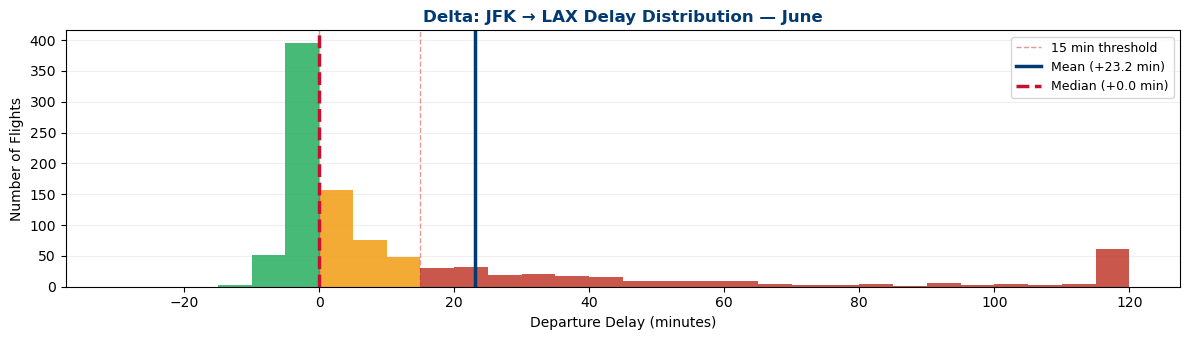

Other carriers on JFK → LAX: AA, AS, B6, UA


In [66]:
flight_lookup('JFK', 'LAX', 'DL', 6)

In [40]:
def airline_report(carrier='DL'):
    """
    Full airline performance dashboard.
    Usage: airline_report('DL'), airline_report('AA'), airline_report('WN')
    """
    carrier = carrier.upper()
    display_carrier = regional_to_parent.get(carrier, carrier)
    primary, accent = airline_colors.get(display_carrier, ('#1a1a2e', '#e74c3c'))
    carrier_name = carrier_names.get(carrier, carrier)
    parent_name = carrier_names.get(display_carrier, display_carrier)
    if carrier != display_carrier:
        carrier_name = f"{carrier_name} ({parent_name})"

    subset = df_delays[df_delays['OP_UNIQUE_CARRIER'] == carrier].copy()

    if len(subset) == 0:
        display(HTML(f"<div style='padding: 20px; background: #fff3cd; border-radius: 8px; "
                     f"font-family: Arial;'><b>No flights found for carrier code '{carrier}'</b></div>"))
        return

    # --- Overall stats ---
    n_flights = len(subset)
    avg_delay = float(subset['DEP_DELAY'].mean())
    median_delay = float(subset['DEP_DELAY'].median())
    pct_ontime = float((subset['DEP_DELAY'] <= 0).mean() * 100)
    pct_delayed = float((subset['DEP_DEL15'] == 1).mean() * 100)
    pct_major = float((subset['DEP_DELAY'] > 60).mean() * 100)
    avg_distance = float(subset['DISTANCE'].mean())

    # --- Rank among all carriers ---
    all_carrier_stats = df_delays.groupby('OP_UNIQUE_CARRIER').agg(
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    ).sort_values('avg_delay')
    n_carriers = len(all_carrier_stats)
    delay_rank = int((all_carrier_stats.index.get_loc(carrier)) + 1)

    # --- Best/worst airports ---
    airport_perf = subset.groupby('ORIGIN').agg(
        flights=('DEP_DELAY', 'count'),
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    )
    airport_perf = airport_perf[airport_perf['flights'] >= 500]
    worst_airports = airport_perf.sort_values('avg_delay', ascending=False).head(10)
    best_airports = airport_perf.sort_values('avg_delay', ascending=True).head(10)

    # --- Monthly performance ---
    monthly = subset.groupby('MONTH').agg(
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    ).round(2)

    # --- Yearly trend ---
    yearly = subset.groupby('YEAR').agg(
        flights=('DEP_DELAY', 'count'),
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    ).round(3)

    # --- Worst routes ---
    subset_routes = subset.copy()
    subset_routes['ROUTE'] = subset_routes['ORIGIN'] + ' → ' + subset_routes['DEST']
    route_perf = subset_routes.groupby('ROUTE').agg(
        flights=('DEP_DELAY', 'count'),
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    )
    route_perf = route_perf[route_perf['flights'] >= 200]
    worst_routes = route_perf.sort_values('avg_delay', ascending=False).head(10)
    best_routes = route_perf.sort_values('avg_delay', ascending=True).head(10)

    # --- Header card ---
    if delay_rank <= n_carriers * 0.33:
        rank_color = '#27ae60'; rank_label = 'Top tier'
    elif delay_rank <= n_carriers * 0.66:
        rank_color = '#f39c12'; rank_label = 'Mid tier'
    else:
        rank_color = '#c0392b'; rank_label = 'Bottom tier'

    header_html = f"""
    <div style="font-family: Arial; max-width: 850px; margin: 10px 0;">
        <div style="background: linear-gradient(135deg, {primary} 0%, {primary}dd 100%);
             color: white; padding: 25px 30px; border-radius: 10px 10px 0 0; position: relative;">
            <div style="position: absolute; top: 15px; right: 25px; font-size: 40px;
                 font-weight: bold; color: {accent}; opacity: 0.4;">{display_carrier}</div>
            <div style="font-size: 11px; color: rgba(255,255,255,0.5); text-transform: uppercase;
                 letter-spacing: 1.5px;">Airline Performance Report Card</div>
            <div style="font-size: 28px; font-weight: bold; margin: 8px 0;">
                {carrier_name}</div>
            <div style="font-size: 13px; color: rgba(255,255,255,0.6); margin-top: 5px;">
                {n_flights:,} flights &bull; 2021–2024 &bull; Avg distance {avg_distance:,.0f} mi</div>
        </div>

        <div style="background: {rank_color}; color: white; padding: 12px 30px;
             font-weight: bold; font-size: 14px;
             display: flex; justify-content: space-between; align-items: center;">
            <span>Ranked #{delay_rank} of {n_carriers} carriers by avg delay ({rank_label})</span>
            <span style="font-weight: normal; font-size: 12px;">
                Avg delay: {avg_delay:+.1f} min &bull; On-time: {pct_ontime:.0f}%</span>
        </div>

        <div style="background: white; padding: 20px 30px; border: 1px solid #e0e0e0;">
            <div style="display: grid; grid-template-columns: 1fr 1fr 1fr 1fr; gap: 12px;
                 text-align: center; margin-bottom: 20px;">
                <div style="background: #f0faf0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #27ae60;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">On Time</div>
                    <div style="font-size: 26px; font-weight: bold; color: #27ae60; margin-top: 4px;">
                        {pct_ontime:.0f}%</div>
                </div>
                <div style="background: #f8f8ff; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid {primary};">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">Avg Delay</div>
                    <div style="font-size: 26px; font-weight: bold; color: {primary}; margin-top: 4px;">
                        {avg_delay:+.1f}m</div>
                </div>
                <div style="background: #fff5f0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #e67e22;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">Delayed 15m+</div>
                    <div style="font-size: 26px; font-weight: bold; color: #e67e22; margin-top: 4px;">
                        {pct_delayed:.0f}%</div>
                </div>
                <div style="background: #fff0f0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #c0392b;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">Major 60m+</div>
                    <div style="font-size: 26px; font-weight: bold; color: #c0392b; margin-top: 4px;">
                        {pct_major:.1f}%</div>
                </div>
            </div>
        </div>
    </div>
    """
    display(HTML(header_html))

    # --- Plots ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Monthly delay
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    colors_season = {'Winter': '#3498db', 'Spring': '#2ecc71', 'Summer': '#e74c3c', 'Fall': '#f39c12'}
    season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
                  6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'}
    m_colors = [colors_season[season_map[m]] for m in monthly.index]

    axes[0,0].bar(monthly.index, monthly['avg_delay'], color=m_colors, edgecolor='white', linewidth=0.5)
    axes[0,0].set_xticks(range(1,13))
    axes[0,0].set_xticklabels(month_labels, fontsize=9)
    axes[0,0].set_ylabel('Avg Departure Delay (min)', fontsize=10)
    axes[0,0].set_title(f'{carrier_name}: Monthly Avg Delay', fontsize=12, fontweight='bold', color=primary)
    axes[0,0].axhline(y=11.8, color='gray', linestyle='--', alpha=0.5, label='Network avg (11.8)')
    axes[0,0].legend(fontsize=8)
    axes[0,0].grid(axis='y', alpha=0.2)
    axes[0,0].set_axisbelow(True)
    best_month = monthly['avg_delay'].idxmin()
    worst_month = monthly['avg_delay'].idxmax()
    for i, (m, val) in enumerate(monthly['avg_delay'].items()):
        axes[0,0].text(m, val + 0.3, f'{val:.1f}', ha='center', fontsize=7, color='#333')

    # 2. Yearly trend
    axes[0,1].plot(yearly.index, yearly['avg_delay'], marker='o', color=primary, linewidth=2, markersize=8)
    axes[0,1].fill_between(yearly.index, yearly['avg_delay'], alpha=0.1, color=primary)
    axes[0,1].set_ylabel('Avg Departure Delay (min)', fontsize=10)
    axes[0,1].set_title(f'{carrier_name}: Yearly Trend', fontsize=12, fontweight='bold', color=primary)
    axes[0,1].set_xticks(yearly.index)
    axes[0,1].set_xticklabels([str(int(y)) for y in yearly.index])
    axes[0,1].grid(alpha=0.2)
    axes[0,1].set_axisbelow(True)
    for yr, row in yearly.iterrows():
        axes[0,1].annotate(f'{row["avg_delay"]:.1f}m\n{row["flights"]:,.0f} flights',
                           (yr, row['avg_delay']), textcoords='offset points',
                           xytext=(0, 12), ha='center', fontsize=8, color='#333')

    # 3. Worst 10 airports
    w_airports = worst_airports.head(10)
    bars = axes[1,0].barh(range(len(w_airports)), w_airports['avg_delay'].values[::-1],
                          color='#c0392b', edgecolor='white', linewidth=0.5, alpha=0.85)
    axes[1,0].set_yticks(range(len(w_airports)))
    axes[1,0].set_yticklabels(w_airports.index[::-1], fontsize=9)
    axes[1,0].set_xlabel('Avg Departure Delay (min)', fontsize=10)
    axes[1,0].set_title(f'{carrier_name}: 10 Worst Airports', fontsize=12, fontweight='bold', color=primary)
    axes[1,0].axvline(x=avg_delay, color=primary, linestyle='--', label=f'Carrier avg ({avg_delay:.1f})')
    axes[1,0].legend(fontsize=8)
    axes[1,0].grid(axis='x', alpha=0.2)
    axes[1,0].set_axisbelow(True)
    for bar in bars:
        w = bar.get_width()
        axes[1,0].text(w + 0.2, bar.get_y() + bar.get_height()/2,
                       f'{w:.1f}', va='center', fontsize=8, color='#333')

    # 4. Best 10 airports
    b_airports = best_airports.head(10)
    bars2 = axes[1,1].barh(range(len(b_airports)), b_airports['avg_delay'].values[::-1],
                           color='#27ae60', edgecolor='white', linewidth=0.5, alpha=0.85)
    axes[1,1].set_yticks(range(len(b_airports)))
    axes[1,1].set_yticklabels(b_airports.index[::-1], fontsize=9)
    axes[1,1].set_xlabel('Avg Departure Delay (min)', fontsize=10)
    axes[1,1].set_title(f'{carrier_name}: 10 Best Airports', fontsize=12, fontweight='bold', color=primary)
    axes[1,1].axvline(x=avg_delay, color=primary, linestyle='--', label=f'Carrier avg ({avg_delay:.1f})')
    axes[1,1].legend(fontsize=8)
    axes[1,1].grid(axis='x', alpha=0.2)
    axes[1,1].set_axisbelow(True)
    for bar in bars2:
        w = bar.get_width()
        axes[1,1].text(w + 0.2, bar.get_y() + bar.get_height()/2,
                       f'{w:.1f}', va='center', fontsize=8, color='#333')

    plt.tight_layout()
    plt.show()

    # --- Worst/best routes table ---
    routes_html = f"""
    <div style="font-family: Arial; max-width: 850px; margin: 10px 0;
         display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
        <div>
            <div style="font-weight: bold; font-size: 13px; color: #c0392b;
                 border-bottom: 2px solid #c0392b; padding-bottom: 5px; margin-bottom: 8px;">
                10 Worst Routes (min 200 flights)</div>
            <table style="font-size: 12px; width: 100%; border-collapse: collapse;">
                <tr style="background: #f5f5f5; font-weight: bold;">
                    <td style="padding: 4px 8px;">Route</td>
                    <td style="padding: 4px 8px; text-align: right;">Avg Delay</td>
                    <td style="padding: 4px 8px; text-align: right;">Rate</td>
                    <td style="padding: 4px 8px; text-align: right;">Flights</td></tr>
    """
    for route, row in worst_routes.iterrows():
        routes_html += (f"<tr><td style='padding: 3px 8px;'>{route}</td>"
                       f"<td style='padding: 3px 8px; text-align: right; font-weight: bold; color: #c0392b;'>"
                       f"{row['avg_delay']:.1f}m</td>"
                       f"<td style='padding: 3px 8px; text-align: right;'>{row['delay_rate']*100:.0f}%</td>"
                       f"<td style='padding: 3px 8px; text-align: right; color: #888;'>{int(row['flights']):,}</td></tr>")

    routes_html += """</table></div><div>
        <div style="font-weight: bold; font-size: 13px; color: #27ae60;
             border-bottom: 2px solid #27ae60; padding-bottom: 5px; margin-bottom: 8px;">
            10 Best Routes (min 200 flights)</div>
        <table style="font-size: 12px; width: 100%; border-collapse: collapse;">
            <tr style="background: #f5f5f5; font-weight: bold;">
                <td style="padding: 4px 8px;">Route</td>
                <td style="padding: 4px 8px; text-align: right;">Avg Delay</td>
                <td style="padding: 4px 8px; text-align: right;">Rate</td>
                <td style="padding: 4px 8px; text-align: right;">Flights</td></tr>
    """
    for route, row in best_routes.iterrows():
        routes_html += (f"<tr><td style='padding: 3px 8px;'>{route}</td>"
                       f"<td style='padding: 3px 8px; text-align: right; font-weight: bold; color: #27ae60;'>"
                       f"{row['avg_delay']:+.1f}m</td>"
                       f"<td style='padding: 3px 8px; text-align: right;'>{row['delay_rate']*100:.0f}%</td>"
                       f"<td style='padding: 3px 8px; text-align: right; color: #888;'>{int(row['flights']):,}</td></tr>")

    routes_html += "</table></div></div>"
    display(HTML(routes_html))

    print(f"\nBest month to fly {carrier_name}: {month_names[best_month]} ({monthly.loc[best_month, 'avg_delay']:.1f} min avg)")
    print(f"Worst month to fly {carrier_name}: {month_names[worst_month]} ({monthly.loc[worst_month, 'avg_delay']:.1f} min avg)")

print("✈ Airline Report Card loaded")
print("Usage: airline_report('DL'), airline_report('AA'), airline_report('UA')")

✈ Airline Report Card loaded
Usage: airline_report('DL'), airline_report('AA'), airline_report('UA')


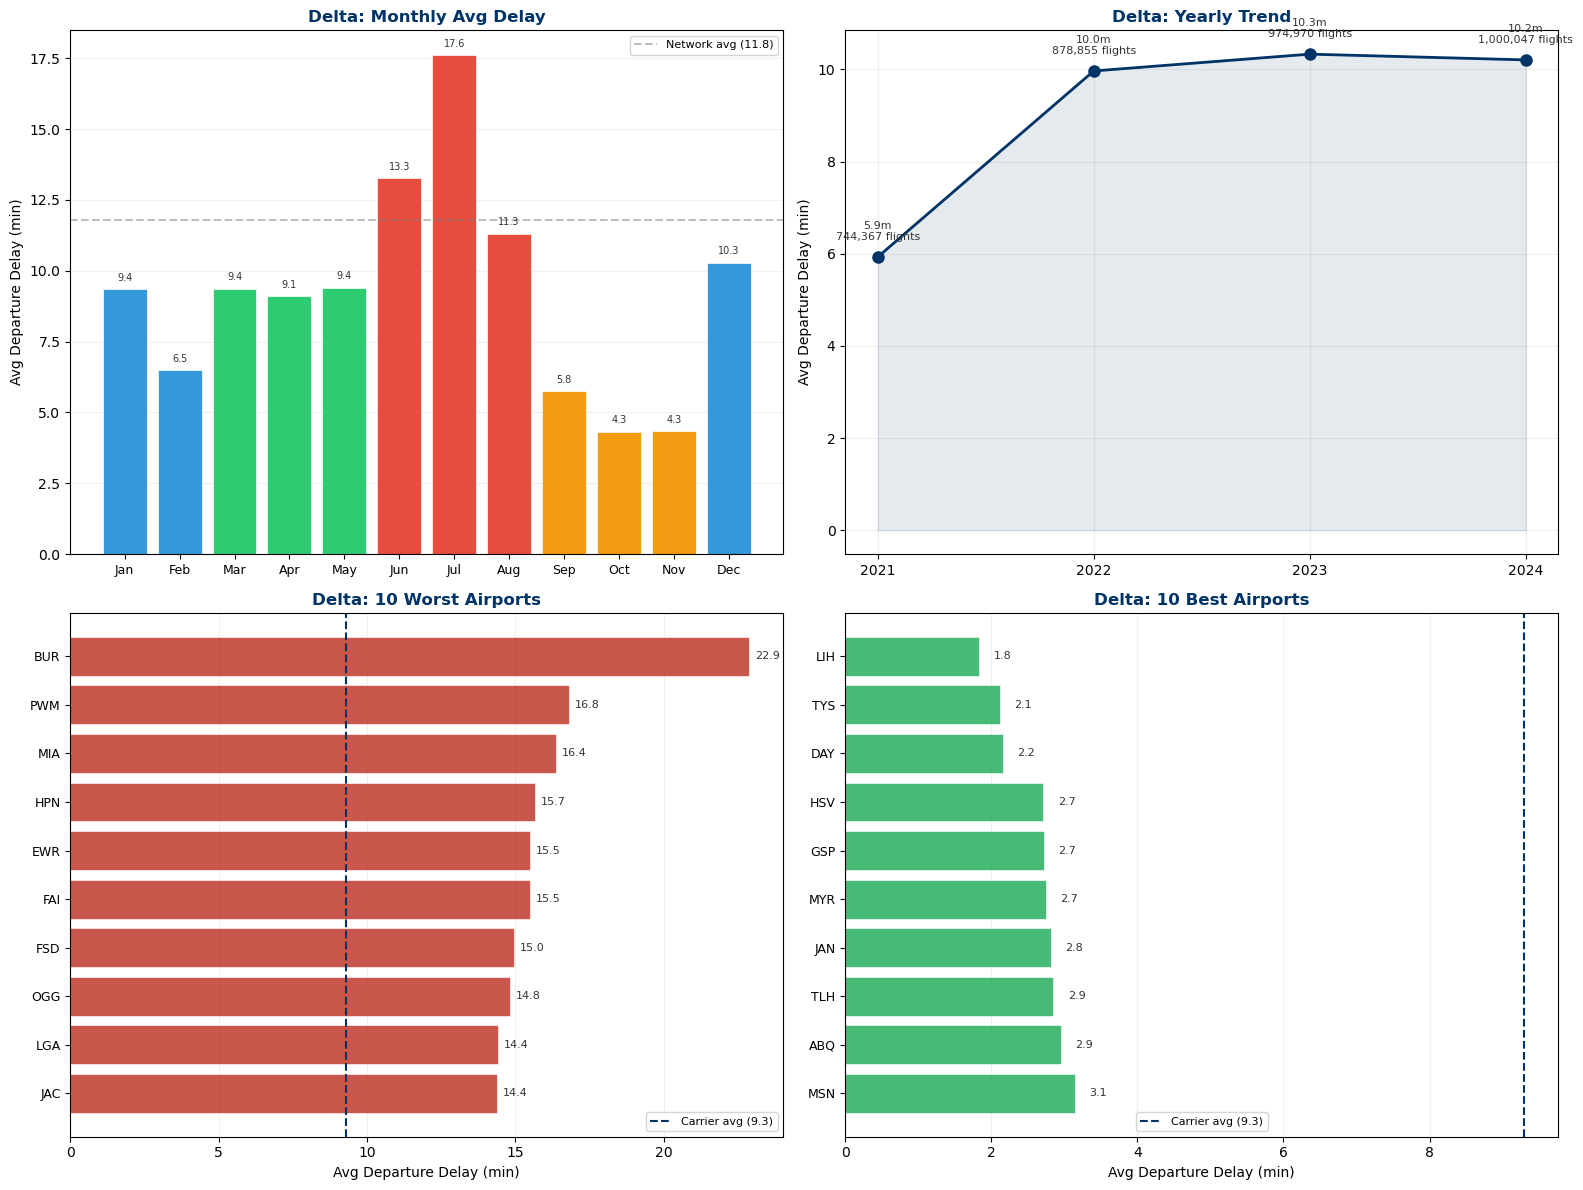

Route,Avg Delay,Rate,Flights
ANC → ATL,40.3m,42%,507
OGG → SLC,33.7m,29%,594
RNO → ATL,32.0m,38%,346
CHS → BOS,31.8m,28%,769
SRQ → LGA,29.9m,23%,"1,332"
AVL → MSP,28.7m,42%,341
SLC → OGG,28.5m,26%,602
BUR → SLC,28.3m,29%,375
SAT → JFK,26.6m,22%,596
FLL → SEA,26.6m,28%,732



Best month to fly Delta: October (4.3 min avg)
Worst month to fly Delta: July (17.6 min avg)


In [50]:
airline_report('DL')

In [68]:
def airport_profile(airport='JFK'):
    """
    Full airport delay dashboard.
    Usage: airport_profile('JFK'), airport_profile('ORD'), airport_profile('ATL')
    """
    airport = airport.upper()
    airport_city = city_lookup.get(airport, airport)

    subset = df_delays[df_delays['ORIGIN'] == airport].copy()

    if len(subset) == 0:
        display(HTML(f"<div style='padding: 20px; background: #fff3cd; border-radius: 8px; "
                     f"font-family: Arial;'><b>No flights found for airport '{airport}'</b></div>"))
        return

    n_flights = len(subset)

    # Restrict to top 75 airports with full data
    valid_airports = list(coord_lookup.keys())
    if airport not in valid_airports:
        display(HTML(
            f"<div style='padding: 20px; background: #1a1a2e; border-radius: 10px; "
            f"font-family: Arial; color: white; max-width: 750px;'>"
            f"<div style='font-size: 20px; font-weight: bold; margin-bottom: 10px;'>"
            f"✈ {airport} — {airport_city}</div>"
            f"<div style='font-size: 14px; color: #ccc;'>"
            f"Detailed profiles are available for the top 75 U.S. airports only.</div>"
            f"<div style='margin-top: 10px; font-size: 12px; color: #888;'>"
            f"This airport has {n_flights:,} flights in our data but lacks weather, "
            f"hub classification, and coordinate data needed for the full profile.</div>"
            f"</div>"))
        return

    # --- Overall stats ---
    avg_delay = float(subset['DEP_DELAY'].mean())
    median_delay = float(subset['DEP_DELAY'].median())
    pct_ontime = float((subset['DEP_DELAY'] <= 0).mean() * 100)
    pct_delayed = float((subset['DEP_DEL15'] == 1).mean() * 100)
    pct_major = float((subset['DEP_DELAY'] > 60).mean() * 100)
    n_carriers = subset['OP_UNIQUE_CARRIER'].nunique()
    n_destinations = subset['DEST'].nunique()

    # Hub size
    hub = subset['hub_size'].mode()
    hub_label = {'L': 'Large Hub', 'M': 'Medium Hub', 'S': 'Small Hub'}.get(
        hub.iloc[0] if len(hub) > 0 else '', 'Unknown')

    # Rank among all 75 airports
    all_airport_stats = df_delays[df_delays['hub_size'].notna()].groupby('ORIGIN').agg(
        avg_delay=('DEP_DELAY', 'mean')
    ).sort_values('avg_delay')
    n_airports = len(all_airport_stats)
    if airport in all_airport_stats.index:
        apt_rank = int(all_airport_stats.index.get_loc(airport)) + 1
    else:
        apt_rank = 0

    # --- Carrier performance at this airport ---
    carrier_perf = subset.groupby('OP_UNIQUE_CARRIER').agg(
        flights=('DEP_DELAY', 'count'),
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    )
    carrier_perf = carrier_perf[carrier_perf['flights'] >= 100].sort_values('avg_delay')
    carrier_perf['name'] = carrier_perf.index.map(carrier_names)

    # --- Monthly ---
    monthly = subset.groupby('MONTH').agg(
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    ).round(2)

    # --- Time of day ---
    if 'CRS_DEP_TIME' in subset.columns:
        subset['_tod'] = subset['CRS_DEP_TIME'].apply(get_time_bin)
        tod_perf = subset.groupby('_tod').agg(
            flights=('DEP_DELAY', 'count'),
            avg_delay=('DEP_DELAY', 'mean'),
            delay_rate=('DEP_DEL15', 'mean')
        ).round(2)
        tod_order = ['Red-eye', 'Morning', 'Afternoon', 'Evening', 'Night']
        tod_perf = tod_perf.reindex([t for t in tod_order if t in tod_perf.index])

    # --- Weather at this airport ---
    has_weather = subset['precipitation'].notna().any()
    if has_weather:
        wx = subset[subset['precipitation'].notna()]
        avg_precip = float(wx['precipitation'].mean())
        avg_snow = float(wx['snowfall'].mean())
        avg_wind_val = float(wx['avg_wind'].mean())
        avg_temp = float(wx['temp_max'].mean())

    # --- Worst destinations ---
    dest_perf = subset.groupby('DEST').agg(
        flights=('DEP_DELAY', 'count'),
        avg_delay=('DEP_DELAY', 'mean'),
        delay_rate=('DEP_DEL15', 'mean')
    )
    dest_perf = dest_perf[dest_perf['flights'] >= 200].sort_values('avg_delay', ascending=False)

    # --- Header ---
    if apt_rank > 0 and apt_rank <= n_airports * 0.33:
        rank_color = '#27ae60'; rank_label = 'Best third'
    elif apt_rank > 0 and apt_rank <= n_airports * 0.66:
        rank_color = '#f39c12'; rank_label = 'Middle third'
    else:
        rank_color = '#c0392b'; rank_label = 'Worst third'

    header_html = f"""
    <div style="font-family: Arial; max-width: 850px; margin: 10px 0;">
        <div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
             color: white; padding: 25px 30px; border-radius: 10px 10px 0 0; position: relative;">
            <div style="position: absolute; top: 15px; right: 25px; font-size: 44px;
                 font-weight: bold; color: rgba(255,255,255,0.15);">{airport}</div>
            <div style="font-size: 11px; color: rgba(255,255,255,0.5); text-transform: uppercase;
                 letter-spacing: 1.5px;">Airport Performance Profile</div>
            <div style="font-size: 28px; font-weight: bold; margin: 8px 0;">
                ✈ {airport} — {airport_city}</div>
            <div style="font-size: 13px; color: rgba(255,255,255,0.6); margin-top: 5px;">
                {hub_label} &bull; {n_flights:,} departures &bull; {n_carriers} carriers &bull;
                {n_destinations} destinations &bull; 2021–2024</div>
        </div>

        <div style="background: {rank_color}; color: white; padding: 12px 30px;
             font-weight: bold; font-size: 14px;
             display: flex; justify-content: space-between; align-items: center;">
            <span>Ranked #{apt_rank} of {n_airports} airports by avg delay ({rank_label})</span>
            <span style="font-weight: normal; font-size: 12px;">
                Avg delay: {avg_delay:+.1f} min &bull; On-time: {pct_ontime:.0f}%</span>
        </div>

        <div style="background: white; padding: 20px 30px; border: 1px solid #e0e0e0;">
            <div style="display: grid; grid-template-columns: 1fr 1fr 1fr 1fr; gap: 12px;
                 text-align: center;">
                <div style="background: #f0faf0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #27ae60;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">On Time</div>
                    <div style="font-size: 26px; font-weight: bold; color: #27ae60; margin-top: 4px;">
                        {pct_ontime:.0f}%</div>
                </div>
                <div style="background: #f8f8ff; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #2c7bb6;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">Avg Delay</div>
                    <div style="font-size: 26px; font-weight: bold; color: #2c7bb6; margin-top: 4px;">
                        {avg_delay:+.1f}m</div>
                </div>
                <div style="background: #fff5f0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #e67e22;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">Delayed 15m+</div>
                    <div style="font-size: 26px; font-weight: bold; color: #e67e22; margin-top: 4px;">
                        {pct_delayed:.0f}%</div>
                </div>
                <div style="background: #fff0f0; border-radius: 8px; padding: 14px 8px;
                     border-bottom: 3px solid #c0392b;">
                    <div style="font-size: 10px; color: #888; text-transform: uppercase;">Major 60m+</div>
                    <div style="font-size: 26px; font-weight: bold; color: #c0392b; margin-top: 4px;">
                        {pct_major:.1f}%</div>
                </div>
            </div>
        </div>
    """

    if has_weather:
        header_html += f"""
        <div style="background: #f8f9fa; padding: 12px 30px; border: 1px solid #e0e0e0;
             border-top: none; display: grid; grid-template-columns: 1fr 1fr 1fr 1fr; gap: 10px;
             text-align: center; font-size: 12px;">
            <div>Avg Temp: <b>{avg_temp:.0f}°F</b></div>
            <div>Avg Precip: <b>{avg_precip:.2f} in</b></div>
            <div>Avg Snow: <b>{avg_snow:.2f} in</b></div>
            <div>Avg Wind: <b>{avg_wind_val:.1f} mph</b></div>
        </div>
    """

    header_html += "</div>"
    display(HTML(header_html))

    # --- Plots ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Carrier performance at this airport
    if len(carrier_perf) > 0:
        cp = carrier_perf.head(15)
        colors_cp = ['#27ae60' if x < avg_delay else '#c0392b' for x in cp['avg_delay'].values[::-1]]
        axes[0,0].barh(range(len(cp)), cp['avg_delay'].values[::-1], color=colors_cp,
                       edgecolor='white', linewidth=0.5)
        axes[0,0].set_yticks(range(len(cp)))
        labels_cp = [f"{carrier_names.get(c, c)} ({c})" for c in cp.index[::-1]]
        axes[0,0].set_yticklabels(labels_cp, fontsize=9)
        axes[0,0].set_xlabel('Avg Departure Delay (min)', fontsize=10)
        axes[0,0].set_title(f'Carrier Performance at {airport}', fontsize=12, fontweight='bold')
        axes[0,0].axvline(x=avg_delay, color='gray', linestyle='--', label=f'Airport avg ({avg_delay:.1f})')
        axes[0,0].legend(fontsize=8)
        axes[0,0].grid(axis='x', alpha=0.2)
        axes[0,0].set_axisbelow(True)

    # 2. Monthly delay
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
                  6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'}
    colors_season = {'Winter':'#3498db','Spring':'#2ecc71','Summer':'#e74c3c','Fall':'#f39c12'}
    m_colors = [colors_season[season_map[m]] for m in monthly.index]
    axes[0,1].bar(monthly.index, monthly['avg_delay'], color=m_colors, edgecolor='white', linewidth=0.5)
    axes[0,1].set_xticks(range(1,13))
    axes[0,1].set_xticklabels(month_labels, fontsize=9)
    axes[0,1].set_ylabel('Avg Departure Delay (min)', fontsize=10)
    axes[0,1].set_title(f'{airport}: Monthly Avg Delay', fontsize=12, fontweight='bold')
    axes[0,1].axhline(y=11.8, color='gray', linestyle='--', alpha=0.5, label='Network avg')
    axes[0,1].legend(fontsize=8)
    axes[0,1].grid(axis='y', alpha=0.2)
    axes[0,1].set_axisbelow(True)

    # 3. Time of day
    if 'CRS_DEP_TIME' in subset.columns and len(tod_perf) > 0:
        tod_colors = ['#2c7bb6' if x < avg_delay else '#c0392b' for x in tod_perf['avg_delay']]
        axes[1,0].bar(range(len(tod_perf)), tod_perf['avg_delay'], color=tod_colors,
                      edgecolor='white', linewidth=0.5)
        axes[1,0].set_xticks(range(len(tod_perf)))
        axes[1,0].set_xticklabels(tod_perf.index, rotation=30, ha='right', fontsize=9)
        axes[1,0].set_ylabel('Avg Departure Delay (min)', fontsize=10)
        axes[1,0].set_title(f'{airport}: Delay by Time of Day', fontsize=12, fontweight='bold')
        axes[1,0].axhline(y=avg_delay, color='gray', linestyle='--', label=f'Airport avg ({avg_delay:.1f})')
        axes[1,0].legend(fontsize=8)
        axes[1,0].grid(axis='y', alpha=0.2)
        axes[1,0].set_axisbelow(True)
        for i, (_, row) in enumerate(tod_perf.iterrows()):
            axes[1,0].text(i, row['avg_delay'] + 0.3, f'{row["avg_delay"]:.1f}',
                          ha='center', fontsize=8, color='#333')

    # 4. Worst destinations
    wd = dest_perf.head(15)
    bars = axes[1,1].barh(range(len(wd)), wd['avg_delay'].values[::-1],
                          color='#c0392b', edgecolor='white', linewidth=0.5, alpha=0.85)
    axes[1,1].set_yticks(range(len(wd)))
    dest_labels = [f"{d} ({city_lookup.get(d, '')})" if len(city_lookup.get(d, '')) < 20
                   else d for d in wd.index[::-1]]
    axes[1,1].set_yticklabels(dest_labels, fontsize=8)
    axes[1,1].set_xlabel('Avg Departure Delay (min)', fontsize=10)
    axes[1,1].set_title(f'Worst Destinations from {airport}', fontsize=12, fontweight='bold')
    axes[1,1].grid(axis='x', alpha=0.2)
    axes[1,1].set_axisbelow(True)

    plt.tight_layout()
    plt.show()

    # --- Destination map ---
    o = coord_lookup[airport]
    fm = folium.Map(location=[o['lat'], o['lon']], zoom_start=4, tiles='CartoDB positron')

    top_dests = dest_perf.head(30)
    for dest_code, row in top_dests.iterrows():
        if dest_code not in coord_lookup:
            continue
        d = coord_lookup[dest_code]
        arc = great_circle_points(o['lat'], o['lon'], d['lat'], d['lon'])

        if row['avg_delay'] <= 0:
            rc = '#27ae60'
        elif row['avg_delay'] <= 11.8:
            rc = '#2c7bb6'
        elif row['avg_delay'] <= 17.7:
            rc = '#f39c12'
        else:
            rc = '#c0392b'

        folium.PolyLine(locations=arc, color=rc, weight=2.5, opacity=0.6,
                        tooltip=f"{airport} → {dest_code} | {row['avg_delay']:.1f} min avg"
        ).add_to(fm)

        folium.Marker(
            location=[d['lat'], d['lon']],
            tooltip=f"<b>{dest_code}</b> — {city_lookup.get(dest_code, '')}<br>"
                    f"Avg delay: {row['avg_delay']:.1f} min<br>"
                    f"Flights: {int(row['flights']):,}",
            icon=folium.DivIcon(
                html=f'<div style="font-size: 10px; font-weight: bold; color: {rc}; '
                     f'text-shadow: 1px 1px 1px white;">✈</div>',
                icon_size=(14, 14), icon_anchor=(7, 7))
        ).add_to(fm)

    # Origin marker
    folium.Marker(
        location=[o['lat'], o['lon']],
        tooltip=f"<b>{airport}</b> — {airport_city}",
        icon=folium.DivIcon(
            html='<div style="font-size: 24px; color: #1a1a2e; '
                 'text-shadow: 1px 1px 2px white, -1px -1px 2px white;">✈</div>',
            icon_size=(28, 28), icon_anchor=(14, 14))
    ).add_to(fm)

    # Map legend
    legend_html = """
    <div style="position: fixed; bottom: 15px; right: 15px; z-index: 1000;
         background: white; padding: 10px 14px; border: 1px solid #ccc;
         border-radius: 5px; font-size: 11px; font-family: Arial; color: #555;">
        <div style="font-weight: bold; margin-bottom: 5px;">Route Delay Severity</div>
        <div><span style="color: #27ae60;">━━</span> Early / on-time</div>
        <div><span style="color: #2c7bb6;">━━</span> Below avg (11.8 min)</div>
        <div><span style="color: #f39c12;">━━</span> Above average</div>
        <div><span style="color: #c0392b;">━━</span> Well above average</div>
    </div>
    """
    fm.get_root().html.add_child(folium.Element(legend_html))

    display(fm)

    # --- Summary ---
    best_m = monthly['avg_delay'].idxmin()
    worst_m = monthly['avg_delay'].idxmax()
    if 'CRS_DEP_TIME' in subset.columns and len(tod_perf) > 0:
        best_tod = tod_perf['avg_delay'].idxmin()
        print(f"Best time to fly from {airport}: {best_tod} ({tod_perf.loc[best_tod, 'avg_delay']:.1f} min avg)")
    print(f"Best month: {month_names[best_m]} ({monthly.loc[best_m, 'avg_delay']:.1f} min avg)")
    print(f"Worst month: {month_names[worst_m]} ({monthly.loc[worst_m, 'avg_delay']:.1f} min avg)")
    print(f"Best carrier at {airport}: {carrier_names.get(carrier_perf.index[0], carrier_perf.index[0])} "
          f"({carrier_perf.iloc[0]['avg_delay']:.1f} min avg)")

print("✈ Airport Profile loaded")
print("Usage: airport_profile('JFK'), airport_profile('ORD'), airport_profile('ATL')")

✈ Airport Profile loaded
Usage: airport_profile('JFK'), airport_profile('ORD'), airport_profile('ATL')


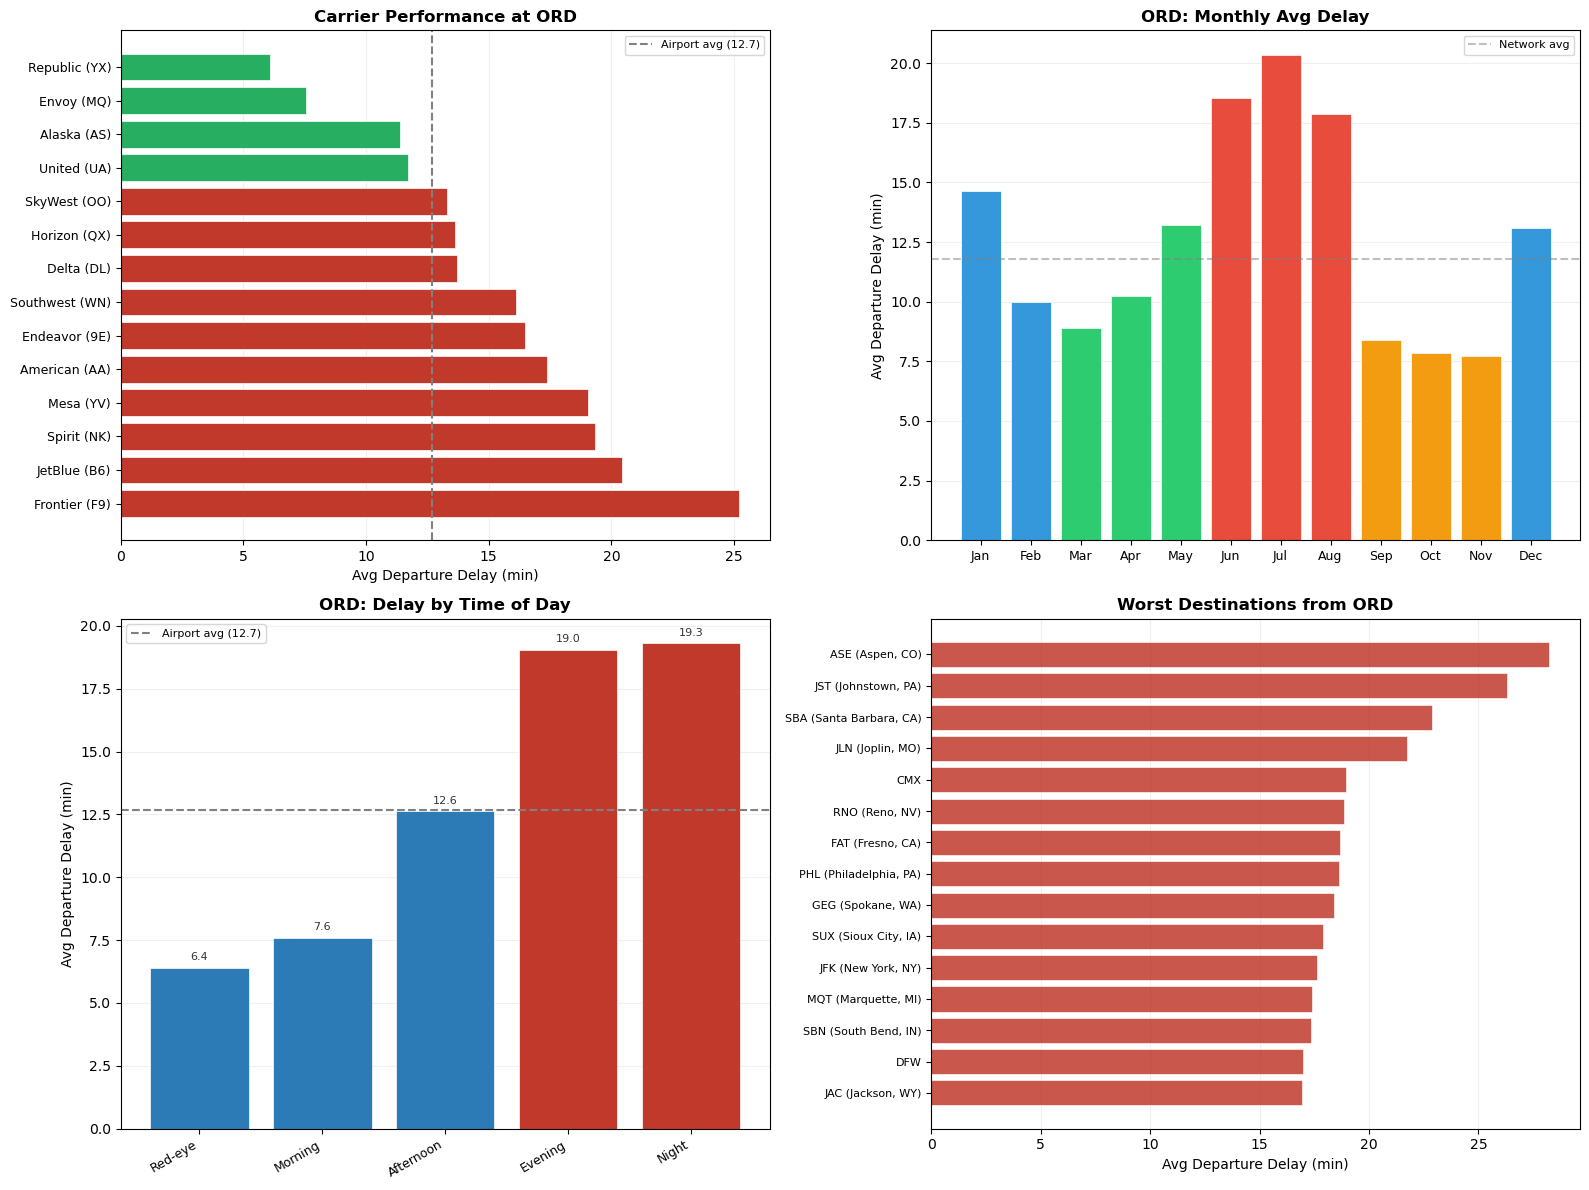

Best time to fly from ORD: Red-eye (6.4 min avg)
Best month: November (7.7 min avg)
Worst month: July (20.4 min avg)
Best carrier at ORD: Republic (6.1 min avg)


In [70]:
airport_profile('ORD')

In [60]:
def when_to_fly(origin='JFK', dest='LAX', carrier='DL'):
    """
    Heatmap showing best month × time-of-day to fly a route.
    Usage: when_to_fly('JFK', 'LAX', 'DL')
           when_to_fly('ORD', 'MIA', 'AA')
    """
    origin = origin.upper()
    dest = dest.upper()
    carrier = carrier.upper()

    display_carrier = regional_to_parent.get(carrier, carrier)
    primary, accent = airline_colors.get(display_carrier, ('#1a1a2e', '#e74c3c'))
    c_name = carrier_names.get(carrier, carrier)
    parent_name = carrier_names.get(display_carrier, display_carrier)
    if carrier != display_carrier:
        c_name = f"{c_name} ({parent_name})"

    origin_city = city_lookup.get(origin, origin)
    dest_city = city_lookup.get(dest, dest)

    mask = ((df_delays['ORIGIN'] == origin) &
            (df_delays['DEST'] == dest) &
            (df_delays['OP_UNIQUE_CARRIER'] == carrier))
    subset = df_delays[mask].copy()

    if len(subset) == 0:
        available = ', '.join(sorted(df_delays[(df_delays['ORIGIN']==origin) &
                                                (df_delays['DEST']==dest)]['OP_UNIQUE_CARRIER'].unique().tolist()))
        display(HTML(f"<div style='padding: 20px; background: {primary}; border-radius: 10px; "
                     f"font-family: Arial; color: white; max-width: 750px;'>"
                     f"<b>{c_name}</b> does not fly {origin} → {dest}.<br>"
                     f"Available: {available}</div>"))
        return

    if 'CRS_DEP_TIME' not in subset.columns:
        display(HTML("<div style='padding: 15px; background: #fff3cd; border-radius: 8px;'>"
                     "CRS_DEP_TIME not available — cannot build time-of-day heatmap.</div>"))
        return

    subset['_tod'] = subset['CRS_DEP_TIME'].apply(get_time_bin)

    tod_order = ['Red-eye', 'Morning', 'Afternoon', 'Evening', 'Night']

    # --- Build heatmap data: avg delay ---
    delay_pivot = subset.groupby(['MONTH', '_tod'])['DEP_DELAY'].mean().unstack('_tod')
    delay_pivot = delay_pivot.reindex(columns=[t for t in tod_order if t in delay_pivot.columns])
    delay_pivot = delay_pivot.reindex(range(1, 13))

    # --- Build heatmap data: delay rate ---
    rate_pivot = subset.groupby(['MONTH', '_tod'])['DEP_DEL15'].mean().unstack('_tod')
    rate_pivot = rate_pivot.reindex(columns=[t for t in tod_order if t in rate_pivot.columns])
    rate_pivot = rate_pivot.reindex(range(1, 13))

    # --- Build heatmap data: flight counts ---
    count_pivot = subset.groupby(['MONTH', '_tod'])['DEP_DELAY'].count().unstack('_tod')
    count_pivot = count_pivot.reindex(columns=[t for t in tod_order if t in count_pivot.columns])
    count_pivot = count_pivot.reindex(range(1, 13)).fillna(0)

    # --- Find best/worst cells ---
    flat_delay = delay_pivot.stack()
    if len(flat_delay) > 0:
        best_idx = flat_delay.idxmin()
        worst_idx = flat_delay.idxmax()
        best_val = float(flat_delay.min())
        worst_val = float(flat_delay.max())
    else:
        best_idx = (1, 'Morning')
        worst_idx = (7, 'Evening')
        best_val = 0
        worst_val = 0

    avg_delay = float(subset['DEP_DELAY'].mean())

    # --- Header ---
    header_html = f"""
    <div style="font-family: Arial; max-width: 850px; margin: 10px 0;">
        <div style="background: linear-gradient(135deg, {primary} 0%, {primary}dd 100%);
             color: white; padding: 20px 25px; border-radius: 10px 10px 0 0; position: relative;">
            <div style="position: absolute; top: 12px; right: 20px; font-size: 34px;
                 font-weight: bold; color: {accent}; opacity: 0.4;">{display_carrier}</div>
            <div style="font-size: 11px; color: rgba(255,255,255,0.5); text-transform: uppercase;
                 letter-spacing: 1.5px;">When Should I Fly?</div>
            <div style="font-size: 26px; font-weight: bold; margin: 8px 0;">
                {c_name}: {origin} → {dest}</div>
            <div style="font-size: 14px; color: rgba(255,255,255,0.8);">
                {origin_city} → {dest_city}</div>
        </div>

        <div style="background: white; padding: 15px 25px; border: 1px solid #e0e0e0;
             display: grid; grid-template-columns: 1fr 1fr; gap: 15px;">
            <div style="background: #f0faf0; border-radius: 8px; padding: 12px 15px;
                 border-left: 4px solid #27ae60;">
                <div style="font-size: 11px; color: #888; text-transform: uppercase;">Best Time to Fly</div>
                <div style="font-size: 18px; font-weight: bold; color: #27ae60; margin-top: 4px;">
                    {month_names.get(best_idx[0], '?')} — {best_idx[1]}</div>
                <div style="font-size: 12px; color: #666;">Avg delay: {best_val:+.1f} min</div>
            </div>
            <div style="background: #fff0f0; border-radius: 8px; padding: 12px 15px;
                 border-left: 4px solid #c0392b;">
                <div style="font-size: 11px; color: #888; text-transform: uppercase;">Worst Time to Fly</div>
                <div style="font-size: 18px; font-weight: bold; color: #c0392b; margin-top: 4px;">
                    {month_names.get(worst_idx[0], '?')} — {worst_idx[1]}</div>
                <div style="font-size: 12px; color: #666;">Avg delay: {worst_val:+.1f} min</div>
            </div>
        </div>

        <div style="background: {primary}15; padding: 8px 25px; border: 1px solid #e0e0e0;
             border-top: none; border-radius: 0 0 10px 10px; font-size: 11px; color: #999;">
            Based on {len(subset):,} flights (2021–2024). Overall route avg: {avg_delay:+.1f} min.
        </div>
    </div>
    """
    display(HTML(header_html))

    # --- Heatmaps ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    # 1. Average delay heatmap
    sns.heatmap(delay_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', center=avg_delay,
                ax=axes[0], linewidths=1, linecolor='white',
                cbar_kws={'label': 'Avg Delay (min)', 'shrink': 0.8},
                annot_kws={'fontsize': 9})
    axes[0].set_yticklabels(month_labels, rotation=0, fontsize=10)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), fontsize=10)
    axes[0].set_title(f'Average Departure Delay (min)\n{c_name}: {origin} → {dest}',
                     fontsize=12, fontweight='bold', color=primary)
    axes[0].set_ylabel('')

    # 2. Delay rate heatmap
    rate_display = rate_pivot * 100
    sns.heatmap(rate_display, annot=True, fmt='.0f', cmap='RdYlGn_r',
                center=rate_display.mean().mean(),
                ax=axes[1], linewidths=1, linecolor='white',
                cbar_kws={'label': '% Delayed >15 min', 'shrink': 0.8},
                annot_kws={'fontsize': 9})
    axes[1].set_yticklabels(month_labels, rotation=0, fontsize=10)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=10)
    axes[1].set_title(f'Delay Rate (% flights >15 min late)\n{c_name}: {origin} → {dest}',
                     fontsize=12, fontweight='bold', color=primary)
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

    # --- Monthly bar chart ---
    monthly_all = subset.groupby('MONTH').agg(
        avg_delay=('DEP_DELAY', 'mean'),
        flights=('DEP_DELAY', 'count')
    ).round(2)

    fig, ax = plt.subplots(figsize=(12, 4))
    season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
                  6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'}
    colors_season = {'Winter':'#3498db','Spring':'#2ecc71','Summer':'#e74c3c','Fall':'#f39c12'}
    m_colors = [colors_season[season_map[m]] for m in monthly_all.index]

    bars = ax.bar(monthly_all.index, monthly_all['avg_delay'], color=m_colors,
                  edgecolor='white', linewidth=0.5)
    ax.axhline(y=avg_delay, color='gray', linestyle='--', alpha=0.5,
               label=f'Route avg ({avg_delay:.1f} min)')
    ax.axhline(y=11.8, color='black', linestyle=':', alpha=0.3, label='Network avg (11.8 min)')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_ylabel('Avg Departure Delay (min)')
    ax.set_title(f'{c_name}: {origin} → {dest} — Monthly Overview',
                fontsize=12, fontweight='bold', color=primary)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.2)
    ax.set_axisbelow(True)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}',
                ha='center', fontsize=8, color='#333')
    plt.tight_layout()
    plt.show()

    # --- Summary text ---
    best_month = monthly_all['avg_delay'].idxmin()
    worst_month = monthly_all['avg_delay'].idxmax()
    print(f"\nRecommendation for {c_name} {origin} → {dest}:")
    print(f"  Best month: {month_names[best_month]} ({monthly_all.loc[best_month, 'avg_delay']:.1f} min avg)")
    print(f"  Worst month: {month_names[worst_month]} ({monthly_all.loc[worst_month, 'avg_delay']:.1f} min avg)")
    print(f"  Best slot: {month_names.get(best_idx[0], '?')} {best_idx[1]} ({best_val:+.1f} min)")
    print(f"  Worst slot: {month_names.get(worst_idx[0], '?')} {worst_idx[1]} ({worst_val:+.1f} min)")
    print(f"  Difference: {worst_val - best_val:.1f} minutes between best and worst timing")

print("✈ When Should I Fly loaded")
print("Usage: when_to_fly('JFK', 'LAX', 'DL')")

✈ When Should I Fly loaded
Usage: when_to_fly('JFK', 'LAX', 'DL')


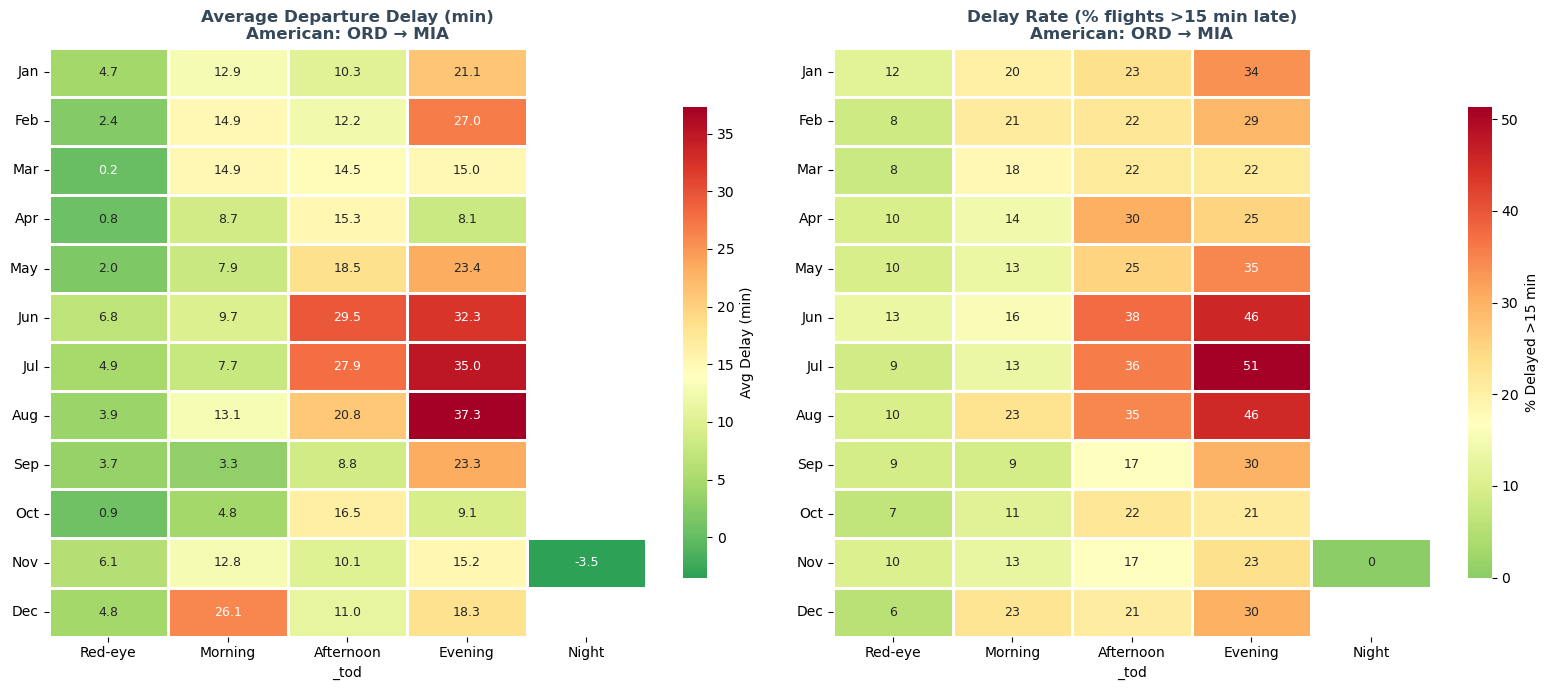

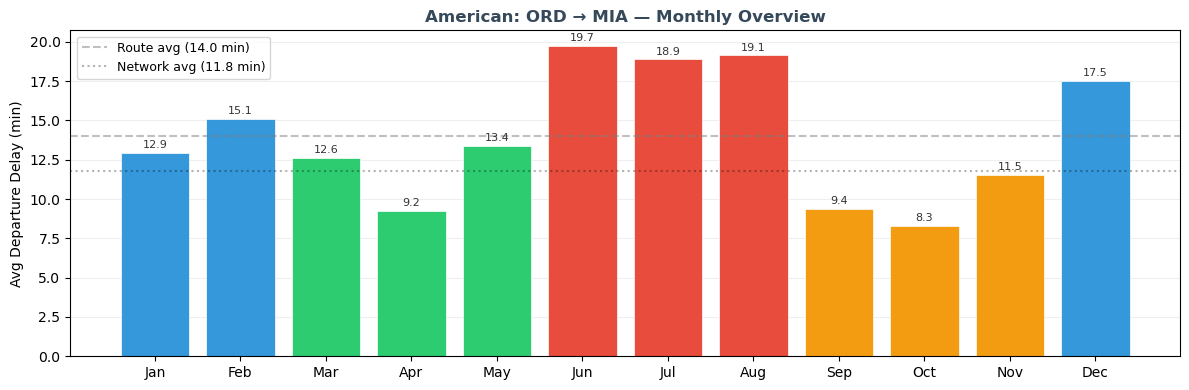


Recommendation for American ORD → MIA:
  Best month: October (8.3 min avg)
  Worst month: June (19.7 min avg)
  Best slot: November Night (-3.5 min)
  Worst slot: August Evening (+37.3 min)
  Difference: 40.8 minutes between best and worst timing


In [62]:
when_to_fly('ORD', 'MIA', 'AA')